  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 575 records


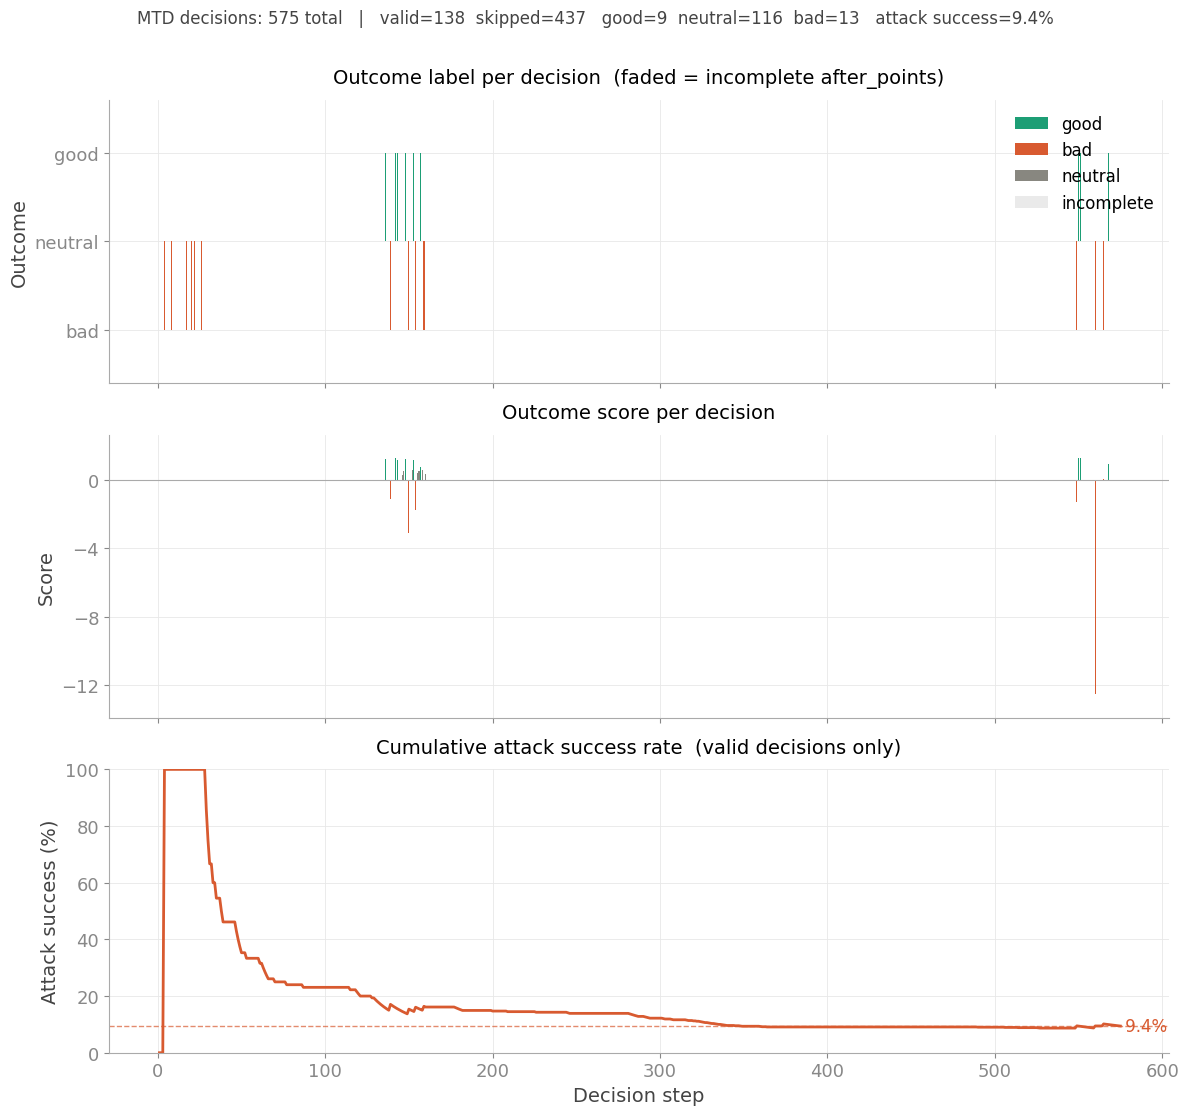

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helper: check if all selected/other entries have 4 after_points ────────

def has_full_after_points(record, n=4):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            pts = entry.get("after_points", {})
            # after_points is a dict of metric -> list
            for v in pts.values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30", "neutral": "#888780"}
LABEL_VAL   = {"good": 1, "neutral": 0, "bad": -1}

labels = []
scores = []
valid  = []   # track which steps passed the 4-point filter

for r in records:
    outcome = r.get("outcome", {})
    if has_full_after_points(r):
        labels.append(outcome.get("label", "neutral"))
        scores.append(outcome.get("score", 0.0))
        valid.append(True)
    else:
        labels.append("neutral")   # treat incomplete as neutral
        scores.append(0.0)
        valid.append(False)

steps      = list(range(1, len(records) + 1))
label_vals = [LABEL_VAL[l] for l in labels]

# running attack success rate — only count valid steps
cum_bad   = []
cum_total = []
running   = 0
valid_so_far = 0
for i, (l, v) in enumerate(zip(labels, valid)):
    if v:
        valid_so_far += 1
        if l == "bad":
            running += 1
    cum_bad.append(running)
    cum_total.append(max(valid_so_far, 1))

attack_rate = [b / t * 100 for b, t in zip(cum_bad, cum_total)]

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    13,
    "ytick.labelsize":    13,
    "axes.labelsize":     14,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     14,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    12,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.subplots_adjust(hspace=0.45)

# ── plot 1: outcome label per decision ────────────────────────────────────

ax = axes[0]
for step, lv, lab, v in zip(steps, label_vals, labels, valid):
    color   = LABEL_COLOR[lab] if v else "#cccccc"
    alpha   = 1.0 if v else 0.4
    ax.bar(step, lv, color=color, width=0.7, zorder=2, alpha=alpha)

ax.set_ylim(-1.6, 1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["bad", "neutral", "good"])
ax.set_title("Outcome label per decision  (faded = incomplete after_points)")
ax.set_ylabel("Outcome")

for lab, col in LABEL_COLOR.items():
    ax.bar(0, 0, color=col, label=lab)
ax.bar(0, 0, color="#cccccc", alpha=0.4, label="incomplete")
ax.legend(loc="upper right")

# ── plot 2: outcome score per decision ────────────────────────────────────

ax = axes[1]
for step, sc, lab, v in zip(steps, scores, labels, valid):
    color = LABEL_COLOR[lab] if v else "#cccccc"
    alpha = 1.0 if v else 0.4
    ax.bar(step, sc, color=color, width=0.7, zorder=2, alpha=alpha)

ax.axhline(0, color="#aaaaaa", linewidth=0.8)
valid_scores = [s for s, v in zip(scores, valid) if v]
if valid_scores:
    mn, mx = min(valid_scores), max(valid_scores)
    pad = (mx - mn) * 0.1 or 0.5
    ax.set_ylim(mn - pad, mx + pad)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Outcome score per decision")
ax.set_ylabel("Score")

# ── plot 3: cumulative attack success rate ────────────────────────────────

ax = axes[2]
ax.plot(steps, attack_rate, color="#D85A30", linewidth=2,
        label="Attack success rate")

final_rate = attack_rate[-1]
ax.axhline(final_rate, color="#D85A30", linewidth=1.0,
           linestyle="--", alpha=0.7)
ax.text(steps[-1], final_rate, f" {final_rate:.1f}%",
        color="#D85A30", va="center", fontsize=12)

ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Cumulative attack success rate  (valid decisions only)")
ax.set_xlabel("Decision step")
ax.set_ylabel("Attack success (%)")

# ── final stats ────────────────────────────────────────────────────────────

total      = len(records)
n_valid    = sum(valid)
n_bad      = sum(1 for l, v in zip(labels, valid) if l == "bad"  and v)
n_good     = sum(1 for l, v in zip(labels, valid) if l == "good" and v)
n_neut     = sum(1 for l, v in zip(labels, valid) if l == "neutral" and v)
n_skip     = total - n_valid

fig.suptitle(
    f"MTD decisions: {total} total   |   valid={n_valid}  skipped={n_skip}   "
    f"good={n_good}  neutral={n_neut}  bad={n_bad}   "
    f"attack success={final_rate:.1f}%",
    fontsize=12, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 575 records


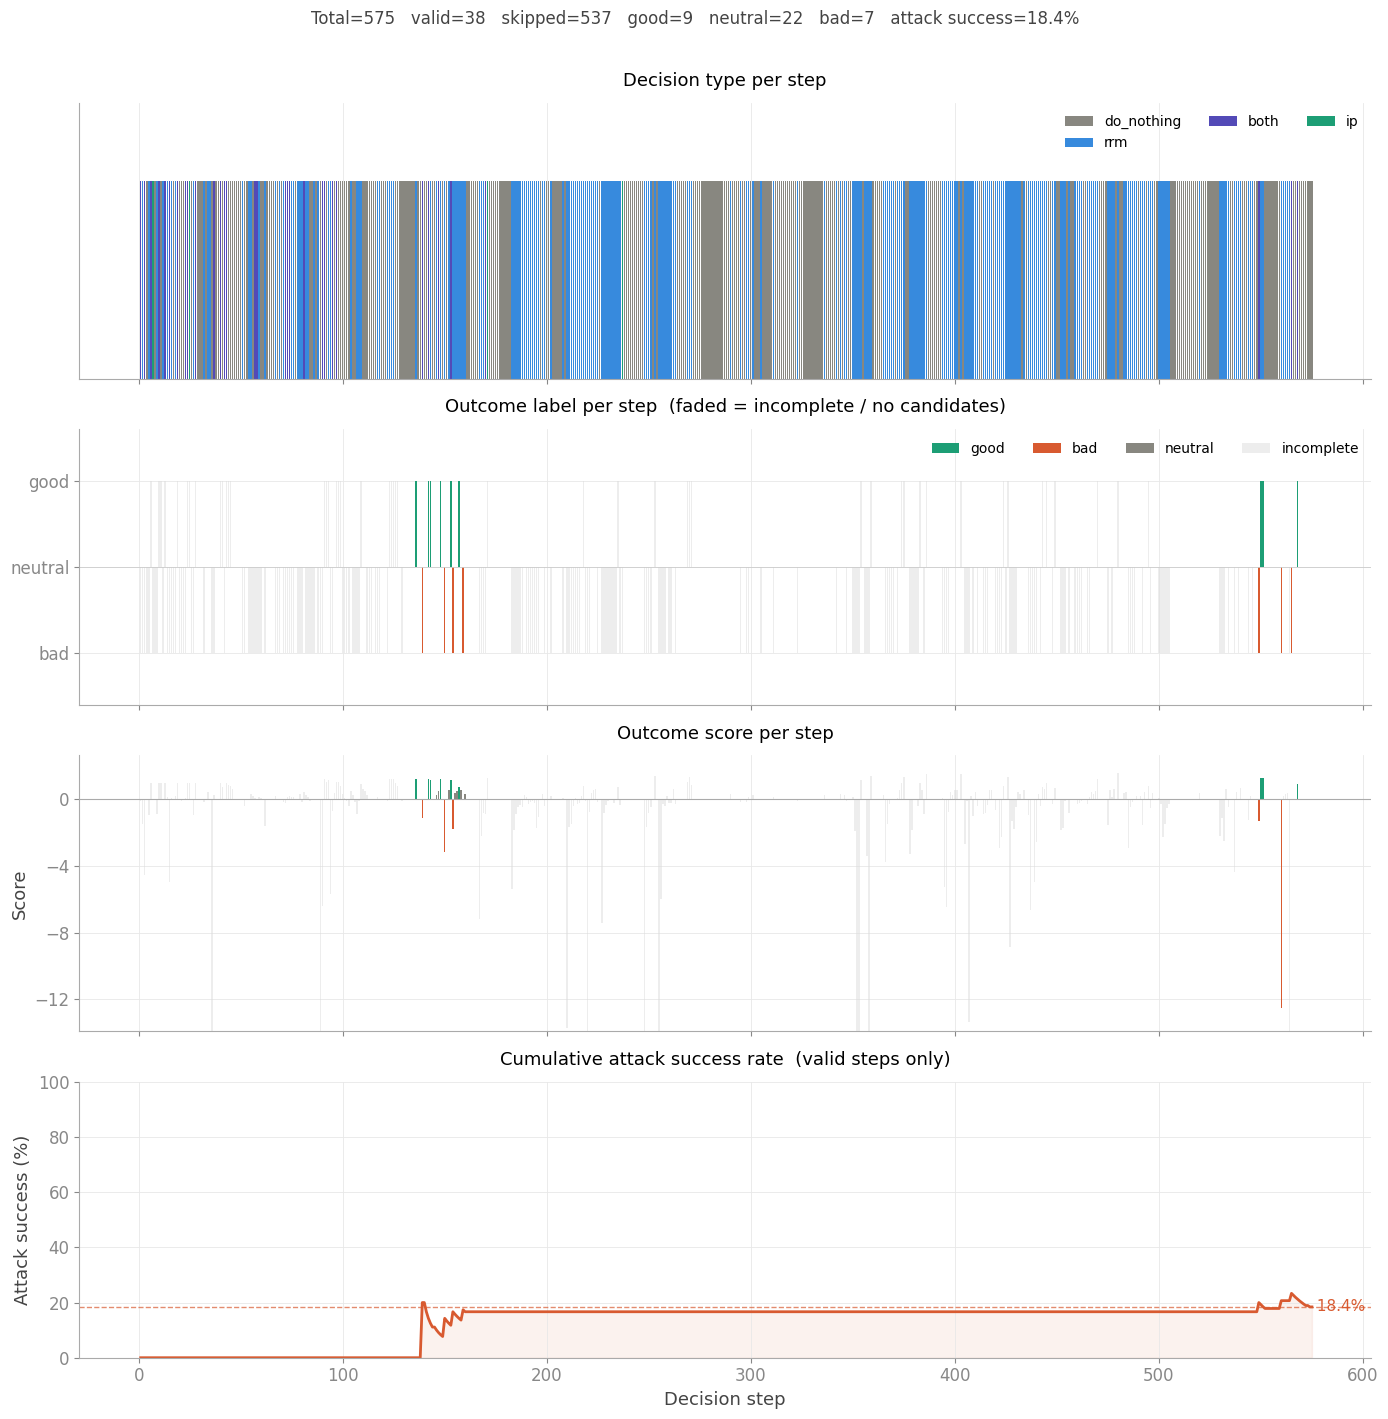

In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helpers ────────────────────────────────────────────────────────────────

def has_full_after_points(record, n=4):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            for v in entry.get("after_points", {}).values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

def get_decision(record):
    return record.get("decision", {}).get("final_decision", "unknown")

def has_any_candidates(record):
    trace = record.get("validation_trace", {})
    return any(
        trace.get(k) for k in ("selected_hosts", "selected_links",
                               "other_candidate_hosts", "other_candidate_links")
    )

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30", "neutral": "#888780"}
LABEL_VAL   = {"good": 1, "neutral": 0, "bad": -1}

steps      = list(range(1, len(records) + 1))
labels     = []
scores     = []
valid      = []
decisions  = []

for r in records:
    outcome  = r.get("outcome", {})
    is_valid = has_full_after_points(r) and has_any_candidates(r)
    labels.append(outcome.get("label", "neutral"))
    scores.append(outcome.get("score", 0.0))
    valid.append(is_valid)
    decisions.append(get_decision(r))

label_vals = [LABEL_VAL[l] for l in labels]

# cumulative attack success rate (valid steps only)
cum_bad, cum_valid, running, valid_so_far = [], [], 0, 0
for l, v in zip(labels, valid):
    if v:
        valid_so_far += 1
        if l == "bad":
            running += 1
    cum_bad.append(running)
    cum_valid.append(max(valid_so_far, 1))

attack_rate = [b / t * 100 for b, t in zip(cum_bad, cum_valid)]

# decision type mapping for color
DECISION_COLOR = {
    "do_nothing": "#888780",
    "rrm":        "#378ADD",
    "both":       "#534AB7",
    "ip":         "#1D9E75",
    "route":      "#BA7517",
    "unknown":    "#cccccc",
}

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.labelsize":     13,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     13,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.subplots_adjust(hspace=0.5)

# ── plot 1: decision type per step ────────────────────────────────────────

ax = axes[0]
for step, dec in zip(steps, decisions):
    color = DECISION_COLOR.get(dec, "#cccccc")
    ax.bar(step, 1, color=color, width=0.7, zorder=2)

ax.set_ylim(0, 1.4)
ax.set_yticks([])
ax.set_title("Decision type per step")

for dec, col in DECISION_COLOR.items():
    if dec in set(decisions):
        ax.bar(0, 0, color=col, label=dec)
ax.legend(loc="upper right", ncol=3)

# ── plot 2: outcome label per step ────────────────────────────────────────

ax = axes[1]
for step, lv, lab, v in zip(steps, label_vals, labels, valid):
    color = LABEL_COLOR[lab] if v else "#dddddd"
    alpha = 1.0 if v else 0.5
    ax.bar(step, lv, color=color, width=0.7, zorder=2, alpha=alpha)

ax.axhline(0, color="#cccccc", linewidth=0.6)
ax.set_ylim(-1.6, 1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["bad", "neutral", "good"])
ax.set_title("Outcome label per step  (faded = incomplete / no candidates)")

for lab, col in LABEL_COLOR.items():
    ax.bar(0, 0, color=col, label=lab)
ax.bar(0, 0, color="#dddddd", alpha=0.5, label="incomplete")
ax.legend(loc="upper right", ncol=4)

# ── plot 3: outcome score per step ────────────────────────────────────────

ax = axes[2]
for step, sc, lab, v in zip(steps, scores, labels, valid):
    color = LABEL_COLOR[lab] if v else "#dddddd"
    alpha = 1.0 if v else 0.5
    ax.bar(step, sc, color=color, width=0.7, zorder=2, alpha=alpha)

ax.axhline(0, color="#aaaaaa", linewidth=0.8)
valid_scores = [s for s, v in zip(scores, valid) if v]
if valid_scores:
    mn, mx = min(valid_scores), max(valid_scores)
    pad = (mx - mn) * 0.1 or 0.5
    ax.set_ylim(mn - pad, mx + pad)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Outcome score per step")
ax.set_ylabel("Score")

# ── plot 4: cumulative attack success rate ────────────────────────────────

ax = axes[3]
ax.plot(steps, attack_rate, color="#D85A30", linewidth=2)
ax.fill_between(steps, attack_rate, alpha=0.08, color="#D85A30")

final_rate = attack_rate[-1]
ax.axhline(final_rate, color="#D85A30", linewidth=1.0,
           linestyle="--", alpha=0.7)
ax.text(steps[-1], final_rate, f" {final_rate:.1f}%",
        color="#D85A30", va="center", fontsize=11)

ax.set_ylim(0, max(100, final_rate + 5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Cumulative attack success rate  (valid steps only)")
ax.set_xlabel("Decision step")
ax.set_ylabel("Attack success (%)")

# ── suptitle ───────────────────────────────────────────────────────────────

total   = len(records)
n_valid = sum(valid)
n_bad   = sum(1 for l, v in zip(labels, valid) if l == "bad"     and v)
n_good  = sum(1 for l, v in zip(labels, valid) if l == "good"    and v)
n_neut  = sum(1 for l, v in zip(labels, valid) if l == "neutral" and v)
n_skip  = total - n_valid

fig.suptitle(
    f"Total={total}   valid={n_valid}   skipped={n_skip}   "
    f"good={n_good}   neutral={n_neut}   bad={n_bad}   "
    f"attack success={final_rate:.1f}%",
    fontsize=12, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 575 records


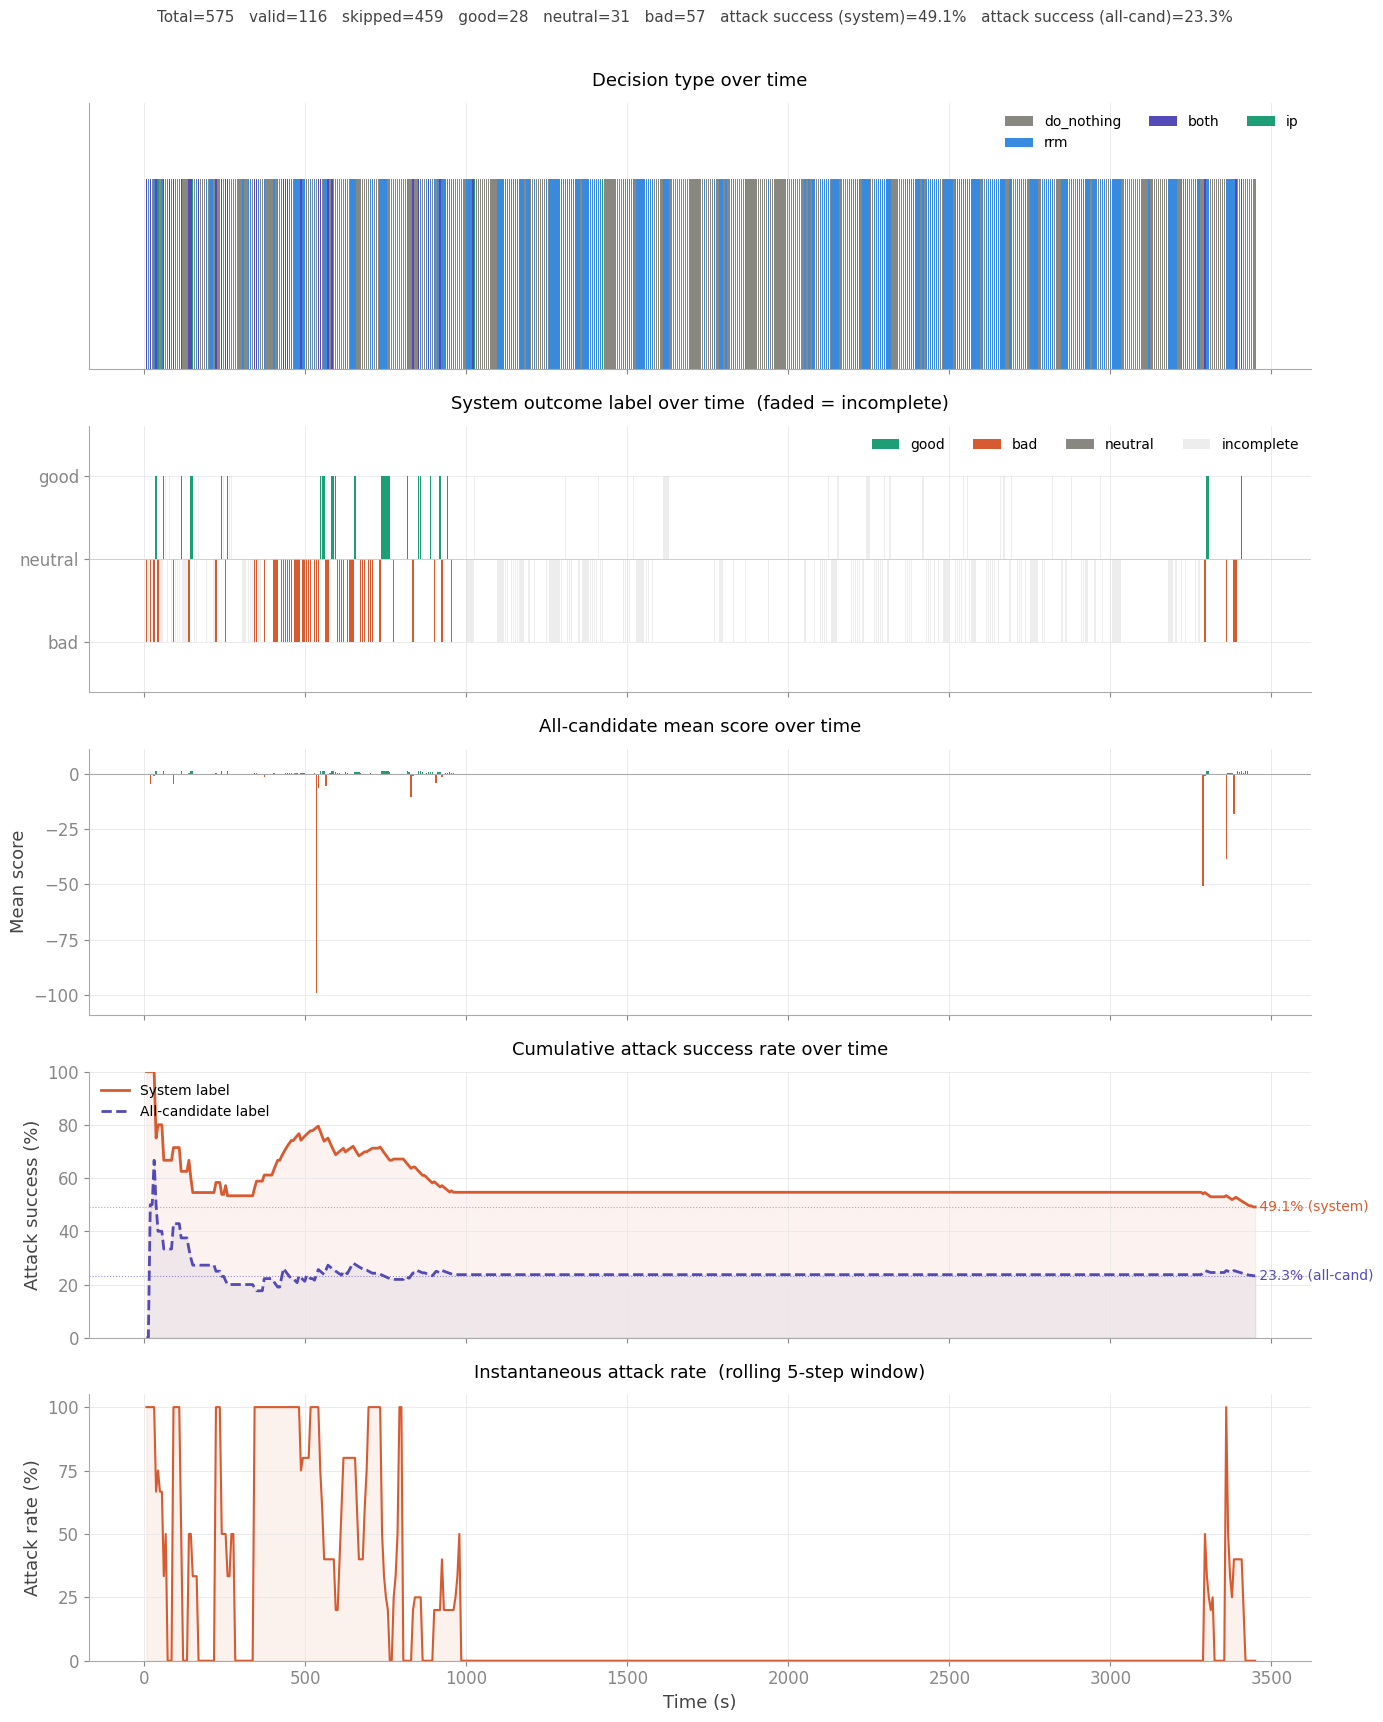

In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── config ─────────────────────────────────────────────────────────────────

MIN_AFTER_POINTS  = 2
POLLING_INTERVAL  = 6   # seconds per step — adjust to match your setup

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helpers ────────────────────────────────────────────────────────────────

MIN_AFTER_POINTS = 2

def has_full_after_points(record, n=MIN_AFTER_POINTS):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            for v in entry.get("after_points", {}).values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

def has_any_candidates(record):
    trace = record.get("validation_trace", {})
    return any(
        trace.get(k) for k in ("selected_hosts", "selected_links",
                               "other_candidate_hosts", "other_candidate_links")
    )

def get_decision(record):
    return record.get("decision", {}).get("final_decision", "unknown")

def all_candidate_scores(record):
    """Collect scores from ALL candidates — selected and other."""
    trace  = record.get("validation_trace", {})
    scores = []
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            if "score" in entry:
                # only include if enough after_points
                pts = entry.get("after_points", {})
                min_len = min(
                    (len(v) for v in pts.values() if isinstance(v, list)),
                    default=MIN_AFTER_POINTS
                )
                if min_len >= MIN_AFTER_POINTS:
                    scores.append(entry["score"])
    return scores

def derive_label(mean_score):
    if mean_score >  0.1:  return "good"
    if mean_score < -0.1:  return "bad"
    return "neutral"

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30", "neutral": "#888780"}
LABEL_VAL   = {"good": 1, "neutral": 0, "bad": -1}

DECISION_COLOR = {
    "do_nothing": "#888780",
    "rrm":        "#378ADD",
    "both":       "#534AB7",
    "ip":         "#1D9E75",
    "route":      "#BA7517",
    "unknown":    "#cccccc",
}

steps     = list(range(1, len(records) + 1))
times_sec = [s * POLLING_INTERVAL for s in steps]   # wall-clock seconds

labels     = []
scores     = []
all_scores = []   # mean across ALL candidates
valid      = []
decisions  = []

for r in records:
    outcome  = r.get("outcome", {})
    is_valid = has_full_after_points(r) and has_any_candidates(r)

    # system label/score
    labels.append(outcome.get("label", "neutral"))
    scores.append(outcome.get("score", 0.0))
    valid.append(is_valid)
    decisions.append(get_decision(r))

    # all-candidate mean score
    cand_scores = all_candidate_scores(r)
    if cand_scores and is_valid:
        all_scores.append(sum(cand_scores) / len(cand_scores))
    else:
        all_scores.append(None)

label_vals = [LABEL_VAL[l] for l in labels]

# derived label from all candidates
all_labels = [
    derive_label(s) if s is not None else "neutral"
    for s in all_scores
]

# cumulative attack success rate over time (valid steps only)
# using system label
cum_bad_sys, cum_valid_sys, run_sys, vsf_sys = [], [], 0, 0
# using all-candidate derived label
cum_bad_all, cum_valid_all, run_all, vsf_all = [], [], 0, 0

for l_sys, l_all, v in zip(labels, all_labels, valid):
    if v:
        vsf_sys += 1
        vsf_all += 1
        if l_sys  == "bad": run_sys += 1
        if l_all  == "bad": run_all += 1
    cum_bad_sys.append(run_sys);  cum_valid_sys.append(max(vsf_sys, 1))
    cum_bad_all.append(run_all);  cum_valid_all.append(max(vsf_all, 1))

attack_rate_sys = [b / t * 100 for b, t in zip(cum_bad_sys, cum_valid_sys)]
attack_rate_all = [b / t * 100 for b, t in zip(cum_bad_all, cum_valid_all)]

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.labelsize":     13,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     13,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(5, 1, figsize=(14, 17), sharex=True)
fig.subplots_adjust(hspace=0.5)

# ── plot 1: decision type ─────────────────────────────────────────────────

ax = axes[0]
for t, dec in zip(times_sec, decisions):
    ax.bar(t, 1, color=DECISION_COLOR.get(dec, "#cccccc"),
           width=POLLING_INTERVAL * 0.7, zorder=2)
ax.set_ylim(0, 1.4)
ax.set_yticks([])
ax.set_title("Decision type over time")
for dec, col in DECISION_COLOR.items():
    if dec in set(decisions):
        ax.bar(0, 0, color=col, label=dec)
ax.legend(loc="upper right", ncol=3)

# ── plot 2: system outcome label ──────────────────────────────────────────

ax = axes[1]
for t, lv, lab, v in zip(times_sec, label_vals, labels, valid):
    color = LABEL_COLOR[lab] if v else "#dddddd"
    ax.bar(t, lv, color=color, alpha=1.0 if v else 0.5,
           width=POLLING_INTERVAL * 0.7, zorder=2)
ax.axhline(0, color="#cccccc", linewidth=0.6)
ax.set_ylim(-1.6, 1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["bad", "neutral", "good"])
ax.set_title("System outcome label over time  (faded = incomplete)")
for lab, col in LABEL_COLOR.items():
    ax.bar(0, 0, color=col, label=lab)
ax.bar(0, 0, color="#dddddd", alpha=0.5, label="incomplete")
ax.legend(loc="upper right", ncol=4)

# ── plot 3: all-candidate mean score ─────────────────────────────────────

ax = axes[2]
for t, sc, lab, v in zip(times_sec, all_scores, all_labels, valid):
    if sc is None:
        ax.bar(t, 0, color="#dddddd", alpha=0.4,
               width=POLLING_INTERVAL * 0.7, zorder=2)
    else:
        ax.bar(t, sc, color=LABEL_COLOR[lab],
               width=POLLING_INTERVAL * 0.7, zorder=2)
ax.axhline(0, color="#aaaaaa", linewidth=0.8)
valid_all_sc = [s for s in all_scores if s is not None]
if valid_all_sc:
    mn, mx = min(valid_all_sc), max(valid_all_sc)
    pad = (mx - mn) * 0.1 or 0.5
    ax.set_ylim(mn - pad, mx + pad)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("All-candidate mean score over time")
ax.set_ylabel("Mean score")

# ── plot 4: cumulative attack success rate over time ─────────────────────

ax = axes[3]
ax.plot(times_sec, attack_rate_sys, color="#D85A30", linewidth=2,
        label="System label")
ax.plot(times_sec, attack_rate_all, color="#534AB7", linewidth=2,
        linestyle="--", label="All-candidate label")
ax.fill_between(times_sec, attack_rate_sys, alpha=0.07, color="#D85A30")
ax.fill_between(times_sec, attack_rate_all, alpha=0.07, color="#534AB7")

for rate, col, label in [
    (attack_rate_sys[-1], "#D85A30", "system"),
    (attack_rate_all[-1], "#534AB7", "all-cand"),
]:
    ax.axhline(rate, color=col, linewidth=0.8, linestyle=":", alpha=0.6)
    ax.text(times_sec[-1], rate, f" {rate:.1f}% ({label})",
            color=col, va="center", fontsize=10)

ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Cumulative attack success rate over time")
ax.set_ylabel("Attack success (%)")
ax.legend(loc="upper left")

# ── plot 5: instantaneous bad rate (rolling window) ───────────────────────

WINDOW = 5   # steps
ax = axes[4]
rolling = []
for i in range(len(labels)):
    window_labels = [
        labels[j] for j in range(max(0, i - WINDOW + 1), i + 1)
        if valid[j]
    ]
    if window_labels:
        rolling.append(window_labels.count("bad") / len(window_labels) * 100)
    else:
        rolling.append(0.0)

ax.plot(times_sec, rolling, color="#D85A30", linewidth=1.5)
ax.fill_between(times_sec, rolling, alpha=0.08, color="#D85A30")
ax.set_ylim(0, 105)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title(f"Instantaneous attack rate  (rolling {WINDOW}-step window)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Attack rate (%)")

# ── suptitle ───────────────────────────────────────────────────────────────

total   = len(records)
n_valid = sum(valid)
n_bad   = sum(1 for l, v in zip(labels, valid) if l == "bad"     and v)
n_good  = sum(1 for l, v in zip(labels, valid) if l == "good"    and v)
n_neut  = sum(1 for l, v in zip(labels, valid) if l == "neutral" and v)

fig.suptitle(
    f"Total={total}   valid={n_valid}   skipped={total - n_valid}   "
    f"good={n_good}   neutral={n_neut}   bad={n_bad}   "
    f"attack success (system)={attack_rate_sys[-1]:.1f}%   "
    f"attack success (all-cand)={attack_rate_all[-1]:.1f}%",
    fontsize=11, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 595 records


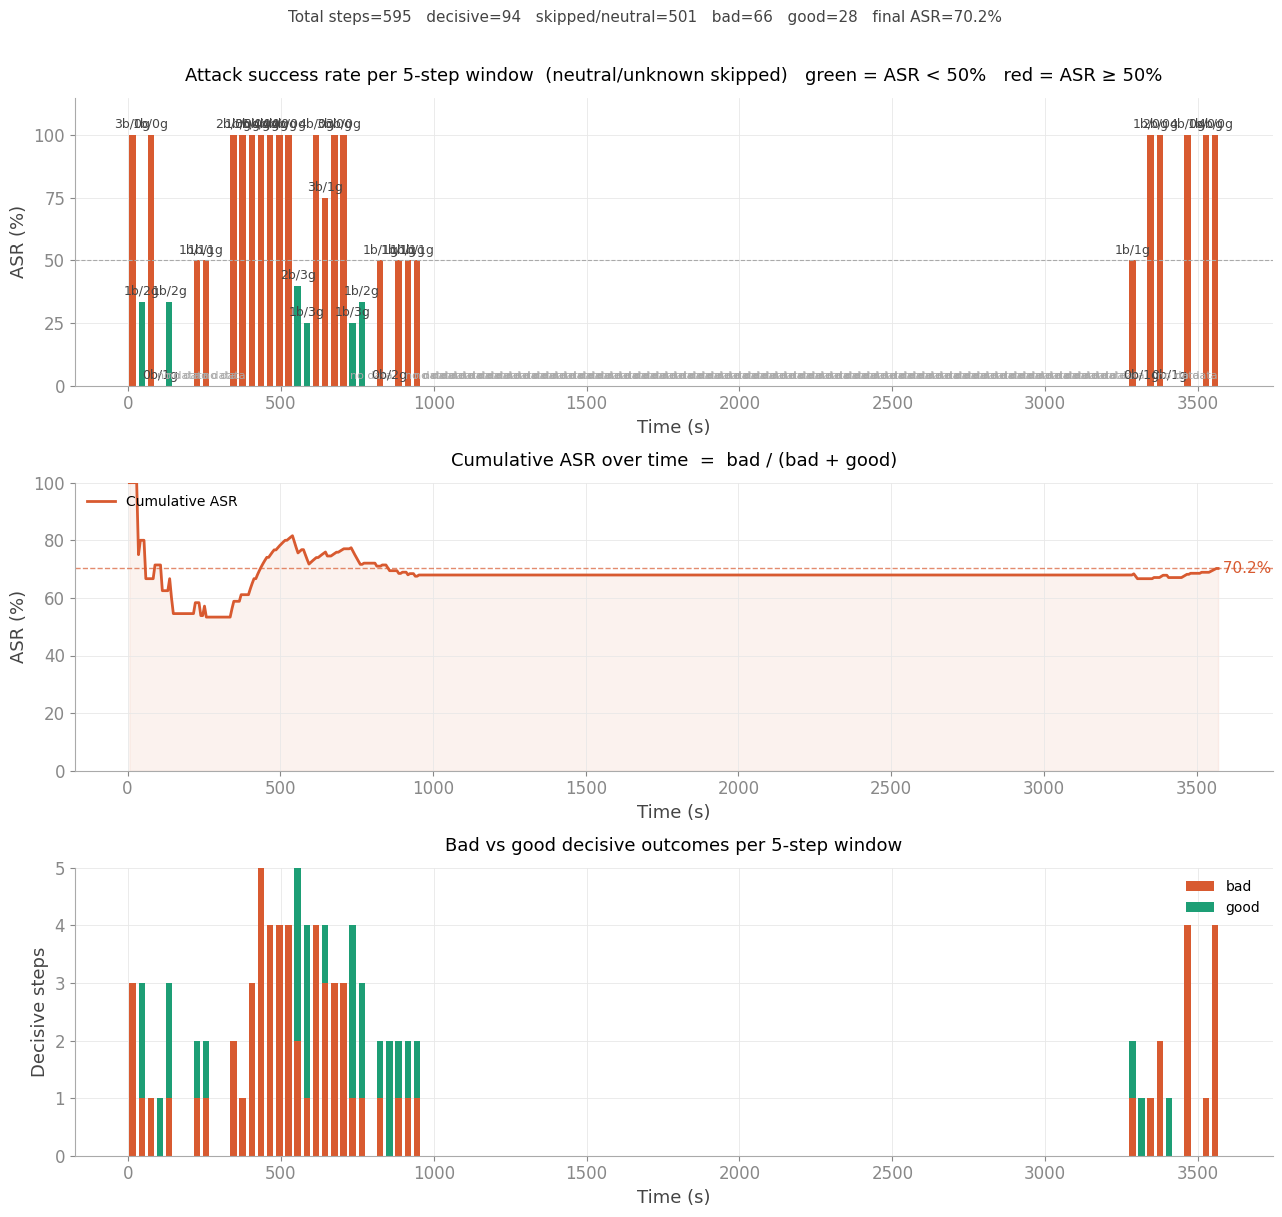

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── config ─────────────────────────────────────────────────────────────────

MIN_AFTER_POINTS = 2
POLLING_INTERVAL = 6    # seconds per step
WINDOW_SIZE      = 5    # steps per window

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helpers ────────────────────────────────────────────────────────────────

def has_full_after_points(record, n=MIN_AFTER_POINTS):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            for v in entry.get("after_points", {}).values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

def has_any_candidates(record):
    trace = record.get("validation_trace", {})
    return any(
        trace.get(k) for k in ("selected_hosts", "selected_links",
                               "other_candidate_hosts", "other_candidate_links")
    )

def get_decision(record):
    return record.get("decision", {}).get("final_decision", "unknown")

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30"}
DECISION_COLOR = {
    "do_nothing": "#888780",
    "rrm":        "#378ADD",
    "both":       "#534AB7",
    "ip":         "#1D9E75",
    "route":      "#BA7517",
}

labels    = []
valid     = []
decisions = []

for r in records:
    outcome  = r.get("outcome", {})
    is_valid = has_full_after_points(r) and has_any_candidates(r)
    lab      = outcome.get("label", "neutral")
    dec      = get_decision(r)
    labels.append(lab)
    valid.append(is_valid)
    decisions.append(dec)

# ── window ASR: parse every WINDOW_SIZE steps ─────────────────────────────
# only count decisive (bad or good) valid steps
# skip neutral, unknown, incomplete

window_times = []   # centre time of each window in seconds
window_asr   = []   # ASR for that window
window_bad   = []
window_good  = []
window_total = []

n = len(records)
for start in range(0, n, WINDOW_SIZE):
    end   = min(start + WINDOW_SIZE, n)
    chunk = [
        labels[i]
        for i in range(start, end)
        if valid[i] and labels[i] in ("bad", "good")
    ]

    n_bad  = chunk.count("bad")
    n_good = chunk.count("good")
    n_dec  = n_bad + n_good

    centre_step = (start + end) / 2
    window_times.append(centre_step * POLLING_INTERVAL)
    window_bad.append(n_bad)
    window_good.append(n_good)
    window_total.append(n_dec)
    window_asr.append(n_bad / n_dec * 100 if n_dec > 0 else None)

# cumulative ASR over time (decisive only)
cum_bad_run, cum_dec_run = 0, 0
cum_times, cum_asr = [], []
for i, (lab, v) in enumerate(zip(labels, valid)):
    if v and lab in ("bad", "good"):
        cum_dec_run += 1
        if lab == "bad":
            cum_bad_run += 1
    if cum_dec_run > 0:
        cum_times.append((i + 1) * POLLING_INTERVAL)
        cum_asr.append(cum_bad_run / cum_dec_run * 100)

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.labelsize":     13,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     13,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.subplots_adjust(hspace=0.5)

# ── plot 1: per-window ASR bar chart ─────────────────────────────────────

ax = axes[0]
bar_colors = []
for asr in window_asr:
    if asr is None:
        bar_colors.append("#dddddd")
    elif asr >= 50:
        bar_colors.append("#D85A30")
    else:
        bar_colors.append("#1D9E75")

bars = ax.bar(
    window_times,
    [a if a is not None else 0 for a in window_asr],
    width=WINDOW_SIZE * POLLING_INTERVAL * 0.7,
    color=bar_colors,
    zorder=2
)

# annotate each bar with bad/good counts
for t, asr, nb, ng, nd in zip(
        window_times, window_asr, window_bad, window_good, window_total):
    if nd > 0:
        ax.text(t, (asr or 0) + 1.5, f"{nb}b/{ng}g",
                ha="center", va="bottom", fontsize=9, color="#444444")
    else:
        ax.text(t, 2, "no data", ha="center", va="bottom",
                fontsize=8, color="#aaaaaa")

ax.set_ylim(0, 115)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_xlabel("Time (s)")
ax.set_ylabel("ASR (%)")
ax.set_title(f"Attack success rate per {WINDOW_SIZE}-step window  "
             f"(neutral/unknown skipped)   "
             f"green = ASR < 50%   red = ASR ≥ 50%")
ax.axhline(50, color="#aaaaaa", linewidth=0.8, linestyle="--")

# ── plot 2: cumulative ASR over time ─────────────────────────────────────

ax = axes[1]
ax.plot(cum_times, cum_asr, color="#D85A30", linewidth=2,
        label="Cumulative ASR")
ax.fill_between(cum_times, cum_asr, alpha=0.08, color="#D85A30")

if cum_asr:
    final = cum_asr[-1]
    ax.axhline(final, color="#D85A30", linewidth=1.0,
               linestyle="--", alpha=0.7)
    ax.text(cum_times[-1], final, f" {final:.1f}%",
            color="#D85A30", va="center", fontsize=11)

ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_xlabel("Time (s)")
ax.set_ylabel("ASR (%)")
ax.set_title("Cumulative ASR over time  =  bad / (bad + good)")
ax.legend(loc="upper left")

# ── plot 3: stacked bar — bad vs good per window ──────────────────────────

ax = axes[2]
w = WINDOW_SIZE * POLLING_INTERVAL * 0.7
ax.bar(window_times, window_bad,  width=w, color="#D85A30",
       label="bad",  zorder=2)
ax.bar(window_times, window_good, width=w, color="#1D9E75",
       label="good", bottom=window_bad, zorder=2)

ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Decisive steps")
ax.set_title(f"Bad vs good decisive outcomes per {WINDOW_SIZE}-step window")
ax.legend(loc="upper right")

# ── suptitle ───────────────────────────────────────────────────────────────

total_bad  = sum(window_bad)
total_good = sum(window_good)
total_dec  = total_bad + total_good
total_skip = sum(1 for l, v in zip(labels, valid)
                 if not v or l not in ("bad", "good"))
final_asr  = cum_asr[-1] if cum_asr else 0.0

fig.suptitle(
    f"Total steps={len(records)}   decisive={total_dec}   "
    f"skipped/neutral={total_skip}   "
    f"bad={total_bad}   good={total_good}   "
    f"final ASR={final_asr:.1f}%",
    fontsize=11, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

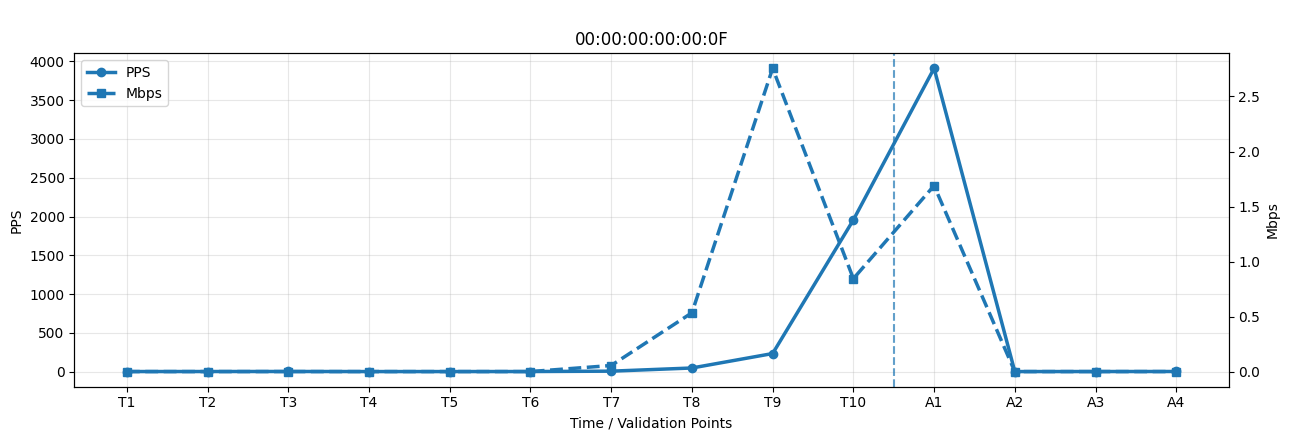

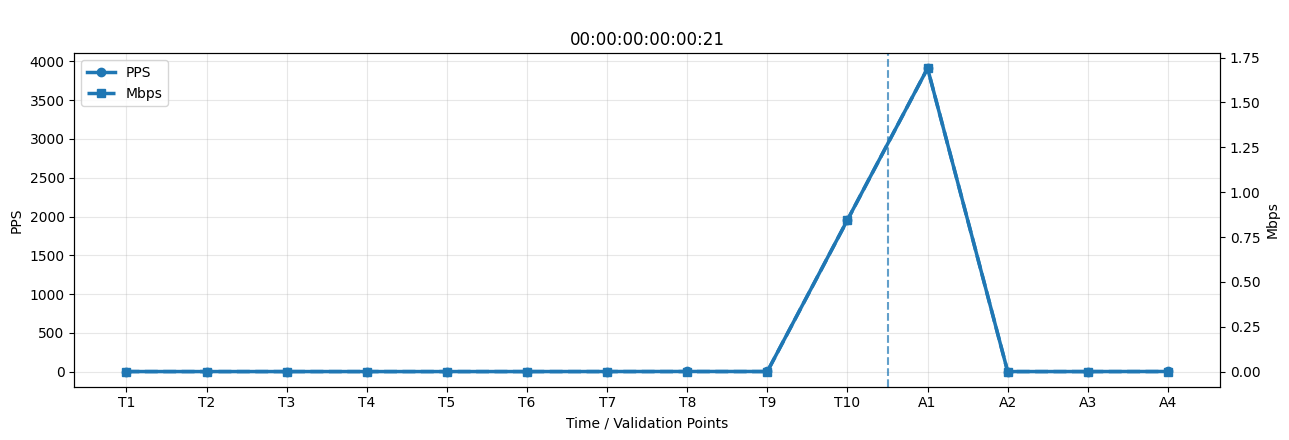

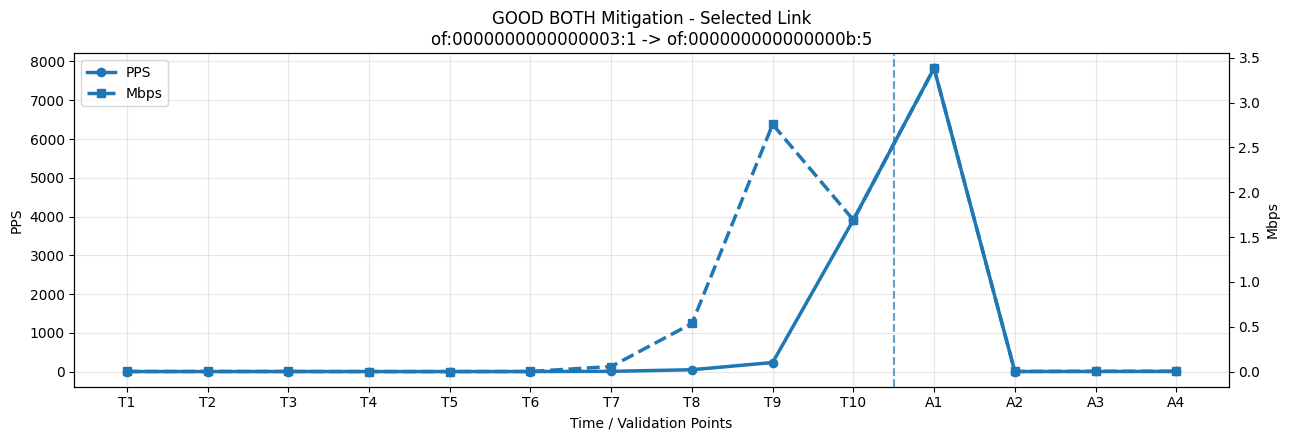

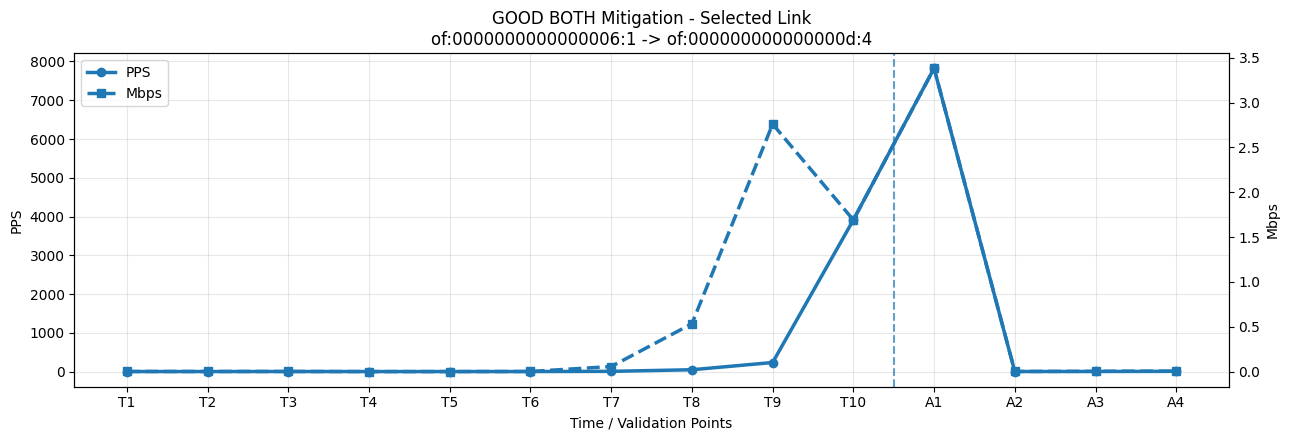

In [5]:
import matplotlib.pyplot as plt

record = {
    "candidates": {
        "host_stats": [
            {
                "mac": "00:00:00:00:00:0F",
                "tx_pps_trend": [0.85, 1.1, 1.7, 0.6, 0.6, 1.0, 5.69, 46.58, 232.94, 1955.96],
                "tx_kbps_trend": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 56.0, 535.0, 2756.0, 845.0],
            },
            {
                "mac": "00:00:00:00:00:21",
                "tx_pps_trend": [0.85, 0.6, 0.7, 0.6, 0.6, 0.7, 1.05, 1.65, 1.55, 1955.96],
                "tx_kbps_trend": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 845.0],
            },
        ],
        "link_stats": [
            {
                "link_id": "of:0000000000000003:1 -> of:000000000000000b:5",
                "rx_pps_trend": [1.55, 1.7, 2.4, 1.2, 1.2, 1.7, 6.74, 48.23, 234.49, 3911.93],
                "rx_kbps_trend": [2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 57.0, 537.0, 2757.0, 1691.0],
            },
            {
                "link_id": "of:0000000000000006:1 -> of:000000000000000d:4",
                "rx_pps_trend": [1.55, 1.7, 2.4, 1.2, 1.2, 1.7, 6.74, 48.03, 234.69, 3911.93],
                "rx_kbps_trend": [2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 57.0, 534.0, 2760.0, 1691.0],
            },
        ],
    },
    "validation_trace": {
        "selected_hosts": [
            {
                "mac": "00:00:00:00:00:0F",
                "after_points": {"pps": [3911.22, 0.6, 1.0, 1.5], "mbps": [1.69, 0.001, 0.001, 0.001]},
            },
            {
                "mac": "00:00:00:00:00:21",
                "after_points": {"pps": [3911.22, 0.6, 0.8, 1.6], "mbps": [1.69, 0.001, 0.001, 0.001]},
            },
        ],
        "selected_links": [
            {
                "link_id": "of:0000000000000003:1 -> of:000000000000000b:5",
                "after_points": {"pps": [7823.86, 2.4, 3.4, 4.2], "mbps": [3.382, 0.002, 0.004, 0.004]},
            },
            {
                "link_id": "of:0000000000000006:1 -> of:000000000000000d:4",
                "after_points": {"pps": [7823.86, 2.4, 3.0, 6.98], "mbps": [3.382, 0.002, 0.004, 0.006]},
            },
        ],
    },
}

def get_after(trace_list, key_name, key_value):
    for item in trace_list:
        if item.get(key_name) == key_value:
            return item["after_points"]
    return {"pps": [], "mbps": []}

def plot_10_before_4_after(name, before_pps, before_kbps, after_pps, after_mbps, title):
    pps = before_pps + after_pps
    mbps = [v / 1000 for v in before_kbps] + after_mbps

    x = list(range(1, len(pps) + 1))
    labels = [f"T{i}" for i in range(1, 11)] + [f"A{i}" for i in range(1, 5)]

    fig, ax1 = plt.subplots(figsize=(13, 4.5))

    ax1.plot(x, pps, marker="o", linewidth=2.5, label="PPS")
    ax1.axvline(10.5, linestyle="--", linewidth=1.5, alpha=0.7)
    # ax1.text(5.5, max(pps)*0.92, "10 candidate points", ha="center")
    # ax1.text(12.5, max(pps)*0.92, "4 after points", ha="center")

    ax1.set_xlabel("Time / Validation Points")
    ax1.set_ylabel("PPS")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, mbps, marker="s", linestyle="--", linewidth=2.5, label="Mbps")
    ax2.set_ylabel("Mbps")

    ax1.set_title(f"{title}\n{name}")

    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc="upper left")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Host plots: 10 candidate + 4 after
# -----------------------------
for h in record["candidates"]["host_stats"]:
    after = get_after(
        record["validation_trace"]["selected_hosts"],
        "mac",
        h["mac"]
    )

    plot_10_before_4_after(
        name=h["mac"],
        before_pps=h["tx_pps_trend"],
        before_kbps=h["tx_kbps_trend"],
        after_pps=after["pps"],
        after_mbps=after["mbps"],
        title=""
    )

# -----------------------------
# Link plots: 10 candidate + 4 after
# -----------------------------
for l in record["candidates"]["link_stats"]:
    after = get_after(
        record["validation_trace"]["selected_links"],
        "link_id",
        l["link_id"]
    )

    plot_10_before_4_after(
        name=l["link_id"],
        before_pps=l["rx_pps_trend"],
        before_kbps=l["rx_kbps_trend"],
        after_pps=after["pps"],
        after_mbps=after["mbps"],
        title="GOOD BOTH Mitigation - Selected Link"
    )

[WARN] Expected 215 rows, but found 201 rows.
Loaded rows: 676 to 890
Total scenes: 201

Classification Report:
                          precision    recall  f1-score   support

               No_Attack       1.00      1.00      1.00       100
             Low_Anomaly       0.00      0.00      0.00         0
Attack_Effective_Defense       1.00      1.00      1.00        28
     Attack_Weak_Defense       1.00      1.00      1.00        21
   Attack_Failed_Defense       1.00      0.75      0.86        52

                accuracy                           0.94       201
               macro avg       0.80      0.75      0.77       201
            weighted avg       1.00      0.94      0.96       201



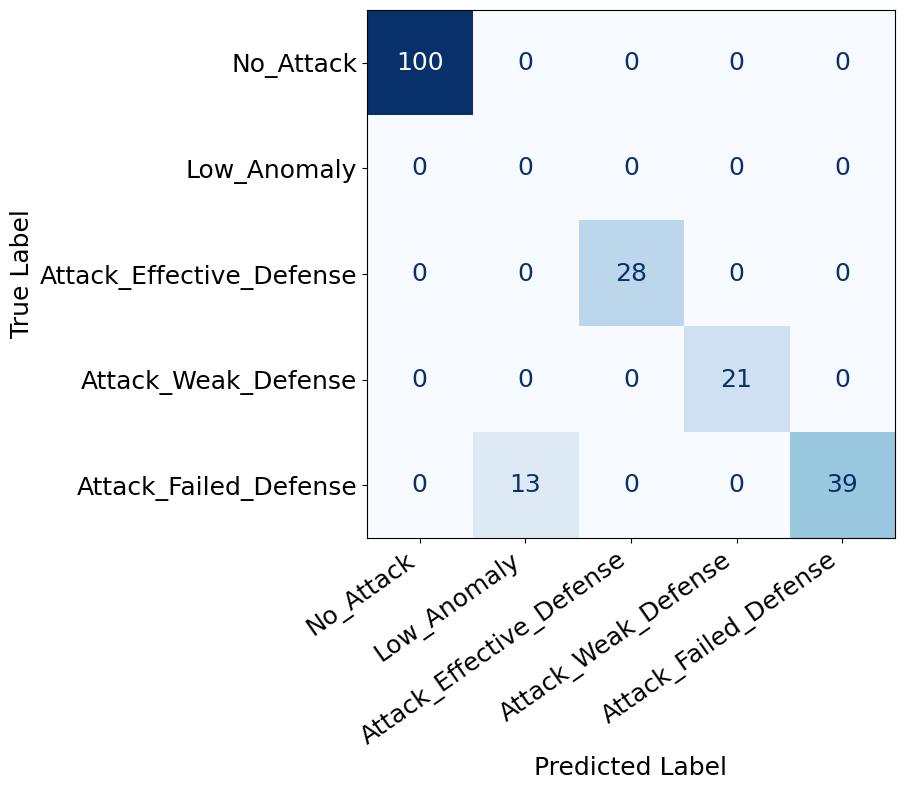

In [ ]:
# import json
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# # ==============================
# # CONFIG
# # ==============================
# JSONL_FILE = "examples.jsonl"

# START_ROW = 676
# END_ROW = 890

# ROW_NUMBERS = list(range(START_ROW, END_ROW + 1))

# LABELS = [
#     "No_Attack",
#     "Low_Anomaly",
#     "Attack_Effective_Defense",
#     "Attack_Weak_Defense",
#     "Attack_Failed_Defense"
# ]

# # ==============================
# # READ JSONL ROW RANGE
# # ==============================
# def read_jsonl_row_range(jsonl_file, start_row, end_row):
#     rows = []

#     with open(jsonl_file, "r", encoding="utf-8") as f:
#         for line_no, line in enumerate(f, start=1):
#             if start_row <= line_no <= end_row:
#                 line = line.strip()
#                 if line:
#                     rows.append(json.loads(line))

#             if line_no > end_row:
#                 break

#     expected = end_row - start_row + 1
#     if len(rows) != expected:
#         print(f"[WARN] Expected {expected} rows, but found {len(rows)} rows.")

#     return rows


# # ==============================
# # TRUE LABEL FROM JSONL OUTCOME
# # ==============================
# def map_row_to_true_label(row):
#     """
#     Uses outcome.label as the ground-truth outcome quality.
#     """
#     decision = row.get("decision", {}).get("final_decision", "do_nothing")
#     outcome_label = row.get("outcome", {}).get("label", "neutral")

#     if decision == "do_nothing":
#         return "No_Attack"

#     if outcome_label == "good":
#         return "Attack_Effective_Defense"

#     if outcome_label == "neutral":
#         return "Attack_Weak_Defense"

#     if outcome_label == "bad":
#         return "Attack_Failed_Defense"

#     return "Low_Anomaly"


# # ==============================
# # PREDICTED LABEL FROM DECISION
# # ==============================
# def map_row_to_pred_label(row):
#     """
#     Maps system decision + outcome into evaluation class.
#     """
#     decision = row.get("decision", {}).get("final_decision", "do_nothing")
#     outcome_label = row.get("outcome", {}).get("label", "neutral")

#     selected_hosts = row.get("validation_trace", {}).get("selected_hosts", [])
#     selected_links = row.get("validation_trace", {}).get("selected_links", [])

#     has_selected_targets = bool(selected_hosts or selected_links)
#     has_action = decision in ["ip", "rrm", "both"]

#     if decision == "do_nothing":
#         return "No_Attack"

#     if has_action and has_selected_targets and outcome_label == "good":
#         return "Attack_Effective_Defense"

#     if has_action and has_selected_targets and outcome_label == "neutral":
#         return "Attack_Weak_Defense"

#     if has_action and has_selected_targets and outcome_label == "bad":
#         return "Attack_Failed_Defense"

#     return "Low_Anomaly"


# # ==============================
# # BUILD LABELS
# # ==============================
# rows = read_jsonl_row_range(JSONL_FILE, START_ROW, END_ROW)

# y_true = [map_row_to_true_label(row) for row in rows]
# y_pred = [map_row_to_pred_label(row) for row in rows]

# print(f"Loaded rows: {START_ROW} to {END_ROW}")
# print(f"Total scenes: {len(rows)}")

# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# # ==============================
# # CONFUSION MATRIX
# # ==============================
# cm = confusion_matrix(y_true, y_pred, labels=LABELS)

# fig, ax = plt.subplots(figsize=(11, 8))

# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
# disp.plot(
#     ax=ax,
#     cmap="Blues",
#     colorbar=False,
#     values_format="d"
# )

# # Font size = 18 everywhere, no title
# ax.set_xlabel("Predicted Label", fontsize=18)
# ax.set_ylabel("True Label", fontsize=18)

# ax.set_xticklabels(LABELS, rotation=35, ha="right", fontsize=18)
# ax.set_yticklabels(LABELS, fontsize=18)

# for text in disp.text_.ravel():
#     text.set_fontsize(18)

# plt.tight_layout()
# plt.show()

In [9]:
import json
import pandas as pd

# ==============================
# CONFIG
# ==============================
JSONL_FILE = "examples.jsonl"
START_ROW = 1
END_ROW = 890

OUTPUT_CSV = "candidate_selection_dataset.csv"


# ==============================
# HELPER FUNCTIONS
# ==============================
def read_jsonl_range(jsonl_file, start_row, end_row):
    rows = []
    skipped_blank = 0
    skipped_bad_json = 0

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):

            if line_no > end_row:
                break

            if not (start_row <= line_no <= end_row):
                continue

            raw_line = line
            line = line.strip()

            # Skip blank lines
            if not line:
                skipped_blank += 1
                continue

            # Optional: only accept JSON object lines
            if not line.startswith("{"):
                skipped_bad_json += 1
                print(f"[SKIP] Line {line_no} does not start with '{{': {line[:80]}")
                continue

            try:
                data = json.loads(line)
            except json.JSONDecodeError as e:
                skipped_bad_json += 1
                print(f"[SKIP] Bad JSON at line {line_no}: {e}")
                print(f"       Preview: {line[:150]}")
                continue

            data["_row_number"] = line_no
            rows.append(data)

    print(f"[INFO] Loaded valid JSON rows: {len(rows)}")
    print(f"[INFO] Skipped blank lines: {skipped_blank}")
    print(f"[INFO] Skipped bad/non-JSON lines: {skipped_bad_json}")

    return rows


def safe_max(values):
    if not values:
        return 0.0
    return max(values)


def safe_mean(values):
    if not values:
        return 0.0
    return sum(values) / len(values)


def extract_trend_features(prefix, item):
    """
    Converts trend arrays into compact ML features.
    Example:
    rx_pps_trend -> max, mean, last, delta
    """
    features = {}

    trend_fields = [
        "rx_pps_trend",
        "tx_pps_trend",
        "rx_kbps_trend",
        "tx_kbps_trend"
    ]

    for field in trend_fields:
        values = item.get(field, [])

        features[f"{prefix}_{field}_max"] = safe_max(values)
        features[f"{prefix}_{field}_mean"] = safe_mean(values)
        features[f"{prefix}_{field}_last"] = values[-1] if values else 0.0
        features[f"{prefix}_{field}_first"] = values[0] if values else 0.0
        features[f"{prefix}_{field}_delta"] = values[-1] - values[0] if len(values) >= 2 else 0.0

    return features


# ==============================
# MAIN EXTRACTION
# ==============================
rows = read_jsonl_range(JSONL_FILE, START_ROW, END_ROW)

dataset_rows = []

for scene_id, row in enumerate(rows, start=1):
    row_number = row["_row_number"]

    decision = row.get("decision", {})
    final_decision = decision.get("final_decision", "do_nothing")

    selected_macs = set(decision.get("final_macs", []))
    selected_links = set(decision.get("final_links", []))

    outcome = row.get("outcome", {})
    outcome_label = outcome.get("label", "unknown")
    outcome_score = outcome.get("score", 0.0)

    candidates = row.get("candidates", {})
    host_candidates = candidates.get("host_stats", [])
    link_candidates = candidates.get("link_stats", [])

    # ------------------------------
    # Host candidates
    # ------------------------------
    for host in host_candidates:
        mac = host.get("mac")

        record = {
            "jsonl_row": row_number,
            "scene_id": scene_id,
            "candidate_type": "host",
            "candidate_id": mac,
            "final_decision": final_decision,
            "outcome_label": outcome_label,
            "outcome_score": outcome_score,

            # This is the target label
            "selected": 1 if mac in selected_macs else 0
        }

        record.update(extract_trend_features("host", host))
        dataset_rows.append(record)

    # ------------------------------
    # Link candidates
    # ------------------------------
    for link in link_candidates:
        link_id = link.get("link_id")

        record = {
            "jsonl_row": row_number,
            "scene_id": scene_id,
            "candidate_type": "link",
            "candidate_id": link_id,
            "final_decision": final_decision,
            "outcome_label": outcome_label,
            "outcome_score": outcome_score,

            # This is the target label
            "selected": 1 if link_id in selected_links else 0
        }

        record.update(extract_trend_features("link", link))
        dataset_rows.append(record)


df = pd.DataFrame(dataset_rows)

print("Total candidate rows:", len(df))
print(df["selected"].value_counts())
print(df["candidate_type"].value_counts())

df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved dataset to: {OUTPUT_CSV}")

df.head()

[SKIP] Line 38 does not start with '{': // upto this line we used h40-h41 as hidden candidate.
[INFO] Loaded valid JSON rows: 863
[INFO] Skipped blank lines: 15
[INFO] Skipped bad/non-JSON lines: 1
Total candidate rows: 6601
selected
0    4348
1    2253
Name: count, dtype: int64
candidate_type
link    4734
host    1867
Name: count, dtype: int64
Saved dataset to: candidate_selection_dataset.csv


,jsonl_row,scene_id,candidate_type,candidate_id,final_decision,outcome_label,outcome_score,selected,host_rx_pps_trend_max,host_rx_pps_trend_mean,...,link_rx_kbps_trend_max,link_rx_kbps_trend_mean,link_rx_kbps_trend_last,link_rx_kbps_trend_first,link_rx_kbps_trend_delta,link_tx_kbps_trend_max,link_tx_kbps_trend_mean,link_tx_kbps_trend_last,link_tx_kbps_trend_first,link_tx_kbps_trend_delta
0,1,1,host,00:00:00:00:00:0B,both,bad,-0.0664,1,0.96,0.176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,host,00:00:00:00:00:27,both,bad,-0.0664,1,24939.70,4235.120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,link,of:0000000000000003:2 -> of:0000000000000008:3,both,bad,-0.0664,1,NaN,NaN,...,289123.0,50238.9,1.0,1.0,0.0,284103.0,50443.9,1.0,1.0,0.0
3,1,1,link,of:0000000000000007:1 -> of:000000000000000d:5,both,bad,-0.0664,1,NaN,NaN,...,278710.0,50269.8,1.0,1.0,0.0,297279.0,50482.4,1.0,1.0,0.0
4,1,1,link,of:0000000000000008:1 -> of:000000000000000b:6,both,bad,-0.0664,1,NaN,NaN,...,284102.0,50443.8,1.0,1.0,0.0,261278.0,50321.9,2.0,1.0,1.0


In [11]:
import json

# ==============================
# CONFIG
# ==============================
JSONL_FILE = "examples.jsonl"
START_ROW = 0
END_ROW = 890

OUTPUT_JSONL = "test_dataset.jsonl"

TREND_LEN = 10


# ==============================
# READ JSONL RANGE SAFELY
# ==============================
def read_jsonl_range(jsonl_file, start_row, end_row):
    rows = []
    skipped_blank = 0
    skipped_non_json = 0
    skipped_bad_json = 0

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):

            if line_no > end_row:
                break

            if not (start_row <= line_no <= end_row):
                continue

            line = line.strip()

            if not line:
                skipped_blank += 1
                continue

            if not line.startswith("{"):
                skipped_non_json += 1
                print(f"[SKIP] Line {line_no} does not start with JSON: {line[:80]}")
                continue

            try:
                data = json.loads(line)
            except json.JSONDecodeError as e:
                skipped_bad_json += 1
                print(f"[SKIP] Bad JSON at line {line_no}: {e}")
                print(f"       Preview: {line[:150]}")
                continue

            data["_row_number"] = line_no
            rows.append(data)

    print(f"[INFO] Loaded valid rows: {len(rows)}")
    print(f"[INFO] Skipped blank lines: {skipped_blank}")
    print(f"[INFO] Skipped non-JSON lines: {skipped_non_json}")
    print(f"[INFO] Skipped bad JSON lines: {skipped_bad_json}")

    return rows


# ==============================
# HELPERS
# ==============================
def pad_or_trim(values, length=10):
    if values is None:
        values = []

    values = list(values)

    if len(values) >= length:
        return values[-length:]

    return values + [0.0] * (length - len(values))


def normalize_candidate(item, candidate_type, selected_ids, candidate_index, trend_len=10):
    if candidate_type == "host":
        candidate_id = item.get("mac")
    else:
        candidate_id = item.get("link_id")

    if not candidate_id:
        return None

    return {
        "candidate_index": candidate_index,
        "candidate_type": candidate_type,
        "candidate_id": candidate_id,
        "selected": 1 if candidate_id in selected_ids else 0,

        "rx_pps_trend": pad_or_trim(item.get("rx_pps_trend", []), trend_len),
        "tx_pps_trend": pad_or_trim(item.get("tx_pps_trend", []), trend_len),
        "rx_kbps_trend": pad_or_trim(item.get("rx_kbps_trend", []), trend_len),
        "tx_kbps_trend": pad_or_trim(item.get("tx_kbps_trend", []), trend_len),
    }


# ==============================
# BUILD DATASET
# ==============================
rows = read_jsonl_range(JSONL_FILE, START_ROW, END_ROW)

scene_dataset = []

for scene_id, row in enumerate(rows, start=1):
    row_number = row["_row_number"]

    decision = row.get("decision", {})
    final_decision = decision.get("final_decision", "do_nothing")

    selected_macs = set(decision.get("final_macs", []))
    selected_links = set(decision.get("final_links", []))

    outcome = row.get("outcome", {})
    outcome_label = outcome.get("label", "unknown")
    outcome_score = outcome.get("score", 0.0)
    selected_score = outcome.get("selected_score", None)
    other_candidate_score = outcome.get("other_candidate_score", None)

    mtd_action = row.get("mtd_action", {})
    ip_changes = mtd_action.get("ip_changes", "")
    route_changes = mtd_action.get("route_changes", "")

    candidates = row.get("candidates", {})
    host_candidates_raw = candidates.get("host_stats", [])
    link_candidates_raw = candidates.get("link_stats", [])

    host_candidates = []
    link_candidates = []

    for idx, host in enumerate(host_candidates_raw, start=1):
        normalized = normalize_candidate(
            item=host,
            candidate_type="host",
            selected_ids=selected_macs,
            candidate_index=idx,
            trend_len=TREND_LEN
        )

        if normalized is not None:
            host_candidates.append(normalized)

    for idx, link in enumerate(link_candidates_raw, start=1):
        normalized = normalize_candidate(
            item=link,
            candidate_type="link",
            selected_ids=selected_links,
            candidate_index=idx,
            trend_len=TREND_LEN
        )

        if normalized is not None:
            link_candidates.append(normalized)

    scene_record = {
        "jsonl_row": row_number,
        "scene_id": scene_id,

        "final_decision": final_decision,
        "selected_macs": list(selected_macs),
        "selected_links": list(selected_links),

        "outcome_label": outcome_label,
        "outcome_score": outcome_score,
        "selected_score": selected_score,
        "other_candidate_score": other_candidate_score,

        "ip_changes": ip_changes,
        "route_changes": route_changes,

        "num_host_candidates": len(host_candidates),
        "num_link_candidates": len(link_candidates),

        "host_candidates": host_candidates,
        "link_candidates": link_candidates
    }

    scene_dataset.append(scene_record)


# ==============================
# SAVE JSONL
# ==============================
with open(OUTPUT_JSONL, "w", encoding="utf-8") as f:
    for scene in scene_dataset:
        f.write(json.dumps(scene) + "\n")

print(f"[SAVED] {OUTPUT_JSONL}")
print(f"Total scenes saved: {len(scene_dataset)}")

# Preview first scene
if scene_dataset:
    print(json.dumps(scene_dataset[0], indent=2)[:3000])

[SKIP] Line 38 does not start with JSON: // upto this line we used h40-h41 as hidden candidate.
[INFO] Loaded valid rows: 863
[INFO] Skipped blank lines: 15
[INFO] Skipped non-JSON lines: 1
[INFO] Skipped bad JSON lines: 0
[SAVED] test_dataset.jsonl
Total scenes saved: 863
{
  "jsonl_row": 1,
  "scene_id": 1,
  "final_decision": "both",
  "selected_macs": [
    "00:00:00:00:00:27",
    "00:00:00:00:00:0B"
  ],
  "selected_links": [
    "of:0000000000000007:1 -> of:000000000000000d:5",
    "of:0000000000000003:2 -> of:0000000000000008:3",
    "of:0000000000000008:1 -> of:000000000000000b:6"
  ],
  "outcome_label": "bad",
  "outcome_score": -0.0664,
  "selected_score": -0.0664,
  "other_candidate_score": 0.0,
  "ip_changes": "",
  "route_changes": "",
  "num_host_candidates": 2,
  "num_link_candidates": 3,
  "host_candidates": [
    {
      "candidate_index": 1,
      "candidate_type": "host",
      "candidate_id": "00:00:00:00:00:0B",
      "selected": 1,
      "rx_pps_trend": [
       

Reading logs from: /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/csv_logs


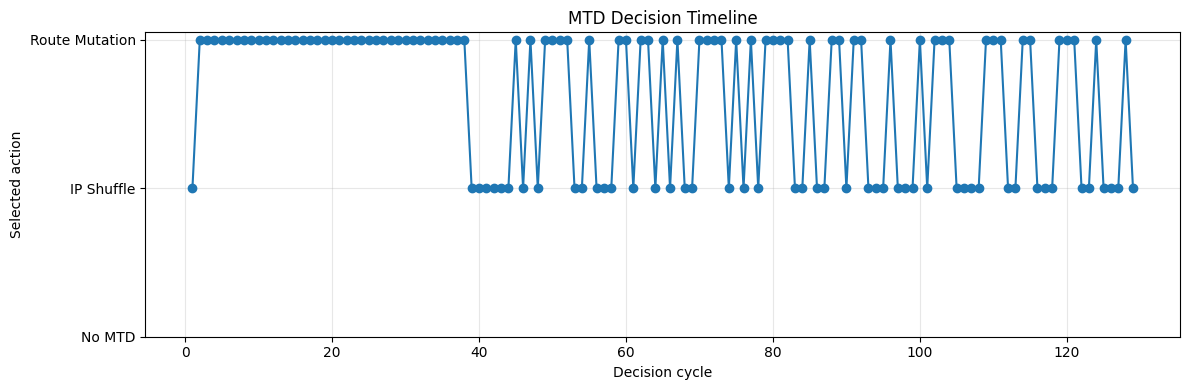

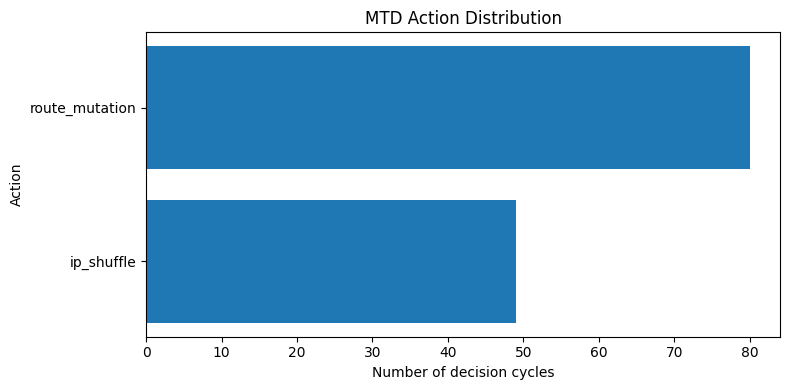

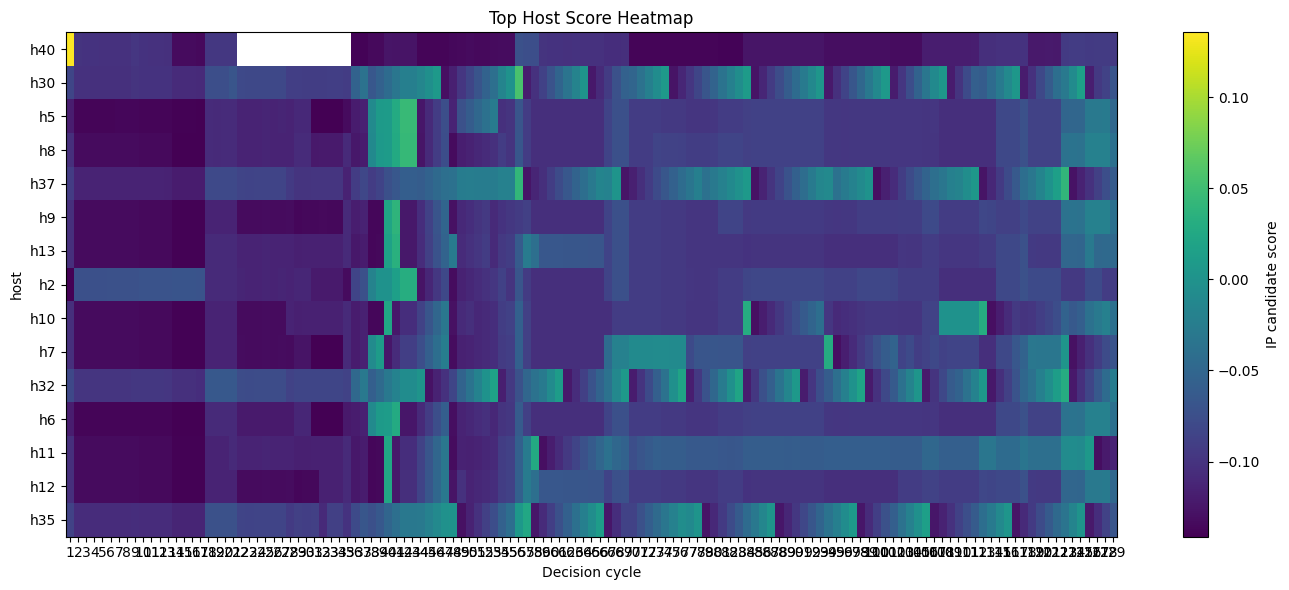

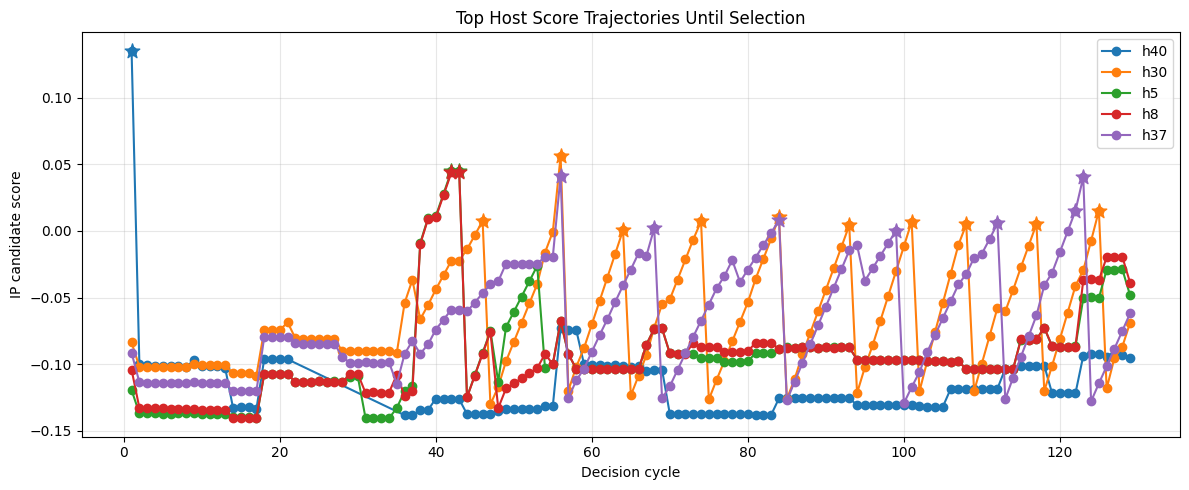

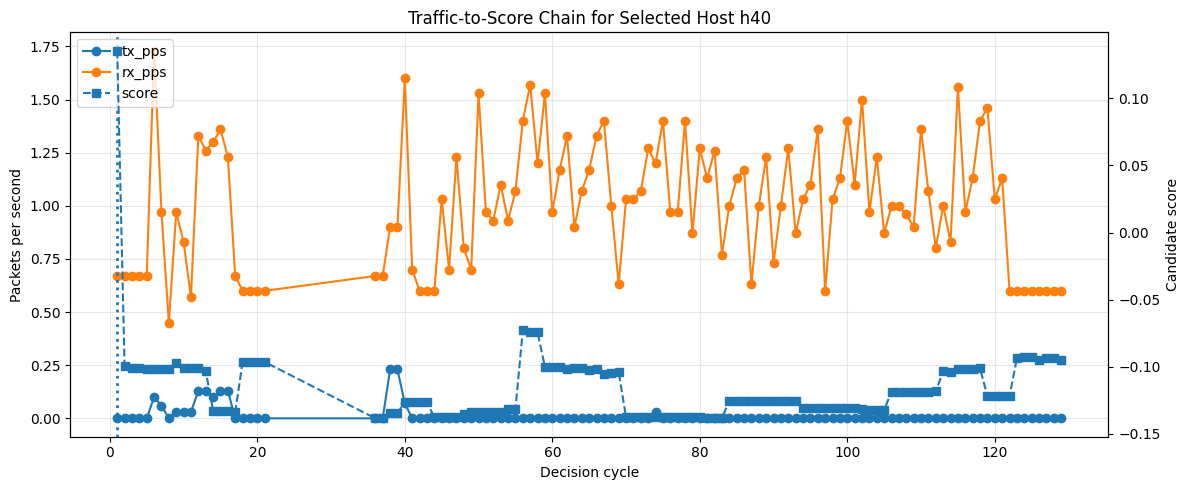

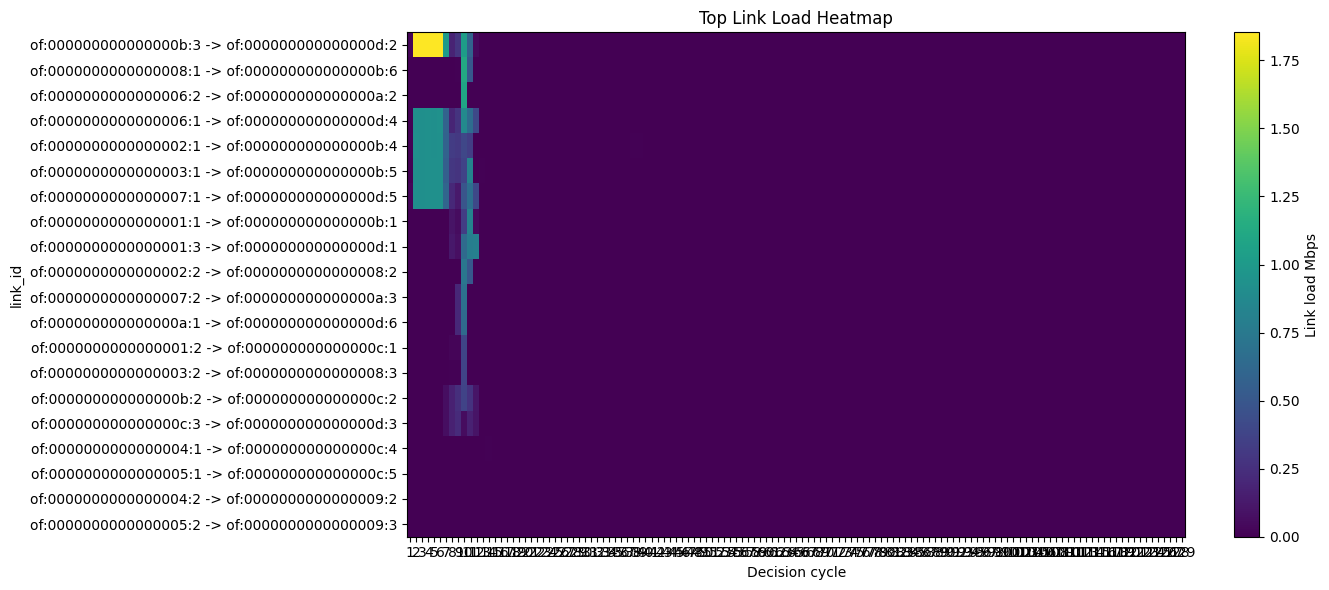

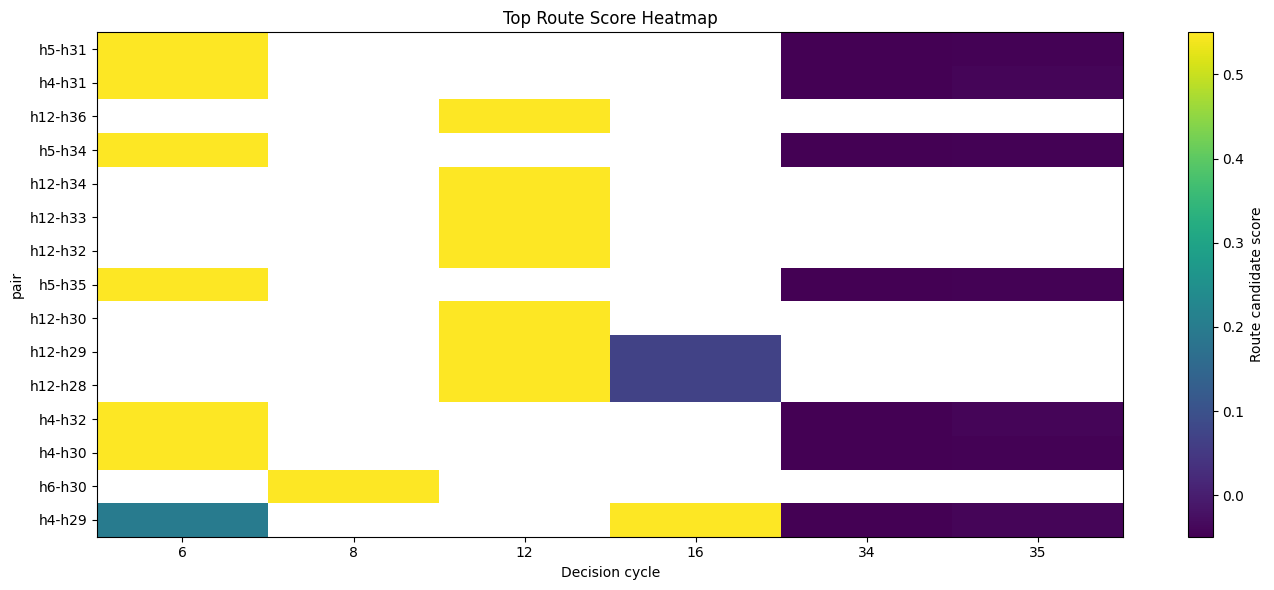

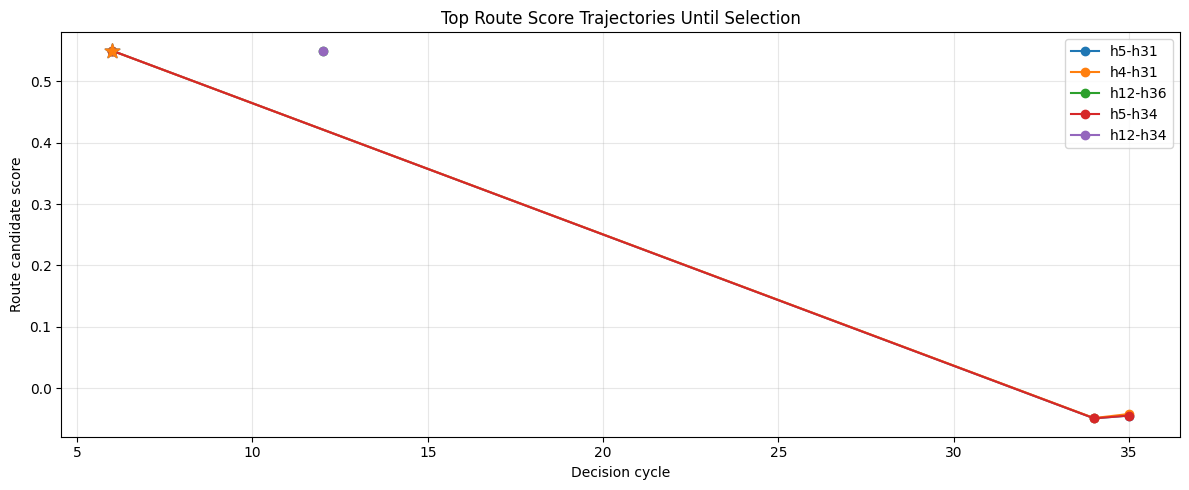

In [12]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path.cwd()
LOG_DIR = BASE_DIR / "proactive_files" / "logger" / "csv_logs"

print("Reading logs from:", LOG_DIR)


def load_csv(name):
    path = LOG_DIR / name
    if not path.exists():
        print(f"[SKIP] Missing {name}")
        return pd.DataFrame()
    return pd.read_csv(path)


def add_cycle_index(df):
    if df.empty:
        return df

    df = df.copy()

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df = df.sort_values("timestamp")

    if "cycle_id" in df.columns:
        cycles = pd.Series(df["cycle_id"].dropna().unique())
        cycle_map = {c: i + 1 for i, c in enumerate(cycles)}
        df["cycle_idx"] = df["cycle_id"].map(cycle_map)
    else:
        df["cycle_idx"] = np.arange(1, len(df) + 1)

    return df


def show_plot():
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_decision_timeline():
    df = add_cycle_index(load_csv("decision_summary.csv"))
    if df.empty or "action" not in df.columns:
        return

    action_map = {
        "no_mtd": 0,
        "ip_shuffle": 1,
        "route_mutation": 2,
    }

    df["action_code"] = df["action"].map(action_map).fillna(-1)

    plt.figure(figsize=(12, 4))
    plt.plot(df["cycle_idx"], df["action_code"], marker="o")
    plt.yticks([0, 1, 2], ["No MTD", "IP Shuffle", "Route Mutation"])
    plt.xlabel("Decision cycle")
    plt.ylabel("Selected action")
    plt.title("MTD Decision Timeline")
    plt.grid(True, alpha=0.3)
    show_plot()


def plot_action_counts():
    df = load_csv("decision_summary.csv")
    if df.empty or "action" not in df.columns:
        return

    counts = df["action"].value_counts().sort_values()

    plt.figure(figsize=(8, 4))
    plt.barh(counts.index, counts.values)
    plt.xlabel("Number of decision cycles")
    plt.ylabel("Action")
    plt.title("MTD Action Distribution")
    show_plot()


def heatmap(csv_name, row_col, value_col, title, cbar_label, top_n=15):
    df = add_cycle_index(load_csv(csv_name))
    needed = {"cycle_idx", row_col, value_col}

    if df.empty or not needed.issubset(df.columns):
        print(f"[SKIP] {title}")
        return

    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

    top_items = (
        df.groupby(row_col)[value_col]
        .max()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    pivot = (
        df[df[row_col].isin(top_items)]
        .pivot_table(
            index=row_col,
            columns="cycle_idx",
            values=value_col,
            aggfunc="max"
        )
        .loc[top_items]
    )

    plt.figure(figsize=(14, 6))
    im = plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(im, label=cbar_label)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Decision cycle")
    plt.ylabel(row_col)
    plt.title(title)
    show_plot()


def trajectories(csv_name, id_col, title, ylabel, top_n=5):
    df = add_cycle_index(load_csv(csv_name))
    needed = {"cycle_idx", id_col, "score", "selected"}

    if df.empty or not needed.issubset(df.columns):
        print(f"[SKIP] {title}")
        return

    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df["selected"] = pd.to_numeric(df["selected"], errors="coerce").fillna(0)

    top_items = (
        df.groupby(id_col)["score"]
        .max()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    plt.figure(figsize=(12, 5))

    for item in top_items:
        sub = df[df[id_col] == item].sort_values("cycle_idx")
        plt.plot(sub["cycle_idx"], sub["score"], marker="o", label=item)

        chosen = sub[sub["selected"] == 1]
        if not chosen.empty:
            plt.scatter(
                chosen["cycle_idx"],
                chosen["score"],
                s=120,
                marker="*",
                zorder=5
            )

    plt.xlabel("Decision cycle")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    show_plot()


def plot_selected_host_chain():
    host_df = add_cycle_index(load_csv("host_snapshot.csv"))
    score_df = add_cycle_index(load_csv("ip_score_snapshot.csv"))

    if host_df.empty or score_df.empty:
        return

    needed_host = {"cycle_idx", "host", "tx_pps", "rx_pps"}
    needed_score = {"cycle_idx", "host", "score", "selected"}

    if not needed_host.issubset(host_df.columns) or not needed_score.issubset(score_df.columns):
        print("[SKIP] Selected host chain")
        return

    score_df["selected"] = pd.to_numeric(score_df["selected"], errors="coerce").fillna(0)
    selected = score_df[score_df["selected"] == 1]

    if selected.empty:
        print("[SKIP] No selected host found")
        return

    host = selected.iloc[0]["host"]

    hraw = host_df[host_df["host"] == host].sort_values("cycle_idx").copy()
    hscore = score_df[score_df["host"] == host].sort_values("cycle_idx").copy()

    hraw["tx_pps"] = pd.to_numeric(hraw["tx_pps"], errors="coerce")
    hraw["rx_pps"] = pd.to_numeric(hraw["rx_pps"], errors="coerce")
    hscore["score"] = pd.to_numeric(hscore["score"], errors="coerce")

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(hraw["cycle_idx"], hraw["tx_pps"], marker="o", label="tx_pps")
    ax1.plot(hraw["cycle_idx"], hraw["rx_pps"], marker="o", label="rx_pps")
    ax1.set_xlabel("Decision cycle")
    ax1.set_ylabel("Packets per second")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(hscore["cycle_idx"], hscore["score"], marker="s", linestyle="--", label="score")
    ax2.set_ylabel("Candidate score")

    for c in hscore[hscore["selected"] == 1]["cycle_idx"]:
        ax1.axvline(c, linestyle=":", linewidth=2)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title(f"Traffic-to-Score Chain for Selected Host {host}")
    show_plot()


def run_all_plots():
    plot_decision_timeline()
    plot_action_counts()

    heatmap(
        "ip_score_snapshot.csv",
        "host",
        "score",
        "Top Host Score Heatmap",
        "IP candidate score",
        top_n=15
    )

    trajectories(
        "ip_score_snapshot.csv",
        "host",
        "Top Host Score Trajectories Until Selection",
        "IP candidate score",
        top_n=5
    )

    plot_selected_host_chain()

    heatmap(
        "link_snapshot.csv",
        "link_id",
        "link_mbps",
        "Top Link Load Heatmap",
        "Link load Mbps",
        top_n=20
    )

    heatmap(
        "route_score_snapshot.csv",
        "pair",
        "score",
        "Top Route Score Heatmap",
        "Route candidate score",
        top_n=15
    )

    trajectories(
        "route_score_snapshot.csv",
        "pair",
        "Top Route Score Trajectories Until Selection",
        "Route candidate score",
        top_n=5
    )


run_all_plots()

Reading logs from: /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/csv_logs


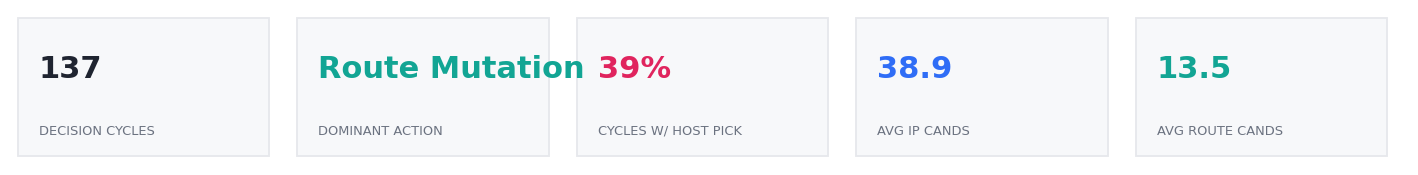

/tmp/ipykernel_158183/1353353766.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


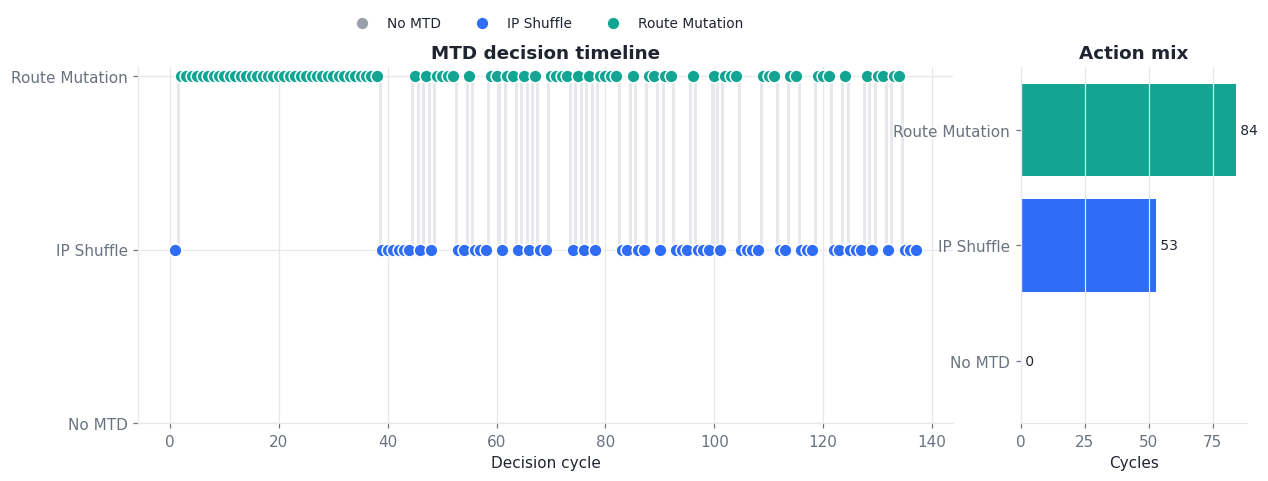

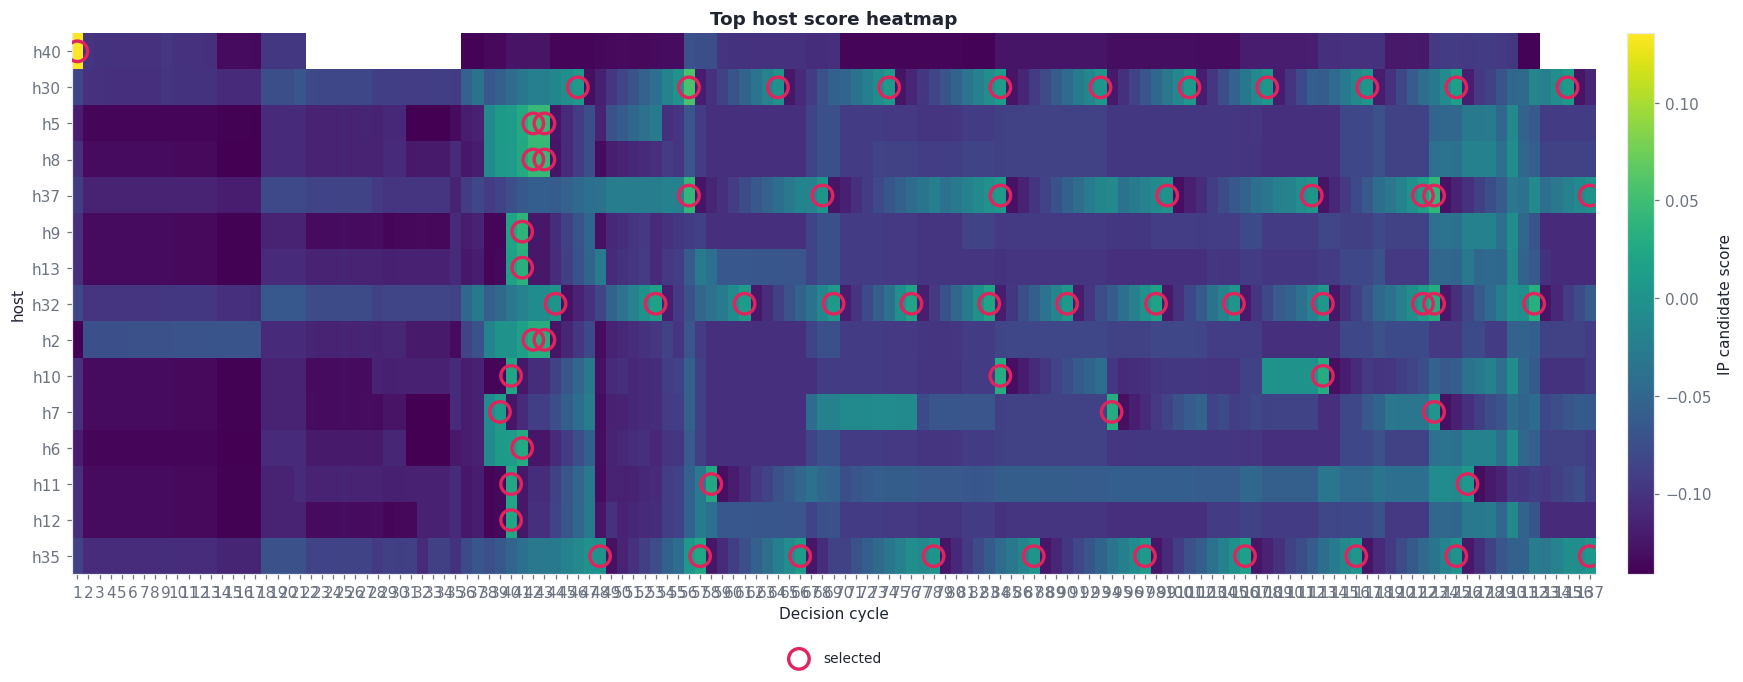

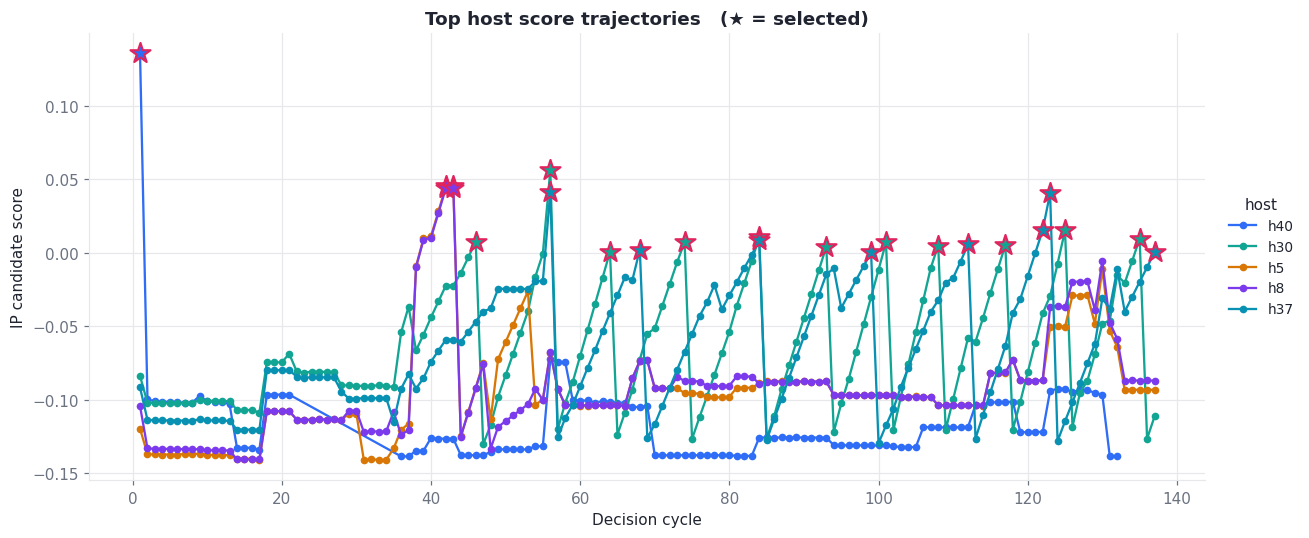

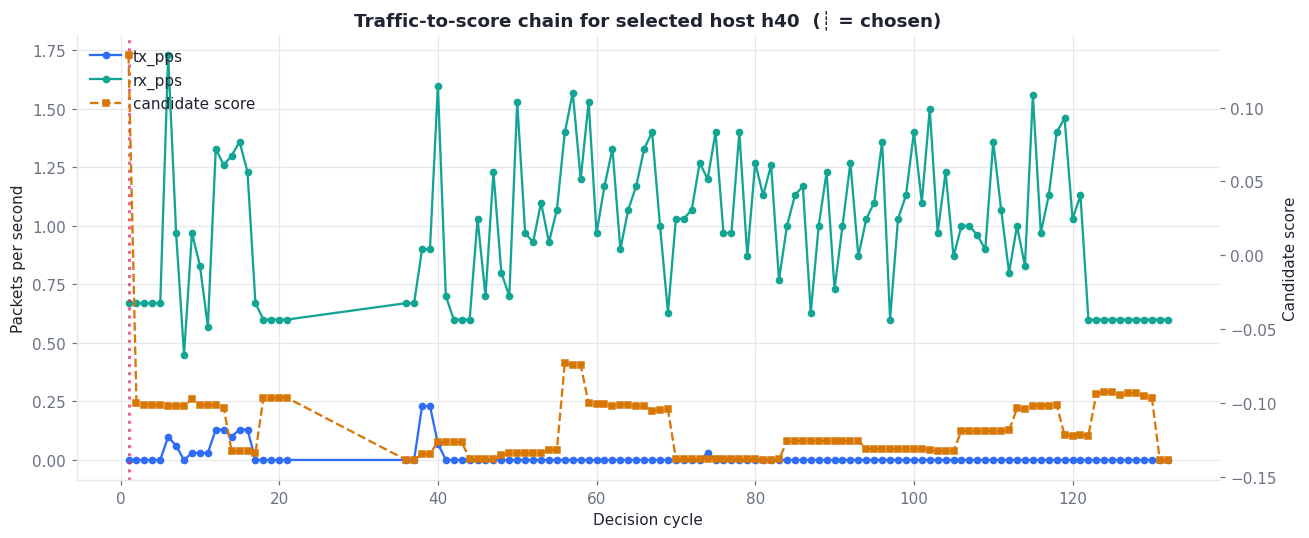

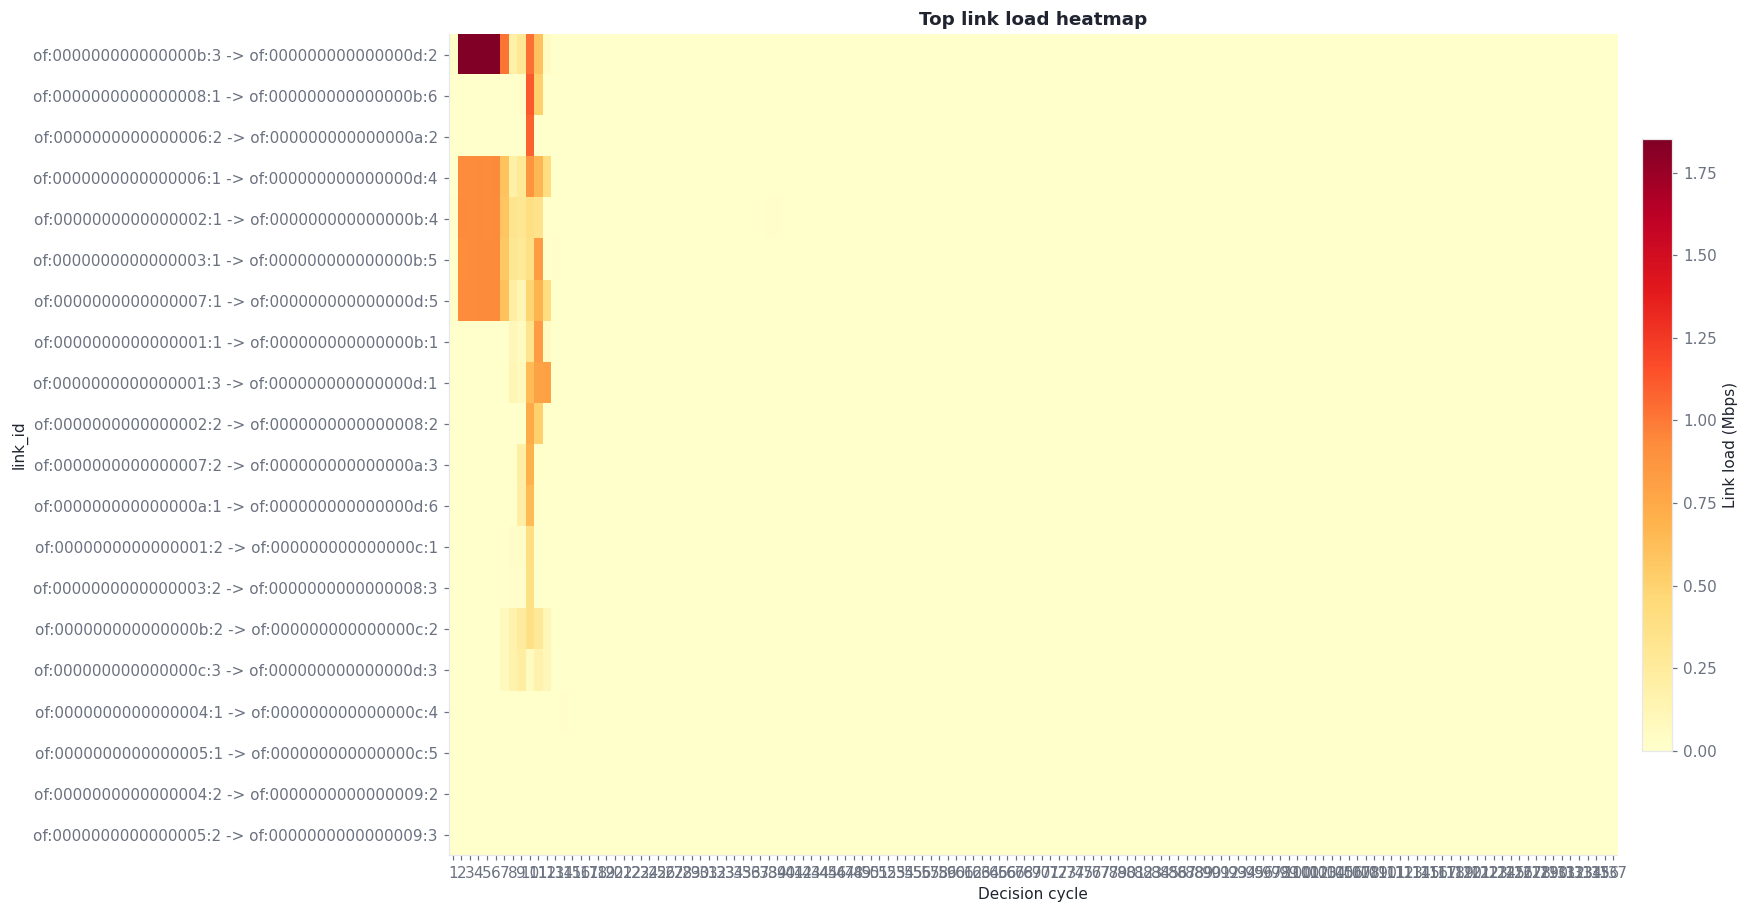

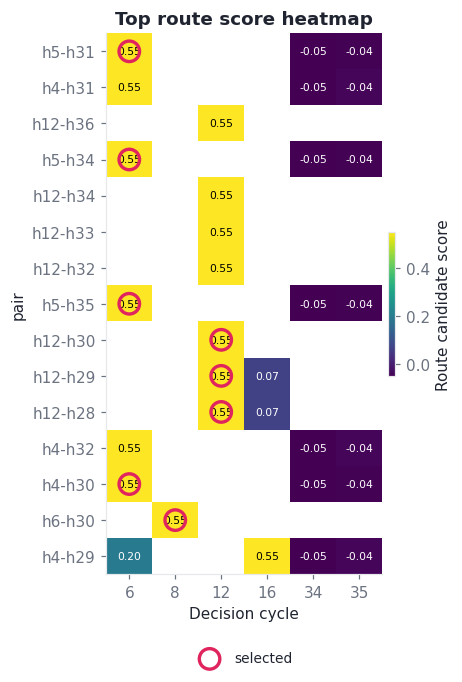

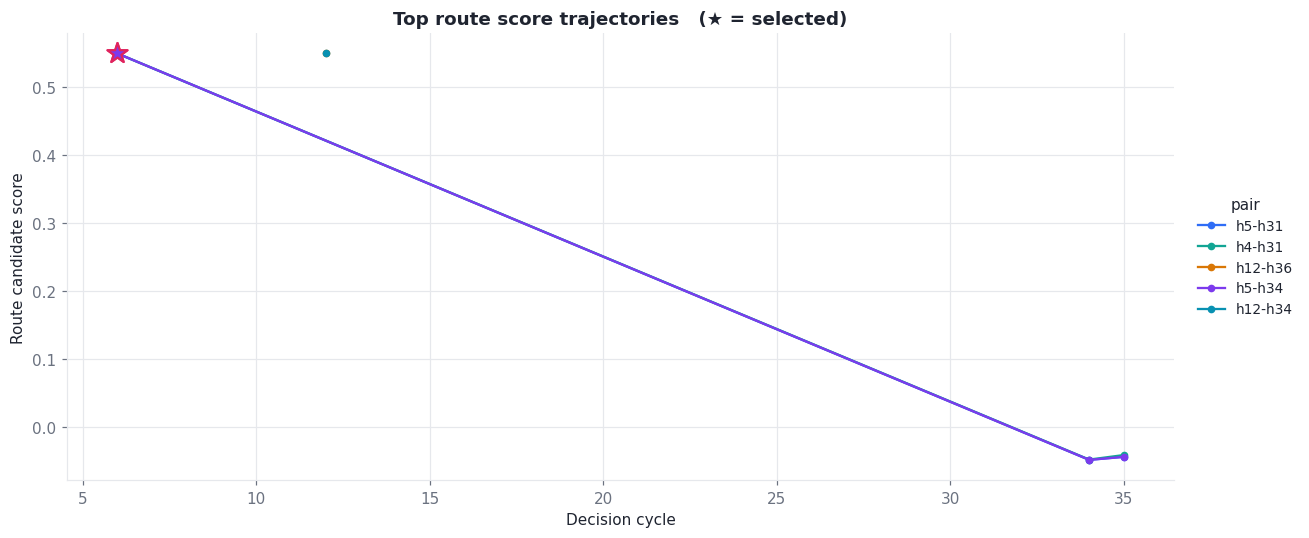

/tmp/ipykernel_158183/1353353766.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


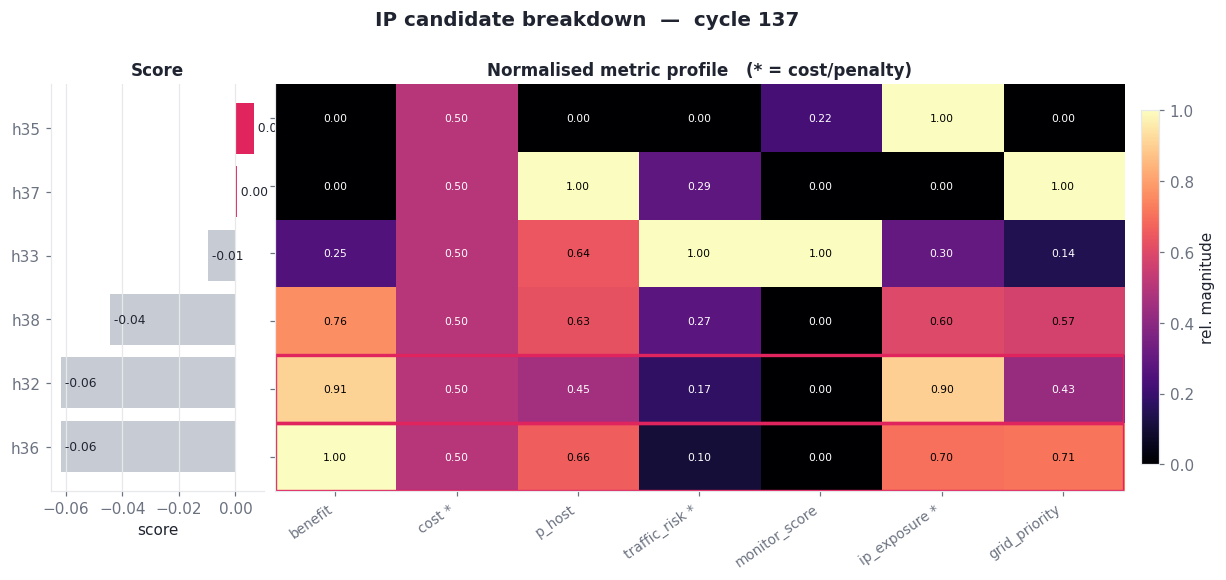

/tmp/ipykernel_158183/1353353766.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


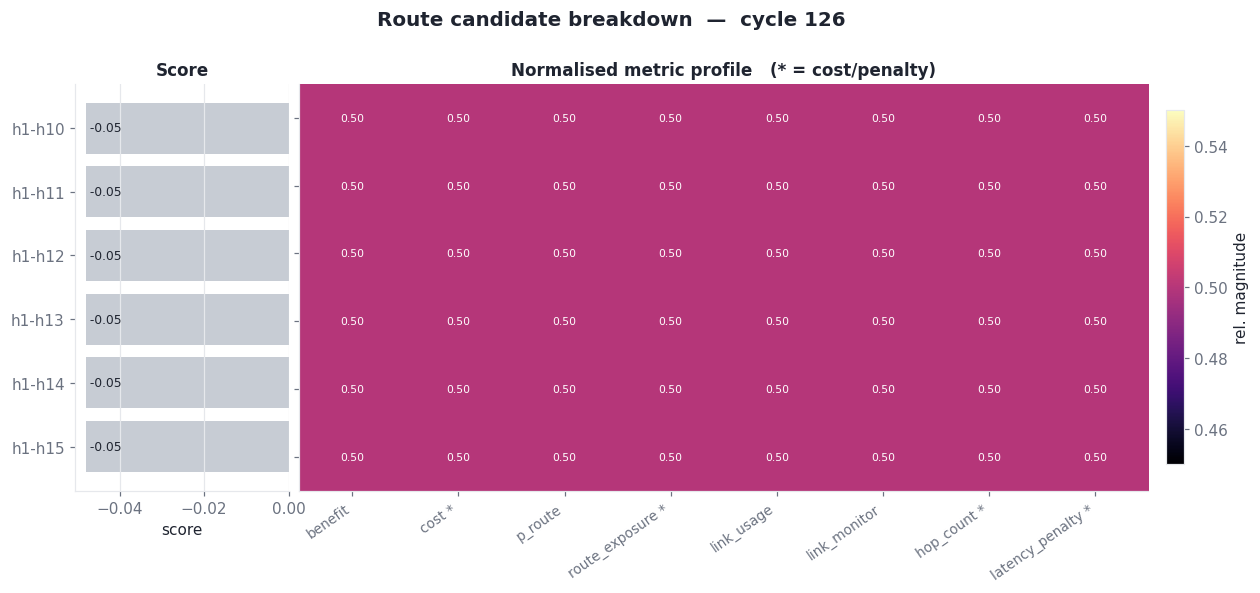

In [13]:
%matplotlib inline
# ================================================================
# Enhanced visualization for the proactive MTD decision logs.
# Drop this whole cell in after your logger has produced csv_logs/.
# Adds: KPI strip, action-coloured decision timeline, annotated
# heatmaps with selection markers, cleaner score trajectories,
# and a per-candidate metric breakdown (the "why was this chosen"
# view) for any cycle.
# ================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---------------------------------------------------------------- paths
BASE_DIR = Path.cwd()
LOG_DIR = BASE_DIR / "proactive_files" / "logger" / "csv_logs"
print("Reading logs from:", LOG_DIR)

# ---------------------------------------------------------------- theme
ACTION_ORDER = ["no_mtd", "ip_shuffle", "route_mutation"]
ACTION_LABELS = {"no_mtd": "No MTD", "ip_shuffle": "IP Shuffle", "route_mutation": "Route Mutation"}
ACTION_COLORS = {"no_mtd": "#9aa0aa", "ip_shuffle": "#2f6df6", "route_mutation": "#12a594"}
SELECT_COLOR = "#e0245e"
LINE_COLORS = ["#2f6df6", "#12a594", "#d97706", "#7c3aed", "#0891b2", "#65a30d", "#db2777"]
INK, MUTED, GRID = "#1f2430", "#6b7280", "#e6e8ec"

# Metrics that are *costs/penalties* (high value hurts the objective).
COST_METRICS = {"cost", "latency_penalty", "hop_count", "traffic_risk", "ip_exposure", "route_exposure"}


def set_style():
    plt.rcParams.update({
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK,
        "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
        "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
    })


set_style()

# ---------------------------------------------------------------- loaders
def load_csv(name):
    path = LOG_DIR / name
    if not path.exists():
        print(f"[skip] missing {name}")
        return pd.DataFrame()
    return pd.read_csv(path)


def add_cycle_index(df):
    if df.empty:
        return df
    df = df.copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df = df.sort_values("timestamp")
    if "cycle_id" in df.columns:
        order = {c: i + 1 for i, c in enumerate(df["cycle_id"].dropna().unique())}
        df["cycle_idx"] = df["cycle_id"].map(order)
    else:
        df["cycle_idx"] = np.arange(1, len(df) + 1)
    return df


def numify(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def _finish(title=None):
    if title:
        plt.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()


# ---------------------------------------------------------------- 1. KPI strip
def kpi_strip():
    dec = add_cycle_index(load_csv("decision_summary.csv"))
    if dec.empty:
        return
    dec = numify(dec, ["n_ip_candidates", "n_route_candidates"])
    ip = numify(add_cycle_index(load_csv("ip_score_snapshot.csv")), ["selected"])

    n_cycles = int(dec["cycle_idx"].nunique())
    counts = dec["action"].value_counts() if "action" in dec else pd.Series(dtype=int)
    dom = counts.idxmax() if not counts.empty else "-"
    sel_rate = "-"
    if not ip.empty and "selected" in ip:
        per_cycle = ip.groupby("cycle_idx")["selected"].max()
        sel_rate = f"{100 * per_cycle.fillna(0).mean():.0f}%"

    cards = [
        ("Decision cycles", str(n_cycles), INK),
        ("Dominant action", ACTION_LABELS.get(dom, dom), ACTION_COLORS.get(dom, INK)),
        ("Cycles w/ host pick", sel_rate, SELECT_COLOR),
        ("Avg IP cands", f"{dec['n_ip_candidates'].mean():.1f}" if "n_ip_candidates" in dec else "-", "#2f6df6"),
        ("Avg route cands", f"{dec['n_route_candidates'].mean():.1f}" if "n_route_candidates" in dec else "-", "#12a594"),
    ]

    fig, ax = plt.subplots(figsize=(13, 1.7))
    ax.axis("off")
    for i, (label, value, color) in enumerate(cards):
        x = i / len(cards)
        ax.add_patch(plt.Rectangle((x + 0.005, 0.05), 1 / len(cards) - 0.02, 0.9,
                                   transform=ax.transAxes, facecolor="#f7f8fa",
                                   edgecolor=GRID, linewidth=1.2, zorder=0))
        ax.text(x + 0.02, 0.62, value, transform=ax.transAxes,
                fontsize=20, fontweight="bold", color=color, va="center")
        ax.text(x + 0.02, 0.22, label.upper(), transform=ax.transAxes,
                fontsize=8.5, color=MUTED, va="center")
    _finish()


# ---------------------------------------------------------------- 2. decision overview
def decision_overview():
    df = add_cycle_index(load_csv("decision_summary.csv"))
    if df.empty or "action" not in df.columns:
        return

    fig = plt.figure(figsize=(13, 4.2))
    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.3)
    ax_tl = fig.add_subplot(gs[0, :3])
    ax_bar = fig.add_subplot(gs[0, 3])

    code = {a: i for i, a in enumerate(ACTION_ORDER)}
    df["code"] = df["action"].map(code)

    # step line for context, coloured dots per action
    ax_tl.step(df["cycle_idx"], df["code"], where="mid", color=GRID, linewidth=2, zorder=1)
    for action in ACTION_ORDER:
        sub = df[df["action"] == action]
        ax_tl.scatter(sub["cycle_idx"], sub["code"], s=70, zorder=3,
                      color=ACTION_COLORS[action], label=ACTION_LABELS[action],
                      edgecolor="white", linewidth=1)
    ax_tl.set_yticks(range(len(ACTION_ORDER)))
    ax_tl.set_yticklabels([ACTION_LABELS[a] for a in ACTION_ORDER])
    ax_tl.set_xlabel("Decision cycle")
    ax_tl.set_title("MTD decision timeline")
    ax_tl.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=3, fontsize=9)

    counts = df["action"].value_counts().reindex(ACTION_ORDER).fillna(0)
    ax_bar.barh([ACTION_LABELS[a] for a in counts.index], counts.values,
                color=[ACTION_COLORS[a] for a in counts.index])
    for y, v in enumerate(counts.values):
        ax_bar.text(v, y, f" {int(v)}", va="center", fontsize=9, color=INK)
    ax_bar.set_xlabel("Cycles")
    ax_bar.set_title("Action mix")
    ax_bar.grid(axis="y", visible=False)
    _finish()


# ---------------------------------------------------------------- 3. annotated heatmap
def annotated_heatmap(csv_name, row_col, value_col, title, cbar_label,
                      cmap="viridis", top_n=15, mark_selected=True):
    df = add_cycle_index(load_csv(csv_name))
    if df.empty or not {"cycle_idx", row_col, value_col}.issubset(df.columns):
        print(f"[skip] {title}")
        return
    df = numify(df, [value_col, "selected"])

    top = (df.groupby(row_col)[value_col].max()
             .sort_values(ascending=False).head(top_n).index)
    sub = df[df[row_col].isin(top)]
    pivot = sub.pivot_table(index=row_col, columns="cycle_idx",
                            values=value_col, aggfunc="max").loc[top]

    h = max(3.5, 0.42 * len(pivot.index))
    fig, ax = plt.subplots(figsize=(min(16, 1.0 + 0.55 * len(pivot.columns)), h))
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    fig.colorbar(im, ax=ax, label=cbar_label, fraction=0.025, pad=0.02)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Decision cycle")
    ax.set_ylabel(row_col)
    ax.set_title(title)
    ax.grid(False)

    # annotate values when the grid is small enough to stay legible
    if pivot.size <= 200:
        vmax = np.nanmax(pivot.values) if np.isfinite(pivot.values).any() else 1
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                            color="white" if v < 0.6 * vmax else "black")

    # ring the cells that were actually selected
    if mark_selected and "selected" in sub.columns:
        sel = (sub[sub["selected"] == 1]
               .pivot_table(index=row_col, columns="cycle_idx",
                            values="selected", aggfunc="max"))
        sel = sel.reindex(index=pivot.index, columns=pivot.columns)
        ys, xs = np.where(sel.fillna(0).values == 1)
        ax.scatter(xs, ys, s=180, facecolors="none",
                   edgecolors=SELECT_COLOR, linewidths=2.2, zorder=5, label="selected")
        if len(xs):
            ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=9)
    _finish()


# ---------------------------------------------------------------- 4. score trajectories
def score_trajectories(csv_name, id_col, title, ylabel, top_n=5):
    df = add_cycle_index(load_csv(csv_name))
    if df.empty or not {"cycle_idx", id_col, "score", "selected"}.issubset(df.columns):
        print(f"[skip] {title}")
        return
    df = numify(df, ["score", "selected"])
    df["selected"] = df["selected"].fillna(0)

    top = (df.groupby(id_col)["score"].max()
             .sort_values(ascending=False).head(top_n).index)

    fig, ax = plt.subplots(figsize=(12, 5))
    for k, item in enumerate(top):
        s = df[df[id_col] == item].sort_values("cycle_idx")
        c = LINE_COLORS[k % len(LINE_COLORS)]
        ax.plot(s["cycle_idx"], s["score"], marker="o", ms=4, color=c, label=str(item))
        chosen = s[s["selected"] == 1]
        ax.scatter(chosen["cycle_idx"], chosen["score"], s=190, marker="*",
                   color=c, edgecolor=SELECT_COLOR, linewidth=1.4, zorder=6)
    ax.set_xlabel("Decision cycle")
    ax.set_ylabel(ylabel)
    ax.set_title(title + "   (★ = selected)")
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title=id_col, fontsize=9)
    _finish()


# ---------------------------------------------------------------- 5. selected host chain
def selected_host_chain():
    host_df = add_cycle_index(load_csv("host_snapshot.csv"))
    score_df = add_cycle_index(load_csv("ip_score_snapshot.csv"))
    if host_df.empty or score_df.empty:
        return
    if not {"cycle_idx", "host", "tx_pps", "rx_pps"}.issubset(host_df.columns):
        print("[skip] selected host chain")
        return
    score_df = numify(score_df, ["selected", "score"])
    score_df["selected"] = score_df["selected"].fillna(0)
    sel = score_df[score_df["selected"] == 1]
    if sel.empty:
        print("[skip] no selected host found")
        return

    host = sel.iloc[0]["host"]
    hraw = numify(host_df[host_df["host"] == host].sort_values("cycle_idx"), ["tx_pps", "rx_pps"])
    hscore = score_df[score_df["host"] == host].sort_values("cycle_idx")

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(hraw["cycle_idx"], hraw["tx_pps"], marker="o", ms=4, color="#2f6df6", label="tx_pps")
    ax1.plot(hraw["cycle_idx"], hraw["rx_pps"], marker="o", ms=4, color="#12a594", label="rx_pps")
    ax1.set_xlabel("Decision cycle")
    ax1.set_ylabel("Packets per second")

    ax2 = ax1.twinx()
    ax2.plot(hscore["cycle_idx"], hscore["score"], marker="s", ms=4, ls="--",
             color="#d97706", label="candidate score")
    ax2.set_ylabel("Candidate score")
    ax2.grid(False)

    for c in hscore[hscore["selected"] == 1]["cycle_idx"]:
        ax1.axvline(c, ls=":", lw=2, color=SELECT_COLOR, alpha=0.7)

    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc="upper left")
    ax1.set_title(f"Traffic-to-score chain for selected host {host}  (┊ = chosen)")
    _finish()


# ---------------------------------------------------------------- 6. metric breakdown ("why chosen")
def metric_breakdown(csv_name, id_col, metric_cols, title, cycle="latest", top_n=6):
    """Per-candidate metric profile for one cycle: raw score ranking on the
    left, a normalised metric heatmap on the right so you can read *which*
    factors drove each candidate's score. Cost-type metrics are flagged."""
    df = add_cycle_index(load_csv(csv_name))
    if df.empty or id_col not in df.columns:
        print(f"[skip] {title}")
        return
    metric_cols = [m for m in metric_cols if m in df.columns]
    df = numify(df, ["score", "selected"] + metric_cols)

    cyc = df["cycle_idx"].max() if cycle == "latest" else int(cycle)
    cur = df[df["cycle_idx"] == cyc].copy()
    if cur.empty:
        print(f"[skip] {title}: no rows for cycle {cyc}")
        return
    cur = cur.sort_values("score", ascending=False).head(top_n).iloc[::-1]  # best at top
    labels = cur[id_col].astype(str).tolist()
    sel_mask = (cur.get("selected", 0).fillna(0) == 1).tolist()

    # normalise each metric across the shown candidates (0..1 column-wise)
    norm = cur[metric_cols].astype(float)
    rng = norm.max() - norm.min()
    norm = (norm - norm.min()) / rng.replace(0, np.nan)
    norm = norm.fillna(0.5)  # flat metric -> neutral

    fig = plt.figure(figsize=(13, max(3.2, 0.6 * len(labels) + 1.2)))
    gs = gridspec.GridSpec(1, 5, figure=fig, wspace=0.05)
    axb = fig.add_subplot(gs[0, 0])
    axh = fig.add_subplot(gs[0, 1:])

    # left: score bars, selected highlighted
    bar_colors = [SELECT_COLOR if s else "#c7ccd4" for s in sel_mask]
    axb.barh(range(len(labels)), cur["score"].values, color=bar_colors)
    axb.set_yticks(range(len(labels)))
    axb.set_yticklabels(labels)
    axb.set_xlabel("score")
    axb.set_title("Score", fontsize=11)
    axb.grid(axis="y", visible=False)
    for y, v in enumerate(cur["score"].values):
        axb.text(v, y, f" {v:.2f}", va="center", fontsize=8)

    # right: normalised metric heatmap
    im = axh.imshow(norm.values, aspect="auto", cmap="magma")
    axh.set_xticks(range(len(metric_cols)))
    col_labels = [(m + " *" if m in COST_METRICS else m) for m in metric_cols]
    axh.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=9)
    axh.set_yticks(range(len(labels)))
    axh.set_yticklabels([])
    axh.grid(False)
    axh.set_title("Normalised metric profile   (* = cost/penalty)", fontsize=11)
    fig.colorbar(im, ax=axh, fraction=0.02, pad=0.02, label="rel. magnitude")

    for i in range(norm.shape[0]):
        for j in range(norm.shape[1]):
            v = norm.values[i, j]
            axh.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if v < 0.55 else "black")
        if sel_mask[i]:
            axh.add_patch(plt.Rectangle((-0.5, i - 0.5), len(metric_cols), 1,
                                        fill=False, edgecolor=SELECT_COLOR, lw=2.2))
    _finish(f"{title}  —  cycle {cyc}")


# ---------------------------------------------------------------- driver
IP_METRICS = ["benefit", "cost", "p_host", "traffic_risk", "monitor_score", "ip_exposure", "grid_priority"]
ROUTE_METRICS = ["benefit", "cost", "p_route", "route_exposure", "link_usage", "link_monitor", "hop_count", "latency_penalty"]


def run_enhanced(cycle="latest"):
    kpi_strip()
    decision_overview()

    annotated_heatmap("ip_score_snapshot.csv", "host", "score",
                      "Top host score heatmap", "IP candidate score", cmap="viridis", top_n=15)
    score_trajectories("ip_score_snapshot.csv", "host",
                       "Top host score trajectories", "IP candidate score", top_n=5)
    selected_host_chain()

    annotated_heatmap("link_snapshot.csv", "link_id", "link_mbps",
                      "Top link load heatmap", "Link load (Mbps)", cmap="YlOrRd", top_n=20,
                      mark_selected=False)

    annotated_heatmap("route_score_snapshot.csv", "pair", "score",
                      "Top route score heatmap", "Route candidate score", cmap="viridis", top_n=15)
    score_trajectories("route_score_snapshot.csv", "pair",
                       "Top route score trajectories", "Route candidate score", top_n=5)

    metric_breakdown("ip_score_snapshot.csv", "host", IP_METRICS,
                     "IP candidate breakdown", cycle=cycle)
    metric_breakdown("route_score_snapshot.csv", "pair", ROUTE_METRICS,
                     "Route candidate breakdown", cycle=cycle)


run_enhanced()

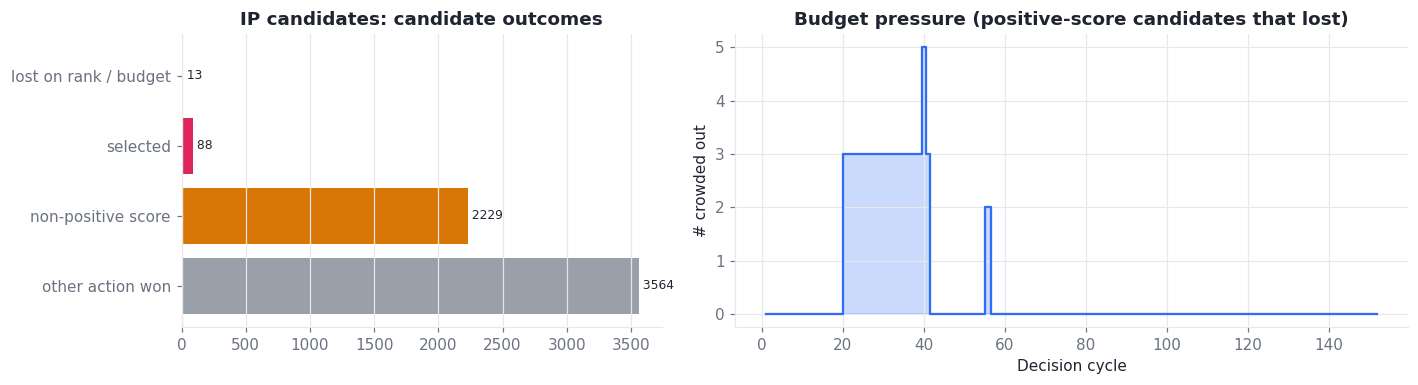

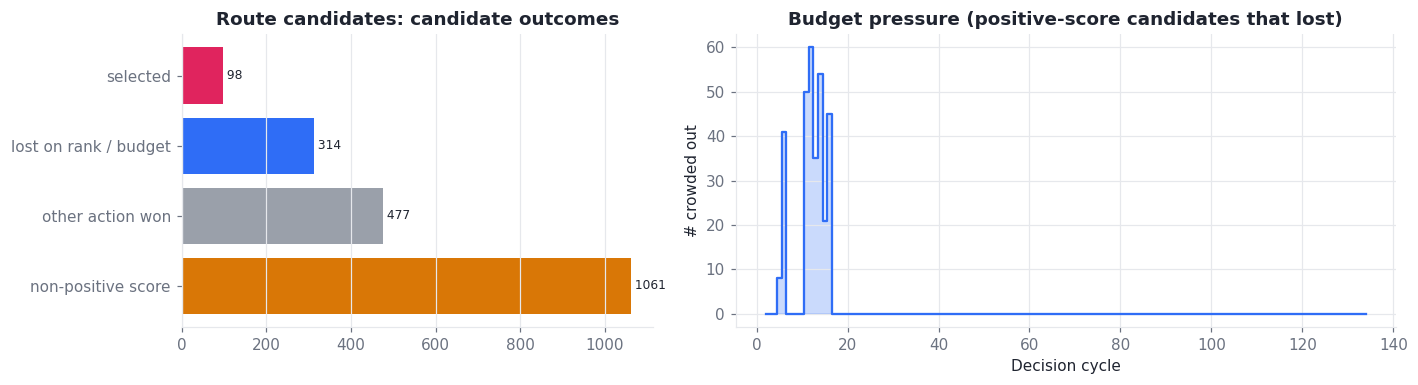

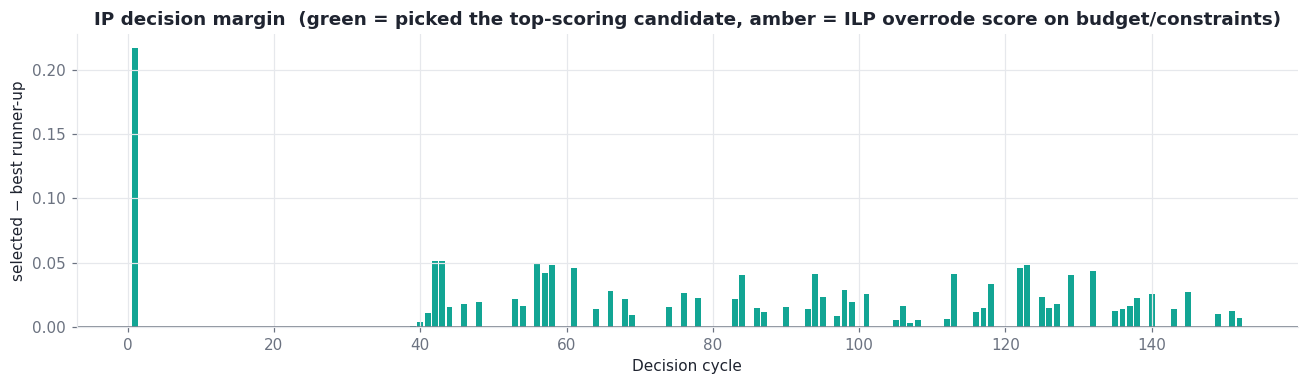

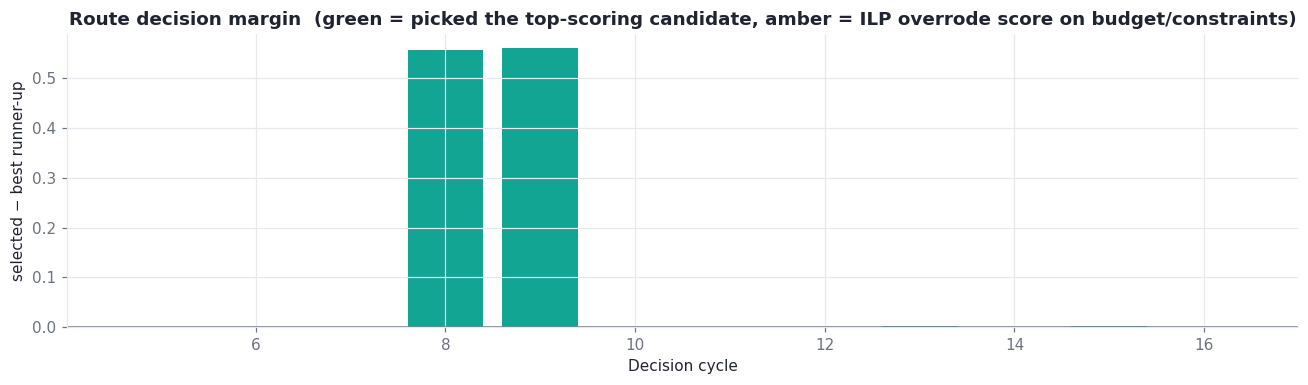

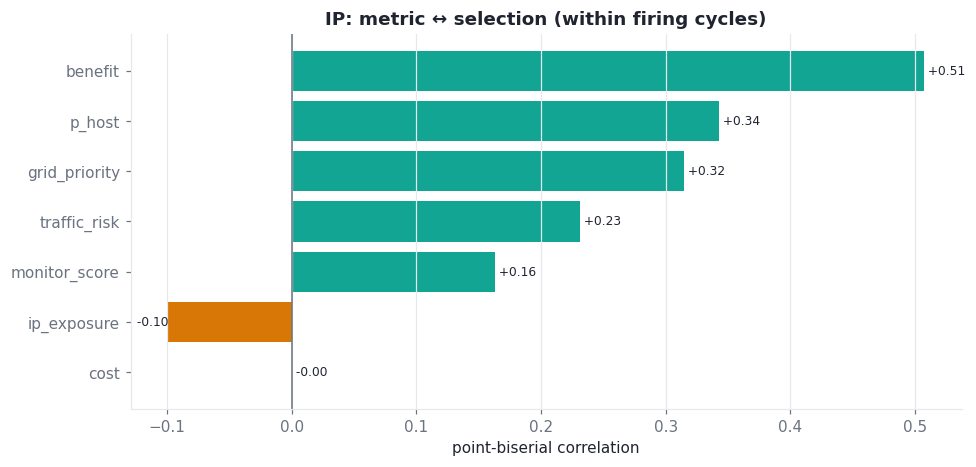

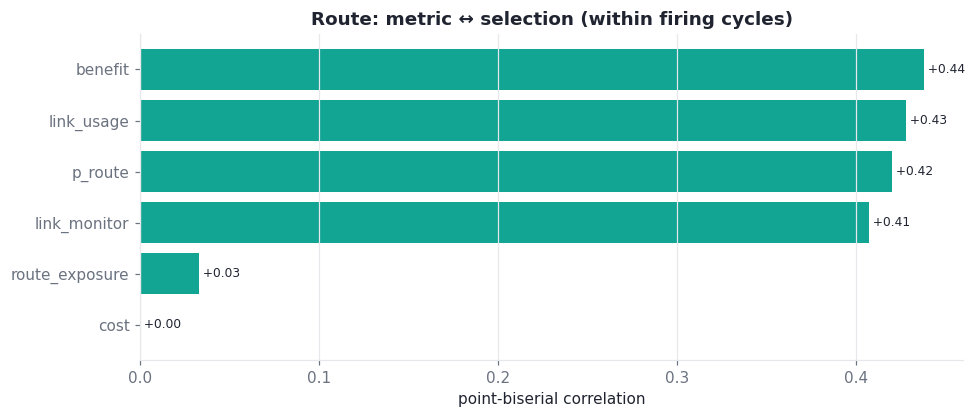

IP host diversity: 20 distinct targets ever chosen across 88 picks | normalised entropy = 0.86  (1.0 = perfectly spread, 0 = always the same)


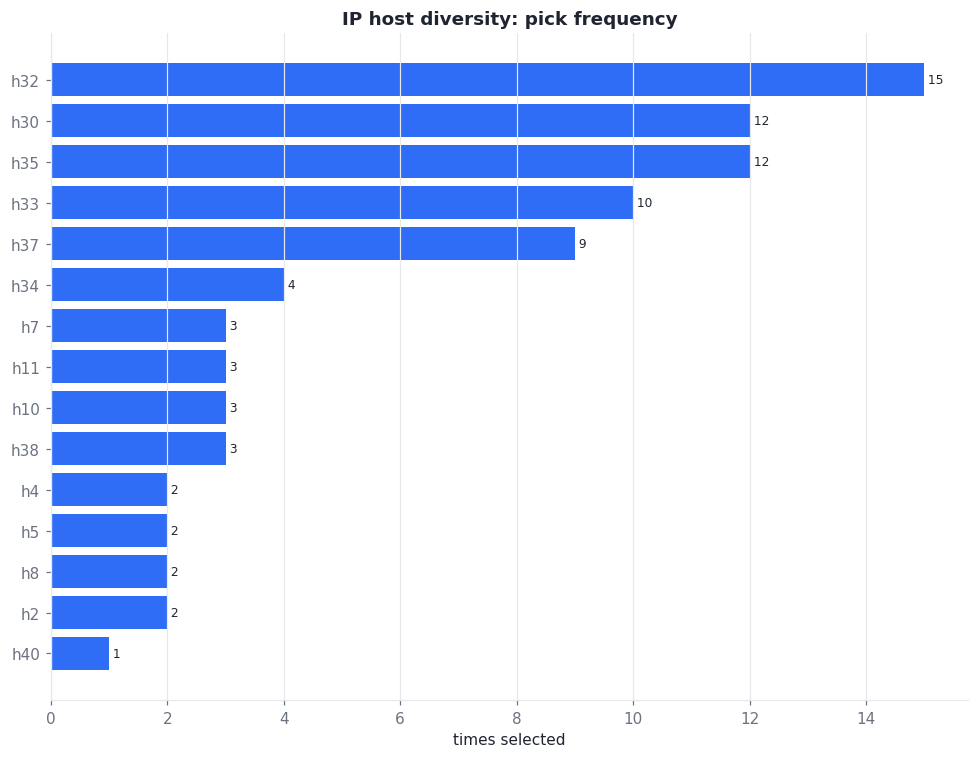

Route diversity: 94 distinct targets ever chosen across 98 picks | normalised entropy = 0.99  (1.0 = perfectly spread, 0 = always the same)


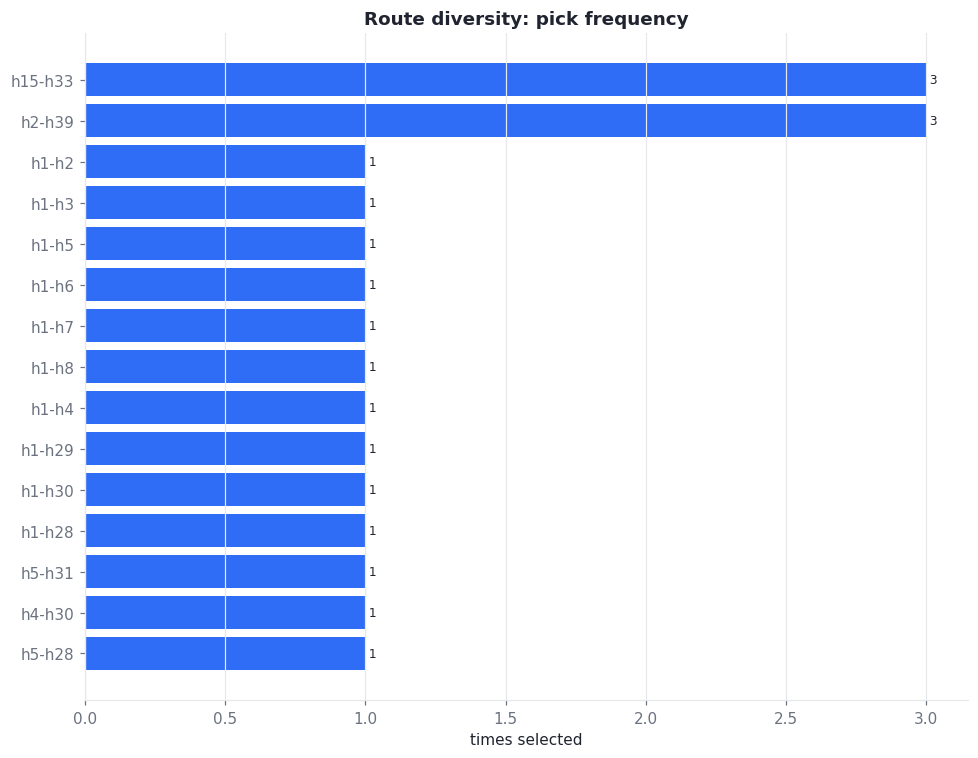


=== ip_importance ===


,metric,mean_selected,mean_unselected,corr_with_selection
0,benefit,0.157022,0.051025,0.507
2,p_host,0.332571,0.114893,0.343
6,grid_priority,0.561869,0.111755,0.315
3,traffic_risk,0.465517,0.204309,0.231
4,monitor_score,0.016849,0.014945,0.163
1,cost,0.141500,0.141500,-0.000
5,ip_exposure,0.712879,0.854297,-0.099



=== ip_margins ===


,cycle_idx,selected,sel_score,runner_up,margin
0,1,h40,0.135485,-0.081209,0.216694
1,39,h3,0.010991,0.009782,0.001209
2,40,h11,0.025092,0.020737,0.004355
3,41,h13,0.038801,0.028100,0.010701
4,42,h5,0.045131,-0.006271,0.051401
5,43,h5,0.045131,-0.006271,0.051401
6,44,h32,0.001792,-0.013783,0.015575
7,46,h30,0.007655,-0.010444,0.018099
8,48,h35,0.001128,-0.018475,0.019603
9,53,h32,0.016925,-0.005149,0.022074


In [14]:
%matplotlib inline
# ================================================================
# Decision-QUALITY diagnostics for the proactive MTD logs.
# Self-contained cell. Turns the raw score logs into:
#   1. why candidates lost  (selection_reason buckets + budget pressure)
#   2. decision margins      (how robust / close each pick was)
#   3. metric importance     (what actually separates winners from losers)
#   4. defense diversity     (entropy of picks across hosts/routes)
# Each function also RETURNS its DataFrame so you can inspect/export.
# ================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:                       # plain-python fallback
    def display(x): print(x.to_string() if hasattr(x, "to_string") else x)

LOG_DIR = Path.cwd() / "proactive_files" / "logger" / "csv_logs"
SELECT_COLOR, OK_COLOR, BAD_COLOR, MUTED = "#e0245e", "#12a594", "#d97706", "#6b7280"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e8ec", "figure.dpi": 110})

IP_METRICS = ["benefit", "cost", "p_host", "traffic_risk", "monitor_score", "ip_exposure", "grid_priority"]
ROUTE_METRICS = ["benefit", "cost", "p_route", "route_exposure", "link_usage", "link_monitor", "hop_count", "latency_penalty"]


def load(name):
    p = LOG_DIR / name
    if not p.exists():
        print(f"[skip] missing {name}")
        return pd.DataFrame()
    return pd.read_csv(p)


def cyc(df):
    if df.empty:
        return df
    df = df.copy()
    if "timestamp" in df:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df = df.sort_values("timestamp")
    if "cycle_id" in df:
        order = {c: i + 1 for i, c in enumerate(df["cycle_id"].dropna().unique())}
        df["cycle_idx"] = df["cycle_id"].map(order)
    else:
        df["cycle_idx"] = np.arange(1, len(df) + 1)
    return df


def numify(df, cols):
    for c in cols:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


# ---------------------------------------------------------------- 1. why candidates lost
def _bucket(reason):
    r = str(reason)
    if r == "selected":
        return "selected"
    if r.endswith("_won"):
        return "other action won"
    if "non_positive" in r:
        return "non-positive score"
    if "rank_or_budget" in r:
        return "lost on rank / budget"
    return "other"


def reason_diagnostics(csv_name, id_col, fired_action, title):
    df = cyc(load(csv_name))
    if df.empty or "selection_reason" not in df:
        print(f"[skip] {title}")
        return pd.DataFrame()
    df["bucket"] = df["selection_reason"].map(_bucket)

    summary = (df["bucket"].value_counts()
               .rename_axis("outcome").reset_index(name="candidate_rows"))
    summary["share"] = (summary["candidate_rows"] / summary["candidate_rows"].sum()).round(3)

    # budget / contention pressure per cycle: positive-score candidates of the
    # firing action that still lost  ->  the ILP budget was binding that cycle
    fired = df[df["action"] == fired_action]
    pressure = (fired.assign(lost_budget=(fired["bucket"] == "lost on rank / budget").astype(int))
                .groupby("cycle_idx")["lost_budget"].sum())

    fig, (axl, axr) = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})
    colors = {"selected": SELECT_COLOR, "other action won": "#9aa0aa",
              "non-positive score": BAD_COLOR, "lost on rank / budget": "#2f6df6", "other": "#c7ccd4"}
    axl.barh(summary["outcome"], summary["candidate_rows"],
             color=[colors.get(o, "#c7ccd4") for o in summary["outcome"]])
    for y, v in enumerate(summary["candidate_rows"]):
        axl.text(v, y, f" {v}", va="center", fontsize=8)
    axl.set_title(f"{title}: candidate outcomes")
    axl.grid(axis="y", visible=False)

    if not pressure.empty:
        axr.fill_between(pressure.index, pressure.values, color="#2f6df6", alpha=0.25, step="mid")
        axr.step(pressure.index, pressure.values, where="mid", color="#2f6df6")
    axr.set_title("Budget pressure (positive-score candidates that lost)")
    axr.set_xlabel("Decision cycle"); axr.set_ylabel("# crowded out")
    plt.tight_layout(); plt.show(); plt.close()
    return summary


# ---------------------------------------------------------------- 2. decision margins
def decision_margins(csv_name, id_col, fired_action, title):
    df = numify(cyc(load(csv_name)), ["score", "selected"])
    if df.empty or not {"score", "selected", "cycle_idx"}.issubset(df.columns):
        print(f"[skip] {title}")
        return pd.DataFrame()

    rows = []
    for c, g in df[df["action"] == fired_action].groupby("cycle_idx"):
        sel = g[g["selected"] == 1]
        if sel.empty:
            continue
        sel_score = sel["score"].max()
        others = g[g["selected"] != 1]["score"]
        best_other = others.max() if not others.empty else np.nan
        rows.append({"cycle_idx": c, "selected": sel.iloc[0][id_col],
                     "sel_score": sel_score, "runner_up": best_other,
                     "margin": sel_score - best_other if pd.notna(best_other) else np.nan})
    out = pd.DataFrame(rows)
    if out.empty:
        print(f"[skip] {title}: no selections")
        return out

    fig, ax = plt.subplots(figsize=(12, 3.6))
    colors = [OK_COLOR if m >= 0 else BAD_COLOR for m in out["margin"].fillna(0)]
    ax.bar(out["cycle_idx"], out["margin"], color=colors)
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_title(f"{title}  (green = picked the top-scoring candidate, "
                 "amber = ILP overrode score on budget/constraints)")
    ax.set_xlabel("Decision cycle"); ax.set_ylabel("selected − best runner-up")
    plt.tight_layout(); plt.show(); plt.close()
    return out


# ---------------------------------------------------------------- 3. metric importance
def metric_importance(csv_name, metrics, fired_action, title):
    df = numify(cyc(load(csv_name)), ["selected"] + metrics)
    if df.empty or "selected" not in df:
        print(f"[skip] {title}")
        return pd.DataFrame()
    d = df[df["action"] == fired_action]
    metrics = [m for m in metrics if m in d.columns and d[m].notna().any()]
    if d.empty or d["selected"].nunique() < 2 or not metrics:
        print(f"[skip] {title}: need both selected and unselected rows")
        return pd.DataFrame()

    rows = []
    for m in metrics:
        s = d[["selected", m]].dropna()
        if s[m].std(ddof=0) == 0:
            corr = 0.0
        else:
            corr = np.corrcoef(s["selected"], s[m])[0, 1]
        rows.append({"metric": m,
                     "mean_selected": d.loc[d.selected == 1, m].mean(),
                     "mean_unselected": d.loc[d.selected == 0, m].mean(),
                     "corr_with_selection": round(float(corr), 3)})
    out = (pd.DataFrame(rows)
           .assign(abs_corr=lambda x: x["corr_with_selection"].abs())
           .sort_values("abs_corr", ascending=True))

    fig, ax = plt.subplots(figsize=(9, 0.45 * len(out) + 1.2))
    colors = [OK_COLOR if v >= 0 else BAD_COLOR for v in out["corr_with_selection"]]
    ax.barh(out["metric"], out["corr_with_selection"], color=colors)
    ax.axvline(0, color=MUTED, lw=1)
    for y, v in zip(range(len(out)), out["corr_with_selection"]):
        ax.text(v, y, f" {v:+.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8)
    ax.set_title(f"{title}: metric ↔ selection (within firing cycles)")
    ax.set_xlabel("point-biserial correlation"); ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show(); plt.close()
    return out.drop(columns="abs_corr").sort_values("corr_with_selection", ascending=False)


# ---------------------------------------------------------------- 4. defense diversity
def selection_diversity(csv_name, id_col, title):
    df = numify(cyc(load(csv_name)), ["selected"])
    if df.empty or "selected" not in df:
        print(f"[skip] {title}")
        return pd.DataFrame()
    picks = df[df["selected"] == 1][id_col].astype(str)
    if picks.empty:
        print(f"[skip] {title}: no picks")
        return pd.DataFrame()

    freq = picks.value_counts()
    p = freq / freq.sum()
    H = float(-(p * np.log(p)).sum())
    Hn = H / np.log(len(freq)) if len(freq) > 1 else 0.0

    print(f"{title}: {len(freq)} distinct targets ever chosen across {len(picks)} picks "
          f"| normalised entropy = {Hn:.2f}  (1.0 = perfectly spread, 0 = always the same)")

    top = freq.head(15)[::-1]
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(top) + 1))
    ax.barh(top.index, top.values, color="#2f6df6")
    for y, v in enumerate(top.values):
        ax.text(v, y, f" {v}", va="center", fontsize=8)
    ax.set_title(f"{title}: pick frequency"); ax.set_xlabel("times selected")
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show(); plt.close()
    return freq.rename_axis(id_col).reset_index(name="times_selected")


# ---------------------------------------------------------------- driver
def run_diagnostics():
    out = {}
    out["ip_reasons"] = reason_diagnostics("ip_score_snapshot.csv", "host", "ip_shuffle", "IP candidates")
    out["route_reasons"] = reason_diagnostics("route_score_snapshot.csv", "pair", "route_mutation", "Route candidates")

    out["ip_margins"] = decision_margins("ip_score_snapshot.csv", "host", "ip_shuffle", "IP decision margin")
    out["route_margins"] = decision_margins("route_score_snapshot.csv", "pair", "route_mutation", "Route decision margin")

    out["ip_importance"] = metric_importance("ip_score_snapshot.csv", IP_METRICS, "ip_shuffle", "IP")
    out["route_importance"] = metric_importance("route_score_snapshot.csv", ROUTE_METRICS, "route_mutation", "Route")

    out["ip_diversity"] = selection_diversity("ip_score_snapshot.csv", "host", "IP host diversity")
    out["route_diversity"] = selection_diversity("route_score_snapshot.csv", "pair", "Route diversity")

    for k in ["ip_importance", "ip_margins"]:
        if not out[k].empty:
            print(f"\n=== {k} ==="); display(out[k])
    return out


diag = run_diagnostics()

In [10]:
# run a DASHBOARD sample


"""
mtd_evaluation.py
=================
Three evaluation views for the proactive MTD system. Run as a script or paste
into a notebook (uses matplotlib; saves PNGs and shows inline if available).

  1. SELECTION     — what the engine chose and why
                     (decision timeline, action mix, decision margin)
  2. DECEPTION     — how well shuffles invalidate attacker recon
                     (IP displacement + distance-to-history, exposure sawtooth,
                      route option churn / path overlap)
  3. EFFECTIVENESS — did it reduce attack impact
                     (bottleneck link load vs THETA/CAPACITY, attack-window
                      shading, time-to-mitigate, multi-run baseline overlay)

WHY SO MANY GUARDS: every plot checks that its columns exist and [SKIP]s if not,
so a missing logger field or an idle run never crashes the batch.

TO ADD A BASELINE (the figure that proves effectiveness):
  Run the same attack at the same cycles with the engine forced to no_mtd,
  logging to a separate folder, then append one line to RUNS below.
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# CONFIG
# =========================================================================

BASE_DIR = Path.cwd()

# History files (current per-entity queues) live at project root.
IP_HISTORY_CSV = BASE_DIR / "ip_history.csv"
ROUTE_HISTORY_CSV = BASE_DIR / "route_history.csv"

# Per-cycle snapshots live in the logger folder.
LOG_DIR = BASE_DIR / "proactive_files" / "logger" / "csv_logs"

# Link thresholds — must match the route ILP (THETA = safety, CAPACITY = saturation).
THETA = 0.8
CAPACITY = 1.0

# Where to save PNGs.
OUT_DIR = BASE_DIR / "proactive_files" / "logger" / "eval_plots"

# -------------------------------------------------------------------------
# RUNS: each entry = (label, snapshot_folder, attack_window)
#   attack_window = None       -> auto-detect (any cycle with bottleneck > THETA)
#                 = (lo, hi)    -> manual cycle range you noted during the run
# Append baselines here once you have them. Same attack, same cycles, engine off.
# -------------------------------------------------------------------------
RUNS = [
    ("Adaptive", LOG_DIR, None),
    # ("No-MTD",     BASE_DIR / "proactive_files" / "logger" / "csv_logs_baseline",  None),
    # ("IP-only",    BASE_DIR / "proactive_files" / "logger" / "csv_logs_iponly",    None),
    # ("Route-only", BASE_DIR / "proactive_files" / "logger" / "csv_logs_routeonly", None),
]


# =========================================================================
# SHARED HELPERS
# =========================================================================

def _load(folder, name):
    p = Path(folder) / name
    if not p.exists():
        print(f"[SKIP] missing {p}")
        return pd.DataFrame()
    try:
        return pd.read_csv(p)
    except Exception as e:
        print(f"[SKIP] could not read {p}: {e}")
        return pd.DataFrame()


def add_cycle_index(df):
    """Map cycle_id (or timestamp order) to a clean 1..N cycle_idx."""
    if df.empty:
        return df
    df = df.copy()
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df = df.sort_values("timestamp")
    if "cycle_id" in df.columns:
        cycles = pd.Series(df["cycle_id"].dropna().unique())
        cmap = {c: i + 1 for i, c in enumerate(cycles)}
        df["cycle_idx"] = df["cycle_id"].map(cmap)
    else:
        df["cycle_idx"] = np.arange(1, len(df) + 1)
    return df


def _save_show(fig, name):
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUT_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=130, bbox_inches="tight")
    print(f"[OK] {path}")
    try:
        plt.show()
    except Exception:
        pass
    plt.close(fig)


def _num(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


# =========================================================================
# 1. SELECTION
# =========================================================================

ACTION_CODE = {"no_mtd": 0, "ip_shuffle": 1, "route_mutation": 2}
ACTION_LABEL = ["No MTD", "IP Shuffle", "Route Mutation"]


def plot_decision_timeline(folder=LOG_DIR):
    df = add_cycle_index(_load(folder, "decision_summary.csv"))
    if df.empty or "action" not in df.columns:
        print("[SKIP] decision timeline")
        return
    df["code"] = df["action"].map(ACTION_CODE).fillna(-1)
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.step(df["cycle_idx"], df["code"], where="mid", marker="o")
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(ACTION_LABEL)
    ax.set_xlabel("Decision cycle"); ax.set_title("MTD decision timeline")
    ax.grid(True, alpha=0.3)
    _save_show(fig, "selection_timeline")


def plot_action_mix(folder=LOG_DIR):
    df = _load(folder, "decision_summary.csv")
    if df.empty or "action" not in df.columns:
        print("[SKIP] action mix")
        return
    counts = df["action"].value_counts()
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.barh(counts.index, counts.values)
    ax.set_xlabel("Cycles"); ax.set_title("Action distribution")
    for i, v in enumerate(counts.values):
        ax.text(v, i, f" {v}", va="center")
    _save_show(fig, "selection_action_mix")


def plot_decision_margin(folder=LOG_DIR):
    """Per cycle: (lowest selected score) - (highest rejected score) in the
    winning mode. Positive = clean separation; near zero = the call was close."""
    ipc = add_cycle_index(_load(folder, "ip_score_snapshot.csv"))
    rtc = add_cycle_index(_load(folder, "route_score_snapshot.csv"))
    if ipc.empty and rtc.empty:
        print("[SKIP] decision margin")
        return
    for d in (ipc, rtc):
        if not d.empty:
            _num(d, ["score", "selected"])
            d["selected"] = d["selected"].fillna(0)

    rows = []
    cycles = sorted(set(ipc.get("cycle_idx", pd.Series(dtype=int))).union(
                    set(rtc.get("cycle_idx", pd.Series(dtype=int)))))
    for cyc in cycles:
        for src, mode in ((ipc, "ip_shuffle"), (rtc, "route_mutation")):
            if src.empty:
                continue
            g = src[src["cycle_idx"] == cyc]
            if g.empty or g["selected"].sum() == 0:
                continue
            sel = g[g["selected"] == 1]["score"]
            rej = g[g["selected"] == 0]["score"]
            margin = sel.min() - (rej.max() if not rej.empty else sel.min())
            rows.append({"cycle_idx": cyc, "mode": mode, "margin": margin})
    if not rows:
        print("[SKIP] decision margin (no selections)")
        return
    m = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(12, 3.6))
    for mode, sub in m.groupby("mode"):
        ax.plot(sub["cycle_idx"], sub["margin"], marker="o", label=mode)
    ax.axhline(0, color="#888", lw=0.8)
    ax.set_xlabel("Decision cycle")
    ax.set_ylabel("selected_min − rejected_max")
    ax.set_title("Decision margin (how decisive each selection was)")
    ax.grid(True, alpha=0.3); ax.legend()
    _save_show(fig, "selection_margin")


# =========================================================================
# 2. DECEPTION
# =========================================================================

def _parse_hist(s):
    return [x.strip() for x in str(s).split(",") if x.strip() != ""]


def plot_ip_displacement(path=IP_HISTORY_CSV, max_hosts=8):
    """For hosts that actually shuffled: IP octet trajectory + jump sizes.
    Large, non-repeating jumps = strong deception."""
    df = _load(path.parent, path.name)
    if df.empty or "history" not in df.columns:
        print("[SKIP] IP displacement")
        return

    shuffled = []
    for _, r in df.iterrows():
        vals = [int(x) for x in _parse_hist(r["history"]) if x.lstrip("-").isdigit()]
        if len(set(vals)) > 1:                       # changed at least once
            shuffled.append((r["host"], vals))
    if not shuffled:
        print("[SKIP] IP displacement (no host shuffled in history window)")
        return
    # rank by total movement, keep the most active
    shuffled.sort(key=lambda hv: sum(abs(np.diff(hv[1]))), reverse=True)
    shuffled = shuffled[:max_hosts]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.4))

    # left: octet trajectory (step)
    for host, vals in shuffled:
        ax1.step(range(len(vals)), vals, where="post", marker="o", label=host)
    ax1.set_xlabel("History index (oldest → newest)")
    ax1.set_ylabel("Assigned IP octet (10.0.0.X)")
    ax1.set_title("IP trajectory of shuffled hosts")
    ax1.grid(True, alpha=0.3); ax1.legend(fontsize=8, ncol=2)

    # right: jump size + distance-to-prior-history at each shuffle
    for host, vals in shuffled:
        jumps_x, jumps_y, dist_y = [], [], []
        seen = {vals[0]}
        for i in range(1, len(vals)):
            if vals[i] != vals[i - 1]:
                jumps_x.append(i)
                jumps_y.append(abs(vals[i] - vals[i - 1]))
                dist_y.append(min(abs(vals[i] - s) for s in seen))
            seen.add(vals[i])
        if jumps_x:
            ax2.scatter(jumps_y, dist_y, s=60, label=host)
    ax2.set_xlabel("Jump size  |new − previous|")
    ax2.set_ylabel("Distance to nearest prior IP")
    ax2.set_title("Per-shuffle deception quality (upper-right = best)")
    ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8, ncol=2)

    _save_show(fig, "deception_ip_displacement")


def plot_exposure_sawtooth(folder=LOG_DIR, top_n=8):
    """ip_exposure / route_exposure over cycles. Healthy deception resets often;
    flat-at-1.0 = the identity sat still and was a stable target."""
    ipc = add_cycle_index(_load(folder, "ip_score_snapshot.csv"))
    rtc = add_cycle_index(_load(folder, "route_score_snapshot.csv"))

    panels = []
    if not ipc.empty and {"host", "ip_exposure", "cycle_idx"}.issubset(ipc.columns):
        panels.append(("host", "ip_exposure", ipc, "IP exposure"))
    if not rtc.empty and {"pair", "route_exposure", "cycle_idx"}.issubset(rtc.columns):
        panels.append(("pair", "route_exposure", rtc, "Route exposure"))
    if not panels:
        print("[SKIP] exposure sawtooth")
        return

    fig, axes = plt.subplots(len(panels), 1, figsize=(12, 3.4 * len(panels)),
                             squeeze=False)
    for ax, (idc, val, d, title) in zip(axes[:, 0], panels):
        _num(d, [val, "selected"])
        # pick the entities with the most exposure variation (most interesting)
        var = d.groupby(idc)[val].std().fillna(0).sort_values(ascending=False)
        keep = var.head(top_n).index
        for ent in keep:
            sub = d[d[idc] == ent].sort_values("cycle_idx")
            ax.plot(sub["cycle_idx"], sub[val], marker=".", label=str(ent))
            if "selected" in sub.columns:
                chosen = sub[sub["selected"] == 1]
                ax.scatter(chosen["cycle_idx"], chosen[val], s=90, marker="*",
                           zorder=5)
        ax.set_ylabel(val); ax.set_title(f"{title} over cycles  (★ = shuffled)")
        ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, ncol=2)
    axes[-1, 0].set_xlabel("Decision cycle")
    _save_show(fig, "deception_exposure_sawtooth")


def plot_route_churn(path=ROUTE_HISTORY_CSV):
    """How many distinct route options each pair has actually used (option != 0
    means a mutation happened). Flat at 0 = routes never moved."""
    df = _load(path.parent, path.name)
    if df.empty or "history" not in df.columns:
        print("[SKIP] route churn")
        return
    rows = []
    for _, r in df.iterrows():
        vals = [int(x) for x in _parse_hist(r["history"]) if x.lstrip("-").isdigit()]
        changes = sum(1 for i in range(1, len(vals)) if vals[i] != vals[i - 1])
        distinct_nonzero = len({v for v in vals if v != 0})
        rows.append({"pair": f"{r['host_a']}-{r['host_b']}",
                     "changes": changes, "distinct_options": distinct_nonzero})
    m = pd.DataFrame(rows)
    active = m[(m["changes"] > 0) | (m["distinct_options"] > 0)]
    if active.empty:
        print("[INFO] route churn: no route mutations recorded in history window "
              "(all pairs on default option 0).")
        return
    active = active.sort_values("changes", ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(12, 0.4 * len(active) + 1.5))
    ax.barh(active["pair"], active["changes"])
    ax.set_xlabel("Number of route changes")
    ax.set_title("Route mutation churn per pair")
    ax.invert_yaxis()
    _save_show(fig, "deception_route_churn")


# =========================================================================
# 3. EFFECTIVENESS
# =========================================================================

def _bottleneck_series(folder):
    """Per-cycle max link load (the bottleneck) + which link carried it."""
    df = add_cycle_index(_load(folder, "link_snapshot.csv"))
    if df.empty:
        return pd.DataFrame()
    col = "link_mbps" if "link_mbps" in df.columns else None
    if col is None:  # fall back to max(rx,tx)
        _num(df, ["rx_mbps", "tx_mbps"])
        df["link_mbps"] = df[["rx_mbps", "tx_mbps"]].max(axis=1)
        col = "link_mbps"
    _num(df, [col])
    idx = df.groupby("cycle_idx")[col].idxmax()
    out = df.loc[idx, ["cycle_idx", "link_id", col]].rename(
        columns={col: "bottleneck"}).reset_index(drop=True)
    return out.sort_values("cycle_idx")


def _attack_window(bs, manual):
    if manual is not None:
        return manual
    hot = bs[bs["bottleneck"] > THETA]["cycle_idx"]
    if hot.empty:
        return None
    return int(hot.min()), int(hot.max())


def _time_to_mitigate(bs, window):
    """Cycles from attack start until bottleneck first falls back under THETA."""
    if window is None:
        return None
    lo, _ = window
    after = bs[(bs["cycle_idx"] >= lo) & (bs["bottleneck"] <= THETA)]
    if after.empty:
        return None
    return int(after["cycle_idx"].min() - lo)


def plot_effectiveness(runs=RUNS):
    series = []
    for label, folder, manual in runs:
        bs = _bottleneck_series(folder)
        if bs.empty:
            print(f"[SKIP] effectiveness: no link_snapshot for '{label}'")
            continue
        win = _attack_window(bs, manual)
        ttm = _time_to_mitigate(bs, win)
        series.append((label, bs, win, ttm))
    if not series:
        print("[SKIP] effectiveness (no runs with data)")
        return

    fig, ax = plt.subplots(figsize=(12, 4.6))
    # shade the union of attack windows (usually identical across runs)
    for label, bs, win, ttm in series:
        if win:
            ax.axvspan(win[0], win[1], color="#d9534f", alpha=0.08)
    for label, bs, win, ttm in series:
        tag = f"{label}" + (f"  (TTM={ttm} cyc)" if ttm is not None else "")
        ax.plot(bs["cycle_idx"], bs["bottleneck"], marker=".", label=tag)

    ax.axhline(THETA, color="#e69500", ls="--", lw=1.2,
               label=f"THETA safety = {THETA}")
    ax.axhline(CAPACITY, color="#c0392b", ls=":", lw=1.2,
               label=f"CAPACITY = {CAPACITY}")
    ax.set_xlabel("Decision cycle")
    ax.set_ylabel("Bottleneck link load (Mbps)")
    ax.set_title("Effectiveness — peak link load vs safety threshold")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    _save_show(fig, "effectiveness_bottleneck")

    # console summary table
    print("\n=== Effectiveness summary ===")
    print(f"{'Run':<12}{'Peak load':>10}{'Attack window':>18}{'Time-to-mitigate':>18}")
    for label, bs, win, ttm in series:
        peak = bs["bottleneck"].max()
        w = f"{win[0]}–{win[1]}" if win else "none>THETA"
        t = f"{ttm} cyc" if ttm is not None else "—"
        print(f"{label:<12}{peak:>10.3f}{w:>18}{t:>18}")
    print("Add a No-MTD run to RUNS for the causal comparison.\n")


# =========================================================================
# RUN ALL
# =========================================================================

def run_all():
    print("\n----- SELECTION -----")
    plot_decision_timeline()
    plot_action_mix()
    plot_decision_margin()

    print("\n----- DECEPTION -----")
    plot_ip_displacement()
    plot_exposure_sawtooth()
    plot_route_churn()

    print("\n----- EFFECTIVENESS -----")
    plot_effectiveness()


run_all()


----- SELECTION -----
[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/selection_timeline.png
[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/selection_action_mix.png


/tmp/ipykernel_26090/2566741237.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/selection_margin.png

----- DECEPTION -----
[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/deception_ip_displacement.png


/tmp/ipykernel_26090/2566741237.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_26090/2566741237.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/deception_exposure_sawtooth.png
[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/deception_route_churn.png

----- EFFECTIVENESS -----


/tmp/ipykernel_26090/2566741237.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_26090/2566741237.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[OK] /home/vboxuser/Downloads/v2/data_collection_codes_/Final_Main_for_Paper/proactive_files/logger/eval_plots/effectiveness_bottleneck.png

=== Effectiveness summary ===
Run          Peak load     Attack window  Time-to-mitigate
Adaptive         1.621           104–320             1 cyc
Add a No-MTD run to RUNS for the causal comparison.



/tmp/ipykernel_26090/2566741237.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## flow generation

### active flow and overlap counter

In [7]:
# capture flow experiment

import requests
import pandas as pd
from collections import defaultdict

# =====================================================
# CONFIG: CHANGE THESE
# =====================================================
ONOS_IP = "127.0.0.1"     # change if ONOS is elsewhere, e.g. "192.168.56.101"
ONOS_PORT = 8181
ONOS_USER = "onos"
ONOS_PASS = "rocks"

BASE = f"http://{ONOS_IP}:{ONOS_PORT}/onos/v1"

# Optional readable names.
# Adjust these based on your ONOS device IDs.
DEVICE_NAMES = {
    "of:0000000000000001": "s1",
    "of:0000000000000002": "s2",
    "of:0000000000000003": "s3",
    "of:0000000000000004": "s4",
    "of:0000000000000005": "s5",
    "of:0000000000000006": "s6",
    "of:0000000000000007": "s7",
    "of:0000000000000008": "s8",
    "of:0000000000000009": "s9",
    "of:000000000000000a": "s10",
    "of:000000000000000b": "s11",
    "of:000000000000000c": "s12",
    "of:000000000000000d": "s13",
}

NAME_TO_DEVICE = {v: k for k, v in DEVICE_NAMES.items()}

def resolve_dev(x):
    """
    Allows ROUTE_CANDIDATES to use either:
    - ONOS IDs: of:0000000000000002
    - readable names: s2
    """
    return NAME_TO_DEVICE.get(x, x)

# Your real route candidates.
# You can use either readable names or ONOS device IDs.
ROUTE_CANDIDATES = {
    "h15_to_h39_route_1": [
        ("s3", "s11"),
        ("s11", "s13"),
        ("s13", "s7"),
    ],
    "h2_to_h39_route_2": [
        ("s2", "s8"),
        ("s8", "s11"),
        ("s11", "s13"),
        ("s13", "s7"),
    ],
}

# =====================================================
# HELPERS
# =====================================================
def dev_name(dev):
    return DEVICE_NAMES.get(dev, dev)


def onos_get(path):
    url = f"{BASE}{path}"
    r = requests.get(url, auth=(ONOS_USER, ONOS_PASS), timeout=10)
    r.raise_for_status()
    return r.json()


def get_output_ports(flow):
    ports = []

    treatment = flow.get("treatment", {})
    instructions = treatment.get("instructions", [])

    for inst in instructions:
        if inst.get("type") == "OUTPUT":
            port = inst.get("port")
            if port is not None:
                ports.append(str(port))

    return ports


def get_all_flows():
    """
    Pull flows per device. This is more reliable than assuming /flows returns all flows.
    """
    devices = onos_get("/devices").get("devices", [])
    all_flows = []

    for dev in devices:
        dev_id = dev["id"]

        try:
            data = onos_get(f"/flows/{dev_id}")
            dev_flows = data.get("flows", [])

            for f in dev_flows:
                f["deviceId"] = f.get("deviceId", dev_id)

            all_flows.extend(dev_flows)

        except Exception as e:
            print(f"Could not read flows for {dev_id}: {e}")

    return all_flows


# =====================================================
# 1. PULL REAL ONOS LINKS
# =====================================================
links = onos_get("/links").get("links", [])

pair_to_link = {}

for link in links:
    src_dev = link["src"]["device"]
    src_port = str(link["src"]["port"])
    dst_dev = link["dst"]["device"]
    dst_port = str(link["dst"]["port"])

    pair_to_link[(src_dev, dst_dev)] = {
        "src_device": src_dev,
        "src_port": src_port,
        "dst_device": dst_dev,
        "dst_port": dst_port,
        "link_id": f"{src_dev}/{src_port}->{dst_dev}/{dst_port}",
        "readable_link": f"{dev_name(src_dev)}:{src_port} -> {dev_name(dst_dev)}:{dst_port}",
    }

print(f"Loaded {len(pair_to_link)} directed ONOS links.")


# =====================================================
# 2. PULL REAL ONOS FLOWS
# =====================================================
flows = get_all_flows()
print(f"Loaded {len(flows)} ONOS flow rules.")


# =====================================================
# 3. FILTER FLOWS
# =====================================================
ONLY_ADDED = True
APP_FILTER_KEYWORDS = ["fwd"]   # use [] to disable app filtering
IGNORE_ZERO_PACKET_FLOWS = False

filtered_flows = []

for flow in flows:
    state = str(flow.get("state", "")).upper()
    app_id = str(flow.get("appId", "")).lower()
    packets = int(flow.get("packets", 0))

    if ONLY_ADDED and state != "ADDED":
        continue

    if APP_FILTER_KEYWORDS and not any(k.lower() in app_id for k in APP_FILTER_KEYWORDS):
        continue

    if IGNORE_ZERO_PACKET_FLOWS and packets <= 0:
        continue

    filtered_flows.append(flow)

print(f"Using {len(filtered_flows)} filtered flows out of {len(flows)} total flows.")


# =====================================================
# 4. OPTIONAL: ONOS HOST MAC MAP
# =====================================================
try:
    hosts = onos_get("/hosts").get("hosts", [])
except Exception as e:
    print(f"Could not read hosts: {e}")
    hosts = []

ip_to_mac = {}
mac_to_host = {}

for h in hosts:
    mac = h.get("mac")

    if mac:
        mac_to_host[mac] = h

    for ip in h.get("ipAddresses", []):
        ip_to_mac[str(ip)] = mac

print(f"Loaded {len(hosts)} ONOS hosts and {len(ip_to_mac)} IP-to-MAC mappings.")


# =====================================================
# 5. BUILD LINK -> FLOW IDS MAP
# =====================================================
link_flow_ids = defaultdict(set)
link_flow_details = defaultdict(list)

for flow in filtered_flows:
    device_id = flow.get("deviceId")
    flow_id = str(flow.get("id"))
    packets = int(flow.get("packets", 0))
    bytes_ = int(flow.get("bytes", 0))
    priority = flow.get("priority", None)
    state = flow.get("state", "")
    app_id = flow.get("appId", "")

    out_ports = get_output_ports(flow)

    for (src_dev, dst_dev), link_info in pair_to_link.items():
        if device_id == src_dev and link_info["src_port"] in out_ports:
            link_id = link_info["link_id"]

            link_flow_ids[link_id].add(flow_id)
            link_flow_details[link_id].append({
                "flow_id": flow_id,
                "device": device_id,
                "out_port": link_info["src_port"],
                "dst_device": dst_dev,
                "packets": packets,
                "bytes": bytes_,
                "priority": priority,
                "state": state,
                "app_id": app_id,
                "readable_link": link_info["readable_link"],
            })


# =====================================================
# 6. LINK-LEVEL SUMMARY
# =====================================================
link_rows = []

for (src_dev, dst_dev), link_info in pair_to_link.items():
    link_id = link_info["link_id"]
    details = link_flow_details.get(link_id, [])
    flow_ids = sorted(link_flow_ids.get(link_id, set()))

    link_rows.append({
        "src": dev_name(src_dev),
        "dst": dev_name(dst_dev),
        "src_device": src_dev,
        "dst_device": dst_dev,
        "src_port": link_info["src_port"],
        "dst_port": link_info["dst_port"],
        "link_id": link_id,
        "link": link_info["readable_link"],
        "flow_count": len(flow_ids),
        "flow_ids": ";".join(flow_ids),
        "total_packets": sum(x["packets"] for x in details),
        "total_bytes": sum(x["bytes"] for x in details),
    })

df_links = pd.DataFrame(link_rows).sort_values(
    by=["flow_count", "total_bytes"],
    ascending=False
)


# =====================================================
# 7. ROUTE-CANDIDATE SUMMARY
# =====================================================
route_rows = []
route_link_rows = []

for route_name, route_pairs in ROUTE_CANDIDATES.items():
    unique_route_flows = set()
    route_flow_appearances = 0
    missing_links = []

    for src_raw, dst_raw in route_pairs:
        src_dev = resolve_dev(src_raw)
        dst_dev = resolve_dev(dst_raw)

        link_info = pair_to_link.get((src_dev, dst_dev))

        if link_info is None:
            missing_links.append(f"{src_raw}->{dst_raw}")
            continue

        link_id = link_info["link_id"]
        flow_ids = set(link_flow_ids.get(link_id, set()))
        details = link_flow_details.get(link_id, [])

        unique_route_flows.update(flow_ids)
        route_flow_appearances += len(flow_ids)

        route_link_rows.append({
            "route": route_name,
            "link": link_info["readable_link"],
            "src": dev_name(src_dev),
            "dst": dev_name(dst_dev),
            "flow_count_on_this_link": len(flow_ids),
            "flow_ids_on_this_link": ";".join(sorted(flow_ids)),
            "total_packets_on_link": sum(x["packets"] for x in details),
            "total_bytes_on_link": sum(x["bytes"] for x in details),
        })

    route_rows.append({
        "route": route_name,
        "num_links": len(route_pairs),
        "unique_flow_count": len(unique_route_flows),
        "route_flow_appearances": route_flow_appearances,
        "unique_flow_ids": ";".join(sorted(unique_route_flows)),
        "missing_links": "; ".join(missing_links),
    })

df_routes = pd.DataFrame(route_rows).sort_values(
    by=["unique_flow_count", "route_flow_appearances"],
    ascending=False
)

df_route_links = pd.DataFrame(route_link_rows)


# =====================================================
# 8. DISPLAY RESULTS
# =====================================================
print("\n=== All ONOS Links: Flow Count Per Link ===")
display(df_links)

print("\n=== Route Candidate Summary ===")
display(df_routes)

print("\n=== Per-Link Counts Inside Each Route Candidate ===")
display(df_route_links)
# =====================================================
# FLOW -> MAX ROUTE OVERLAP COUNT
# =====================================================

def clean_ip(ip):
    if ip is None:
        return None
    return str(ip).replace("/32", "")


def extract_flow_fields(flow):
    fields = {
        "eth_src": None,
        "eth_dst": None,
        "ipv4_src": None,
        "ipv4_dst": None,
        "tcp_src": None,
        "tcp_dst": None,
        "udp_src": None,
        "udp_dst": None,
    }

    criteria = flow.get("selector", {}).get("criteria", [])

    for c in criteria:
        ctype = c.get("type")

        if ctype == "ETH_SRC":
            fields["eth_src"] = c.get("mac")
        elif ctype == "ETH_DST":
            fields["eth_dst"] = c.get("mac")
        elif ctype == "IPV4_SRC":
            fields["ipv4_src"] = clean_ip(c.get("ip"))
        elif ctype == "IPV4_DST":
            fields["ipv4_dst"] = clean_ip(c.get("ip"))
        elif ctype == "TCP_SRC":
            fields["tcp_src"] = c.get("tcpPort")
        elif ctype == "TCP_DST":
            fields["tcp_dst"] = c.get("tcpPort")
        elif ctype == "UDP_SRC":
            fields["udp_src"] = c.get("udpPort")
        elif ctype == "UDP_DST":
            fields["udp_dst"] = c.get("udpPort")

    return fields


def get_flow_signature(flow):
    """
    Approximate end-to-end flow identity.
    Prefer IP/MAC/port fields instead of ONOS flow_id,
    because ONOS flow_id is per switch.
    """
    f = extract_flow_fields(flow)

    parts = []

    for key in [
        "eth_src", "eth_dst",
        "ipv4_src", "ipv4_dst",
        "tcp_src", "tcp_dst",
        "udp_src", "udp_dst",
    ]:
        if f[key] is not None:
            parts.append(f"{key}={f[key]}")

    if not parts:
        return None

    return "|".join(parts)


# # -----------------------------------------------------
# # 1. Build link -> flow signatures map
# # -----------------------------------------------------
# link_flow_sigs = defaultdict(set)
# sig_details = {}

# for flow in filtered_flows if "filtered_flows" in globals() else flows:
#     device_id = flow.get("deviceId")
#     flow_id = str(flow.get("id"))
#     sig = get_flow_signature(flow)

#     if sig is None:
#         continue

#     fields = extract_flow_fields(flow)
#     out_ports = get_output_ports(flow)

#     sig_details.setdefault(sig, {
#         "flow_signature": sig,
#         "src_ip": fields["ipv4_src"],
#         "dst_ip": fields["ipv4_dst"],
#         "src_mac": fields["eth_src"],
#         "dst_mac": fields["eth_dst"],
#         "example_flow_ids": set(),
#     })

#     sig_details[sig]["example_flow_ids"].add(flow_id)

#     for (src_dev, dst_dev), link_info in pair_to_link.items():
#         if device_id == src_dev and link_info["src_port"] in out_ports:
#             link_id = link_info["link_id"]
#             link_flow_sigs[link_id].add(sig)


# # -----------------------------------------------------
# # 2. Build route -> flow signatures map
# # -----------------------------------------------------
# route_to_sigs = {}

# for route_name, route_pairs in ROUTE_CANDIDATES.items():
#     sigs_on_route = set()

#     for src_dev, dst_dev in route_pairs:
#         link_info = pair_to_link.get((src_dev, dst_dev))

#         if link_info is None:
#             continue

#         link_id = link_info["link_id"]
#         sigs_on_route.update(link_flow_sigs.get(link_id, set()))

#     route_to_sigs[route_name] = sigs_on_route


# # -----------------------------------------------------
# # 3. For each flow, count how many routes it overlaps
# # -----------------------------------------------------
# flow_overlap_rows = []

# all_sigs = set()
# for sigs in route_to_sigs.values():
#     all_sigs.update(sigs)

# print("Total signatures found on route candidates:", len(all_sigs))

# for sig in all_sigs:
#     routes_seen = []

#     for route_name, route_sigs in route_to_sigs.items():
#         if sig in route_sigs:
#             routes_seen.append(route_name)

#     d = sig_details.get(sig, {})

#     flow_overlap_rows.append({
#         "flow_signature": sig,
#         "overlap_count": len(routes_seen),
#         "routes_seen": ";".join(routes_seen),
#         "src_ip": d.get("src_ip"),
#         "dst_ip": d.get("dst_ip"),
#         "src_mac": d.get("src_mac"),
#         "dst_mac": d.get("dst_mac"),
#         "example_flow_ids": ";".join(sorted(d.get("example_flow_ids", []))),
#     })

# if flow_overlap_rows:
#     df_flow_overlap_count = pd.DataFrame(flow_overlap_rows).sort_values(
#         by="overlap_count",
#         ascending=False
#     )
# else:
#     df_flow_overlap_count = pd.DataFrame(columns=[
#         "flow_signature",
#         "overlap_count",
#         "routes_seen",
#         "src_ip",
#         "dst_ip",
#         "src_mac",
#         "dst_mac",
#         "example_flow_ids",
#     ])

# print("\n=== Flow Overlap Count Across Route Candidates ===")
# display(df_flow_overlap_count)

# # -----------------------------------------------------
# # 4. Pick max-overlap flow(s)
# # -----------------------------------------------------
# if not df_flow_overlap_count.empty:
#     max_overlap = df_flow_overlap_count["overlap_count"].max()
#     df_max_overlap_flows = df_flow_overlap_count[
#         df_flow_overlap_count["overlap_count"] == max_overlap
#     ]

#     print(f"\nMax overlap count = {max_overlap}")
#     print("Flow(s) with highest overlap:")

#     display(df_max_overlap_flows)

#     for _, row in df_max_overlap_flows.iterrows():
#         print(
#             f"Flow {row['flow_signature']} has overlap count {row['overlap_count']} "
#             f"across routes: {row['routes_seen']}"
#         )
# else:
#     print("No flow signatures found on the candidate route links.")


from collections import defaultdict
import pandas as pd

# =====================================================
# ACTIVE FLOW ROUTE OVERLAP BY MAC-MAC PAIR
# =====================================================

def clean_ip(ip):
    if ip is None:
        return None
    return str(ip).replace("/32", "").replace("/24", "")


def norm_mac(mac):
    if mac is None:
        return None
    return str(mac).lower()


def extract_flow_fields(flow):
    fields = {
        "eth_src": None,
        "eth_dst": None,
        "ipv4_src": None,
        "ipv4_dst": None,
        "tcp_src": None,
        "tcp_dst": None,
        "udp_src": None,
        "udp_dst": None,
    }

    criteria = flow.get("selector", {}).get("criteria", [])

    for c in criteria:
        ctype = c.get("type")

        if ctype == "ETH_SRC":
            fields["eth_src"] = norm_mac(c.get("mac"))
        elif ctype == "ETH_DST":
            fields["eth_dst"] = norm_mac(c.get("mac"))
        elif ctype == "IPV4_SRC":
            fields["ipv4_src"] = clean_ip(c.get("ip"))
        elif ctype == "IPV4_DST":
            fields["ipv4_dst"] = clean_ip(c.get("ip"))
        elif ctype == "TCP_SRC":
            fields["tcp_src"] = c.get("tcpPort")
        elif ctype == "TCP_DST":
            fields["tcp_dst"] = c.get("tcpPort")
        elif ctype == "UDP_SRC":
            fields["udp_src"] = c.get("udpPort")
        elif ctype == "UDP_DST":
            fields["udp_dst"] = c.get("udpPort")

    return fields


# Manual host maps from your topology
HOST_IP_MAC = {
    f"10.0.0.{i}": f"00:00:00:00:00:{i:02x}"
    for i in range(1, 41)
}

HOST_IP_NAME = {
    f"10.0.0.{i}": f"h{i}"
    for i in range(1, 41)
}

HOST_MAC_NAME = {
    mac: HOST_IP_NAME[ip]
    for ip, mac in HOST_IP_MAC.items()
}


def complete_mac_fields(fields):
    """
    If ONOS selector has IP but not MAC, recover MAC from known host map.
    """
    if fields["eth_src"] is None and fields["ipv4_src"] is not None:
        fields["eth_src"] = HOST_IP_MAC.get(fields["ipv4_src"])

    if fields["eth_dst"] is None and fields["ipv4_dst"] is not None:
        fields["eth_dst"] = HOST_IP_MAC.get(fields["ipv4_dst"])

    return fields


def get_mac_pair_key(fields):
    src_mac = fields.get("eth_src")
    dst_mac = fields.get("eth_dst")

    if src_mac is None or dst_mac is None:
        return None

    return (src_mac, dst_mac)


def get_host_name_from_mac(mac):
    return HOST_MAC_NAME.get(norm_mac(mac), norm_mac(mac))


# =====================================================
# 1. Build MAC-MAC flow route footprint
# =====================================================
macpair_to_links = defaultdict(set)
macpair_to_flow_ids = defaultdict(set)
macpair_to_devices = defaultdict(set)
macpair_to_packets = defaultdict(int)
macpair_to_bytes = defaultdict(int)
macpair_to_ips = {}

unmapped_flows = []

for flow in filtered_flows:
    device_id = flow.get("deviceId")
    flow_id = str(flow.get("id"))
    packets = int(flow.get("packets", 0))
    bytes_ = int(flow.get("bytes", 0))

    fields = extract_flow_fields(flow)
    fields = complete_mac_fields(fields)

    mac_pair = get_mac_pair_key(fields)

    if mac_pair is None:
        unmapped_flows.append({
            "flow_id": flow_id,
            "device": dev_name(device_id),
            "selector": flow.get("selector", {}).get("criteria", []),
            "out_ports": get_output_ports(flow),
        })
        continue

    out_ports = get_output_ports(flow)

    for (src_dev, dst_dev), link_info in pair_to_link.items():
        if device_id == src_dev and link_info["src_port"] in out_ports:
            link_id = link_info["link_id"]

            macpair_to_links[mac_pair].add(link_id)
            macpair_to_flow_ids[mac_pair].add(flow_id)
            macpair_to_devices[mac_pair].add(device_id)
            macpair_to_packets[mac_pair] += packets
            macpair_to_bytes[mac_pair] += bytes_

            macpair_to_ips.setdefault(mac_pair, {
                "src_ip": fields.get("ipv4_src"),
                "dst_ip": fields.get("ipv4_dst"),
            })


# =====================================================
# 2. Summarize active routes discovered from flows
# =====================================================
active_route_rows = []

for (src_mac, dst_mac), links_seen in macpair_to_links.items():
    src_host = get_host_name_from_mac(src_mac)
    dst_host = get_host_name_from_mac(dst_mac)
    ip_info = macpair_to_ips.get((src_mac, dst_mac), {})

    readable_links = []

    for link_id in links_seen:
        # find readable link name from pair_to_link
        readable = link_id
        for info in pair_to_link.values():
            if info["link_id"] == link_id:
                readable = info["readable_link"]
                break
        readable_links.append(readable)

    active_route_rows.append({
        "flow_host_pair": f"{src_host}->{dst_host}",
        "src_host": src_host,
        "dst_host": dst_host,
        "src_mac": src_mac,
        "dst_mac": dst_mac,
        "src_ip": ip_info.get("src_ip"),
        "dst_ip": ip_info.get("dst_ip"),
        "num_links_in_active_route": len(links_seen),
        "active_route_links": "; ".join(sorted(readable_links)),
        "example_flow_ids": ";".join(sorted(macpair_to_flow_ids[(src_mac, dst_mac)])),
        "total_packets": macpair_to_packets[(src_mac, dst_mac)],
        "total_bytes": macpair_to_bytes[(src_mac, dst_mac)],
    })

df_active_flow_routes = pd.DataFrame(active_route_rows).sort_values(
    by=["num_links_in_active_route", "total_bytes"],
    ascending=False
) if active_route_rows else pd.DataFrame(columns=[
    "flow_host_pair", "src_host", "dst_host", "src_mac", "dst_mac",
    "src_ip", "dst_ip", "num_links_in_active_route", "active_route_links",
    "example_flow_ids", "total_packets", "total_bytes"
])

print("\n=== Active Flow Routes Reconstructed from ONOS Rules ===")
display(df_active_flow_routes)


# =====================================================
# 3. Compare MAC-MAC routes against each other
# =====================================================
overlap_rows = []

mac_pairs = list(macpair_to_links.keys())

for i in range(len(mac_pairs)):
    p1 = mac_pairs[i]
    links1 = macpair_to_links[p1]

    max_overlap = 0
    max_overlap_with = []
    max_shared_links = set()

    for j in range(len(mac_pairs)):
        if i == j:
            continue

        p2 = mac_pairs[j]
        links2 = macpair_to_links[p2]

        shared = links1 & links2
        shared_count = len(shared)

        if shared_count > max_overlap:
            max_overlap = shared_count
            max_overlap_with = [p2]
            max_shared_links = shared
        elif shared_count == max_overlap and shared_count > 0:
            max_overlap_with.append(p2)
            max_shared_links = max_shared_links | shared

    src_mac, dst_mac = p1
    src_host = get_host_name_from_mac(src_mac)
    dst_host = get_host_name_from_mac(dst_mac)

    readable_shared_links = []

    for link_id in max_shared_links:
        readable = link_id
        for info in pair_to_link.values():
            if info["link_id"] == link_id:
                readable = info["readable_link"]
                break
        readable_shared_links.append(readable)

    overlap_with_names = []
    for p2 in max_overlap_with:
        p2_src, p2_dst = p2
        overlap_with_names.append(
            f"{get_host_name_from_mac(p2_src)}->{get_host_name_from_mac(p2_dst)}"
        )

    overlap_rows.append({
        "flow_host_pair": f"{src_host}->{dst_host}",
        "src_mac": src_mac,
        "dst_mac": dst_mac,
        "num_links_in_route": len(links1),
        "max_overlap_count": max_overlap,
        "max_overlap_with": "; ".join(overlap_with_names),
        "shared_links_at_max_overlap": "; ".join(sorted(readable_shared_links)),
    })

df_macpair_route_overlap = pd.DataFrame(overlap_rows).sort_values(
    by=["max_overlap_count", "num_links_in_route"],
    ascending=False
) if overlap_rows else pd.DataFrame(columns=[
    "flow_host_pair", "src_mac", "dst_mac", "num_links_in_route",
    "max_overlap_count", "max_overlap_with", "shared_links_at_max_overlap"
])

print("\n=== MAC-MAC Flow Route Overlap ===")
display(df_macpair_route_overlap)


# =====================================================
# 4. Print max-overlap interpretation
# =====================================================
if not df_macpair_route_overlap.empty:
    for _, row in df_macpair_route_overlap.iterrows():
        print(
            f"Flow {row['flow_host_pair']} "
            f"({row['src_mac']} -> {row['dst_mac']}) "
            f"has max overlap count {row['max_overlap_count']} "
            f"with: {row['max_overlap_with']}"
        )
else:
    print("No MAC-MAC active routes found from ONOS flow rules.")


# =====================================================
# 5. Debug unmapped flows
# =====================================================
if unmapped_flows:
    print(f"\nUnmapped flows without complete MAC-MAC identity: {len(unmapped_flows)}")
    display(pd.DataFrame(unmapped_flows).head(20))

Loaded 42 directed ONOS links.
Loaded 126 ONOS flow rules.
Using 62 filtered flows out of 126 total flows.
Loaded 39 ONOS hosts and 0 IP-to-MAC mappings.

=== All ONOS Links: Flow Count Per Link ===


,src,dst,src_device,dst_device,src_port,dst_port,link_id,link,flow_count,flow_ids,total_packets,total_bytes
11,s11,s1,of:000000000000000b,of:0000000000000001,1,1,of:000000000000000b/1->of:0000000000000001/1,s11:1 -> s1:1,7,34902897668689989;34902897735557551;3490289824...,6,588
12,s1,s11,of:0000000000000001,of:000000000000000b,1,1,of:0000000000000001/1->of:000000000000000b/1,s1:1 -> s11:1,5,34902897735471216;34902897985227876;3490289903...,4,392
2,s2,s8,of:0000000000000002,of:0000000000000008,2,2,of:0000000000000002/2->of:0000000000000008/2,s2:2 -> s8:2,4,34902897520388901;34902898478601669;3490289865...,4,392
35,s8,s2,of:0000000000000008,of:0000000000000002,2,2,of:0000000000000008/2->of:0000000000000002/2,s8:2 -> s2:2,4,34902897821708719;34902898689795992;3490289923...,4,392
0,s8,s11,of:0000000000000008,of:000000000000000b,1,6,of:0000000000000008/1->of:000000000000000b/6,s8:1 -> s11:6,3,34902897426120354;34902899129482804;3490290095...,3,294
9,s2,s11,of:0000000000000002,of:000000000000000b,1,4,of:0000000000000002/1->of:000000000000000b/4,s2:1 -> s11:4,3,34902898441429785;34902899172553039;3490289922...,3,294
14,s11,s2,of:000000000000000b,of:0000000000000002,4,1,of:000000000000000b/4->of:0000000000000002/1,s11:4 -> s2:1,3,34902898285242764;34902898369757081;3490290136...,3,294
23,s11,s8,of:000000000000000b,of:0000000000000008,6,1,of:000000000000000b/6->of:0000000000000008/1,s11:6 -> s8:1,3,34902897913283509;34902898340501447;3490290015...,3,294
18,s11,s3,of:000000000000000b,of:0000000000000003,5,1,of:000000000000000b/5->of:0000000000000003/1,s11:5 -> s3:1,3,34902898935348969;34902899315028902;3490290053...,2,196
5,s3,s11,of:0000000000000003,of:000000000000000b,1,5,of:0000000000000003/1->of:000000000000000b/5,s3:1 -> s11:5,2,34902897313801400;34902898108082280,1,98



=== Route Candidate Summary ===


,route,num_links,unique_flow_count,route_flow_appearances,unique_flow_ids,missing_links
1,h2_to_h39_route_2,4,8,8,34902897426120354;34902897520388901;3490289847...,
0,h15_to_h39_route_1,3,3,3,34902897313801400;34902898108082280;3490290068...,



=== Per-Link Counts Inside Each Route Candidate ===


...


=== Active Flow Routes Reconstructed from ONOS Rules ===


,flow_host_pair,src_host,dst_host,src_mac,dst_mac,src_ip,dst_ip,num_links_in_active_route,active_route_links,example_flow_ids,total_packets,total_bytes
14,h8->h1,h8,h1,00:00:00:00:00:08,00:00:00:00:00:01,None,None,4,s11:1 -> s1:1; s2:2 -> s8:2; s3:1 -> s11:5; s8...,34902898108082280;34902898611390780;3490289865...,4,392
16,h1->h8,h1,h8,00:00:00:00:00:01,00:00:00:00:00:08,None,None,4,s11:5 -> s3:1; s1:1 -> s11:1; s3:2 -> s8:3; s8...,34902897167834771;34902897985227876;3490289868...,3,294
0,h5->h1,h5,h1,00:00:00:00:00:05,00:00:00:00:00:01,None,None,3,s11:2 -> s12:2; s12:1 -> s1:2; s2:1 -> s11:4,34902897766147772;34902899157013803;3490289922...,3,294
1,h1->h5,h1,h5,00:00:00:00:00:01,00:00:00:00:00:05,None,None,3,s11:4 -> s2:1; s12:2 -> s11:2; s1:2 -> s12:1,34902897619788854;34902899382839399;3490290136...,3,294
2,h7->h1,h7,h1,00:00:00:00:00:07,00:00:00:00:00:01,None,None,3,s11:3 -> s13:2; s13:1 -> s1:3; s2:1 -> s11:4,34902899172553039;34902900684004624;3490290091...,3,294
3,h1->h7,h1,h7,00:00:00:00:00:01,00:00:00:00:00:07,None,None,3,s11:4 -> s2:1; s13:2 -> s11:3; s1:3 -> s13:1,34902897578200848;34902898088563159;3490289828...,3,294
8,h1->h4,h1,h4,00:00:00:00:00:01,00:00:00:00:00:04,None,None,3,s11:6 -> s8:1; s1:1 -> s11:1; s8:2 -> s2:2,34902899237780824;34902899826834783;3490290015...,3,294
9,h1->h6,h1,h6,00:00:00:00:00:01,00:00:00:00:00:06,None,None,3,s11:6 -> s8:1; s1:1 -> s11:1; s8:2 -> s2:2,34902897821708719;34902897913283509;3490289903...,3,294
11,h4->h1,h4,h1,00:00:00:00:00:04,00:00:00:00:00:01,None,None,3,s11:1 -> s1:1; s2:2 -> s8:2; s8:1 -> s11:6,34902897426120354;34902897520388901;3490289766...,3,294
12,h1->h3,h1,h3,00:00:00:00:00:01,00:00:00:00:00:03,None,None,3,s11:6 -> s8:1; s1:1 -> s11:1; s8:2 -> s2:2,34902897735471216;34902898340501447;3490290014...,3,294



=== MAC-MAC Flow Route Overlap ===


,flow_host_pair,src_mac,dst_mac,num_links_in_route,max_overlap_count,max_overlap_with,shared_links_at_max_overlap
8,h1->h4,00:00:00:00:00:01,00:00:00:00:00:04,3,3,h1->h6; h1->h3,s11:6 -> s8:1; s1:1 -> s11:1; s8:2 -> s2:2
9,h1->h6,00:00:00:00:00:01,00:00:00:00:00:06,3,3,h1->h4; h1->h3,s11:6 -> s8:1; s1:1 -> s11:1; s8:2 -> s2:2
11,h4->h1,00:00:00:00:00:04,00:00:00:00:00:01,3,3,h3->h1; h6->h1,s11:1 -> s1:1; s2:2 -> s8:2; s8:1 -> s11:6
12,h1->h3,00:00:00:00:00:01,00:00:00:00:00:03,3,3,h1->h4; h1->h6,s11:6 -> s8:1; s1:1 -> s11:1; s8:2 -> s2:2
15,h3->h1,00:00:00:00:00:03,00:00:00:00:00:01,3,3,h4->h1; h6->h1,s11:1 -> s1:1; s2:2 -> s8:2; s8:1 -> s11:6
17,h6->h1,00:00:00:00:00:06,00:00:00:00:00:01,3,3,h4->h1; h3->h1,s11:1 -> s1:1; s2:2 -> s8:2; s8:1 -> s11:6
14,h8->h1,00:00:00:00:00:08,00:00:00:00:00:01,4,2,h9->h1; h4->h1; h3->h1; h6->h1,s11:1 -> s1:1; s2:2 -> s8:2; s3:1 -> s11:5
16,h1->h8,00:00:00:00:00:01,00:00:00:00:00:08,4,2,h1->h4; h1->h6; h1->h3,s1:1 -> s11:1; s8:2 -> s2:2
7,h9->h1,00:00:00:00:00:09,00:00:00:00:00:01,2,2,h8->h1,s11:1 -> s1:1; s3:1 -> s11:5
0,h5->h1,00:00:00:00:00:05,00:00:00:00:00:01,3,1,h7->h1; h2->h1,s2:1 -> s11:4


Flow h1->h4 (00:00:00:00:00:01 -> 00:00:00:00:00:04) has max overlap count 3 with: h1->h6; h1->h3
Flow h1->h6 (00:00:00:00:00:01 -> 00:00:00:00:00:06) has max overlap count 3 with: h1->h4; h1->h3
Flow h4->h1 (00:00:00:00:00:04 -> 00:00:00:00:00:01) has max overlap count 3 with: h3->h1; h6->h1
Flow h1->h3 (00:00:00:00:00:01 -> 00:00:00:00:00:03) has max overlap count 3 with: h1->h4; h1->h6
Flow h3->h1 (00:00:00:00:00:03 -> 00:00:00:00:00:01) has max overlap count 3 with: h4->h1; h6->h1
Flow h6->h1 (00:00:00:00:00:06 -> 00:00:00:00:00:01) has max overlap count 3 with: h4->h1; h3->h1
Flow h8->h1 (00:00:00:00:00:08 -> 00:00:00:00:00:01) has max overlap count 2 with: h9->h1; h4->h1; h3->h1; h6->h1
Flow h1->h8 (00:00:00:00:00:01 -> 00:00:00:00:00:08) has max overlap count 2 with: h1->h4; h1->h6; h1->h3
Flow h9->h1 (00:00:00:00:00:09 -> 00:00:00:00:00:01) has max overlap count 2 with: h8->h1
Flow h5->h1 (00:00:00:00:00:05 -> 00:00:00:00:00:01) has max overlap count 1 with: h7->h1; h2->h1
Flow

### new compact flow

In [ ]:
# import requests, pandas as pd
# from collections import defaultdict

# ONOS_IP, ONOS_PORT = "127.0.0.1", 8181
# ONOS_USER, ONOS_PASS = "onos", "rocks"
# BASE = f"http://{ONOS_IP}:{ONOS_PORT}/onos/v1"

# DEV = {f"of:000000000000000{i:x}": f"s{i}" for i in range(1, 14)}
# IP2MAC = {f"10.0.0.{i}": f"00:00:00:00:00:{i:02x}" for i in range(1, 41)}
# MAC2HOST = {v: f"h{i}" for i, v in enumerate(IP2MAC.values(), start=1)}

# ONLY_ADDED = True
# APP_KEYS = ["fwd"]          # [] disables app filtering
# IGNORE_ZERO = False

# def onos(p):
#     r = requests.get(f"{BASE}{p}", auth=(ONOS_USER, ONOS_PASS), timeout=10)
#     r.raise_for_status()
#     return r.json()

# def sw(x): return DEV.get(x, x)
# def mac(x): return str(x).lower() if x else None
# def ip(x): return str(x).replace("/32", "").replace("/24", "") if x else None
# def host(m): return MAC2HOST.get(mac(m), mac(m))

# def out_ports(f):
#     return [str(i.get("port")) for i in f.get("treatment", {}).get("instructions", [])
#             if i.get("type") == "OUTPUT" and i.get("port") is not None]

# def fields(f):
#     d = {"smac":None, "dmac":None, "sip":None, "dip":None}
#     for c in f.get("selector", {}).get("criteria", []):
#         if c.get("type") == "ETH_SRC": d["smac"] = mac(c.get("mac"))
#         if c.get("type") == "ETH_DST": d["dmac"] = mac(c.get("mac"))
#         if c.get("type") == "IPV4_SRC": d["sip"] = ip(c.get("ip"))
#         if c.get("type") == "IPV4_DST": d["dip"] = ip(c.get("ip"))
#     d["smac"] = d["smac"] or IP2MAC.get(d["sip"])
#     d["dmac"] = d["dmac"] or IP2MAC.get(d["dip"])
#     return d

# # real directed ONOS links
# pair_link = {}
# for l in onos("/links").get("links", []):
#     sd, sp = l["src"]["device"], str(l["src"]["port"])
#     dd, dp = l["dst"]["device"], str(l["dst"]["port"])
#     pair_link[(sd, dd)] = {
#         "id": f"{sd}/{sp}->{dd}/{dp}",
#         "txt": f"{sw(sd)}:{sp}->{sw(dd)}:{dp}",
#     }

# # all flows per device
# flows = []
# for d in onos("/devices").get("devices", []):
#     dev = d["id"]
#     for f in onos(f"/flows/{dev}").get("flows", []):
#         f["deviceId"] = f.get("deviceId", dev)
#         flows.append(f)

# # filter active flows
# active = []
# for f in flows:
#     state = str(f.get("state", "")).upper()
#     appid = str(f.get("appId", "")).lower()
#     pkts = int(f.get("packets", 0))

#     if ONLY_ADDED and state != "ADDED": continue
#     if APP_KEYS and not any(k in appid for k in APP_KEYS): continue
#     if IGNORE_ZERO and pkts <= 0: continue

#     active.append(f)

# # MAC-MAC active route reconstruction
# route_links, route_ids, route_bytes, route_pkts, link_txt = defaultdict(set), defaultdict(set), defaultdict(int), defaultdict(int), {}

# for f in active:
#     dev, fid = f.get("deviceId"), str(f.get("id"))
#     ff, ops = fields(f), out_ports(f)

#     if not ff["smac"] or not ff["dmac"]:
#         continue

#     key = (ff["smac"], ff["dmac"])

#     for (sd, dd), info in pair_link.items():
#         if dev == sd and info["id"] and info["txt"] and info["id"] not in route_links[key]:
#             if info["id"].split("/")[1].split("->")[0] in ops:
#                 route_links[key].add(info["id"])
#                 route_ids[key].add(fid)
#                 route_bytes[key] += int(f.get("bytes", 0))
#                 route_pkts[key] += int(f.get("packets", 0))
#                 link_txt[info["id"]] = info["txt"]

# # overlap per active flow route
# rows = []
# keys = list(route_links)

# for k in keys:
#     links = route_links[k]
#     overlap, overlap_with = set(), []

#     for other in keys:
#         if k == other: 
#             continue

#         shared = links & route_links[other]

#         if shared:
#             overlap |= shared
#             overlap_with.append(
#                 f"{host(other[0])}->{host(other[1])}({len(shared)})"
#             )

#     rows.append({
#         "flow": f"{host(k[0])}->{host(k[1])}",
#         "src_mac": k[0],
#         "dst_mac": k[1],
#         "active_route_link_count": len(links),
#         "active_route_links": "; ".join(sorted(link_txt.get(x, x) for x in links)),
#         "active_route_link_ids": "; ".join(sorted(links)),
#         "overlapped_link_count": len(overlap),
#         "overlapping_links": "; ".join(sorted(link_txt.get(x, x) for x in overlap)),
#         "overlapping_link_ids": "; ".join(sorted(overlap)),
#         "overlap_with_flows": "; ".join(overlap_with),
#         "example_flow_ids": "; ".join(sorted(route_ids[k])),
#         "packets": route_pkts[k],
#         "bytes": route_bytes[k],
#     })

# df = pd.DataFrame(rows).sort_values(
#     ["overlapped_link_count", "active_route_link_count", "bytes"],
#     ascending=False
# )

# print(f"Loaded {len(flows)} flows, using {len(active)} active filtered flows.")
# print("\n=== Active Flow Route Overlap ===")
# display(df)

Loaded 64 flows, using 12 active filtered flows.

=== Active Flow Route Overlap ===


,flow,src_mac,dst_mac,active_route_link_count,active_route_links,active_route_link_ids,overlapped_link_count,overlapping_links,overlapping_link_ids,overlap_with_flows,example_flow_ids,packets,bytes
0,h37->h1,00:00:00:00:00:25,00:00:00:00:00:01,2,s13:1->s1:3; s7:1->s13:5,of:0000000000000007/1->of:000000000000000d/5; ...,2,s13:1->s1:3; s7:1->s13:5,of:0000000000000007/1->of:000000000000000d/5; ...,h39->h1(2); h38->h1(2),34902897568263508; 34902898709386244,2,196
3,h39->h1,00:00:00:00:00:27,00:00:00:00:00:01,2,s13:1->s1:3; s7:1->s13:5,of:0000000000000007/1->of:000000000000000d/5; ...,2,s13:1->s1:3; s7:1->s13:5,of:0000000000000007/1->of:000000000000000d/5; ...,h37->h1(2); h38->h1(2),34902900179757384; 34902900447302946,2,196
5,h38->h1,00:00:00:00:00:26,00:00:00:00:00:01,2,s13:1->s1:3; s7:1->s13:5,of:0000000000000007/1->of:000000000000000d/5; ...,2,s13:1->s1:3; s7:1->s13:5,of:0000000000000007/1->of:000000000000000d/5; ...,h37->h1(2); h39->h1(2),34902898925304311; 34902899501030887,2,196
1,h1->h38,00:00:00:00:00:01,00:00:00:00:00:26,1,s13:5->s7:1,of:000000000000000d/5->of:0000000000000007/1,1,s13:5->s7:1,of:000000000000000d/5->of:0000000000000007/1,h1->h39(1); h1->h37(1),34902897899962389,1,98
2,h1->h39,00:00:00:00:00:01,00:00:00:00:00:27,1,s13:5->s7:1,of:000000000000000d/5->of:0000000000000007/1,1,s13:5->s7:1,of:000000000000000d/5->of:0000000000000007/1,h1->h38(1); h1->h37(1),34902897671115547,1,98
4,h1->h37,00:00:00:00:00:01,00:00:00:00:00:25,1,s13:5->s7:1,of:000000000000000d/5->of:0000000000000007/1,1,s13:5->s7:1,of:000000000000000d/5->of:0000000000000007/1,h1->h38(1); h1->h39(1),34902897316595042,1,98


### better flow final

In [28]:
import requests, pandas as pd
from collections import defaultdict

ONOS_IP, ONOS_PORT = "127.0.0.1", 8181
ONOS_USER, ONOS_PASS = "onos", "rocks"
BASE = f"http://{ONOS_IP}:{ONOS_PORT}/onos/v1"

DEV = {f"of:000000000000000{i:x}": f"s{i}" for i in range(1, 14)}
IP2MAC = {f"10.0.0.{i}": f"00:00:00:00:00:{i:02x}" for i in range(1, 41)}
MAC2HOST = {v: f"h{i}" for i, v in enumerate(IP2MAC.values(), start=1)}

ONLY_ADDED = True
APP_KEYS = ["fwd"]          # [] disables app filtering
IGNORE_ZERO = False

def onos(p):
    r = requests.get(f"{BASE}{p}", auth=(ONOS_USER, ONOS_PASS), timeout=10)
    r.raise_for_status()
    return r.json()

def sw(x): return DEV.get(x, x)
def mac(x): return str(x).lower() if x else None
def ip(x): return str(x).replace("/32", "").replace("/24", "") if x else None
def host(m): return MAC2HOST.get(mac(m), mac(m))

def out_ports(f):
    return [str(i.get("port")) for i in f.get("treatment", {}).get("instructions", [])
            if i.get("type") == "OUTPUT" and i.get("port") is not None]

def fields(f):
    d = {"smac":None, "dmac":None, "sip":None, "dip":None}
    for c in f.get("selector", {}).get("criteria", []):
        if c.get("type") == "ETH_SRC": d["smac"] = mac(c.get("mac"))
        if c.get("type") == "ETH_DST": d["dmac"] = mac(c.get("mac"))
        if c.get("type") == "IPV4_SRC": d["sip"] = ip(c.get("ip"))
        if c.get("type") == "IPV4_DST": d["dip"] = ip(c.get("ip"))
    d["smac"] = d["smac"] or IP2MAC.get(d["sip"])
    d["dmac"] = d["dmac"] or IP2MAC.get(d["dip"])
    return d

# real directed ONOS links
pair_link = {}
for l in onos("/links").get("links", []):
    sd, sp = l["src"]["device"], str(l["src"]["port"])
    dd, dp = l["dst"]["device"], str(l["dst"]["port"])
    pair_link[(sd, dd)] = {
        "id": f"{sd}/{sp}->{dd}/{dp}",
        "txt": f"{sw(sd)}:{sp}->{sw(dd)}:{dp}",
    }

# all flows per device
flows = []
for d in onos("/devices").get("devices", []):
    dev = d["id"]
    for f in onos(f"/flows/{dev}").get("flows", []):
        f["deviceId"] = f.get("deviceId", dev)
        flows.append(f)

# filter active flows
active = []
for f in flows:
    state = str(f.get("state", "")).upper()
    appid = str(f.get("appId", "")).lower()
    pkts = int(f.get("packets", 0))

    if ONLY_ADDED and state != "ADDED": continue
    if APP_KEYS and not any(k in appid for k in APP_KEYS): continue
    if IGNORE_ZERO and pkts <= 0: continue

    active.append(f)

# MAC-MAC active route reconstruction
route_links, route_ids, route_bytes, route_pkts, link_txt = defaultdict(set), defaultdict(set), defaultdict(int), defaultdict(int), {}

for f in active:
    dev, fid = f.get("deviceId"), str(f.get("id"))
    ff, ops = fields(f), out_ports(f)

    if not ff["smac"] or not ff["dmac"]:
        continue

    key = (ff["smac"], ff["dmac"])

    for (sd, dd), info in pair_link.items():
        if dev == sd and info["id"] and info["txt"] and info["id"] not in route_links[key]:
            if info["id"].split("/")[1].split("->")[0] in ops:
                route_links[key].add(info["id"])
                route_ids[key].add(fid)
                route_bytes[key] += int(f.get("bytes", 0))
                route_pkts[key] += int(f.get("packets", 0))
                link_txt[info["id"]] = info["txt"]

# overlap per active flow route
rows = []
keys = list(route_links)


# link -> flows using that link
link_users = defaultdict(set)

for k in keys:
    for lid in route_links[k]:
        link_users[lid].add(k)

# optional: global link hotspot table
hotspot_rows = []
for lid, users in link_users.items():
    hotspot_rows.append({
        "link": link_txt.get(lid, lid),
        "link_id": lid,
        "flow_count_on_link": len(users),
        "flows_on_link": "; ".join(
            sorted(f"{host(a)}->{host(b)}" for a, b in users)
        ),
    })

df_link_hotspots = pd.DataFrame(hotspot_rows).sort_values(
    "flow_count_on_link", ascending=False
)

for k in keys:
    links = route_links[k]
    overlap, overlap_with = set(), []

    for other in keys:
        if k == other: 
            continue

        shared = links & route_links[other]

        if shared:
            overlap |= shared
            overlap_with.append(
                f"{host(other[0])}->{host(other[1])}({len(shared)})"
            )

    rows.append({
        "flow": f"{host(k[0])}->{host(k[1])}",
        "src_mac": k[0],
        "dst_mac": k[1],
        "active_route_link_count": len(links),
        "active_route_links": "; ".join(sorted(link_txt.get(x, x) for x in links)),
        "active_route_link_ids": "; ".join(sorted(links)),
        "overlapped_link_count": len(overlap),
        "overlapping_links": "; ".join(sorted(link_txt.get(x, x) for x in overlap)),
        "overlapping_link_ids": "; ".join(sorted(overlap)),
        "overlap_with_flows": "; ".join(overlap_with),
        "example_flow_ids": "; ".join(sorted(route_ids[k])),
        "packets": route_pkts[k],
        "bytes": route_bytes[k],

        "max_overlap_on_any_link": max(
            (len(link_users[lid]) - 1 for lid in links),
            default=0
        ),
        "most_overlapped_links": "; ".join(
            sorted(
                link_txt.get(lid, lid)
                for lid in links
                if len(link_users[lid]) - 1 == max(
                    (len(link_users[x]) - 1 for x in links),
                    default=0
                )
            )
        ),
    })

df = pd.DataFrame(rows).sort_values(
    ["overlapped_link_count", "active_route_link_count", "bytes"],
    ascending=False
)

print(f"Loaded {len(flows)} flows, using {len(active)} active filtered flows.")
print("\n=== Active Flow Route Overlap ===")
display(df)

Loaded 137 flows, using 70 active filtered flows.

=== Active Flow Route Overlap ===


,flow,src_mac,dst_mac,active_route_link_count,active_route_links,active_route_link_ids,overlapped_link_count,overlapping_links,overlapping_link_ids,overlap_with_flows,example_flow_ids,packets,bytes,max_overlap_on_any_link,most_overlapped_links
1,h18->h1,00:00:00:00:00:12,00:00:00:00:00:01,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,h22->h1(1); h19->h1(2); h21->h1(2); h16->h1(2)...,34902897931178253; 34902899499268996,2,196,6,s12:1->s1:2
3,h19->h1,00:00:00:00:00:13,00:00:00:00:00:01,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,h22->h1(1); h18->h1(2); h21->h1(2); h16->h1(2)...,34902898420730342; 34902899748448274,2,196,6,s12:1->s1:2
4,h1->h17,00:00:00:00:00:01,00:00:00:00:00:11,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,h1->h22(1); h1->h16(2); h1->h21(2); h1->h20(2)...,34902898132827931; 34902899402901034,2,196,9,s1:2->s12:1
5,h1->h16,00:00:00:00:00:01,00:00:00:00:00:10,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,h1->h22(1); h1->h17(2); h1->h21(2); h1->h20(2)...,34902900062068803; 34902900120248352,2,196,9,s1:2->s12:1
6,h1->h21,00:00:00:00:00:01,00:00:00:00:00:15,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,h1->h22(1); h1->h17(2); h1->h16(2); h1->h20(2)...,34902897751480365; 34902900363259295,2,196,9,s1:2->s12:1
7,h1->h20,00:00:00:00:00:01,00:00:00:00:00:14,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,2,s12:4->s4:1; s1:2->s12:1,of:0000000000000001/2->of:000000000000000c/1; ...,h1->h22(1); h1->h17(2); h1->h16(2); h1->h21(2)...,34902897567426409; 34902898438314047,2,196,9,s1:2->s12:1
8,h21->h1,00:00:00:00:00:15,00:00:00:00:00:01,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,h22->h1(1); h18->h1(2); h19->h1(2); h16->h1(2)...,34902897628162014; 34902900215521066,2,196,6,s12:1->s1:2
9,h16->h1,00:00:00:00:00:10,00:00:00:00:00:01,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,h22->h1(1); h18->h1(2); h19->h1(2); h21->h1(2)...,34902900304959588; 34902901078854296,2,196,6,s12:1->s1:2
10,h20->h1,00:00:00:00:00:14,00:00:00:00:00:01,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,h22->h1(1); h18->h1(2); h19->h1(2); h21->h1(2)...,34902899721744476; 34902899941793386,2,196,6,s12:1->s1:2
11,h17->h1,00:00:00:00:00:11,00:00:00:00:00:01,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,2,s12:1->s1:2; s4:1->s12:4,of:0000000000000004/1->of:000000000000000c/4; ...,h22->h1(1); h18->h1(2); h19->h1(2); h21->h1(2)...,34902898736103220; 34902900995499370,2,196,6,s12:1->s1:2


### MPE calculation

In [8]:
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# CONFIG
# =========================

HOP_LIST_FILE = "hop_list.csv"
ROUTE_HISTORY_FILE = "route_history.csv"

ATTACK_LINK = "b-d"
M_INTERVALS = 15

OUTDIR = Path("mpe_outputs")
OUTDIR.mkdir(exist_ok=True)

LINK_MAP = {
    "b-d": ("of:000000000000000b", "of:000000000000000d"),
    "b-c": ("of:000000000000000b", "of:000000000000000c"),
    "c-d": ("of:000000000000000c", "of:000000000000000d"),
}

X_VALUES = np.array([0.05, 0.10, 0.15, 0.20, 0.25])


# =========================
# HELPERS
# =========================

def read_hop_list(path):
    cols = ["src", "dst", "option_id", "hop_count", "src_mac", "dst_mac", "path"]

    try:
        df = pd.read_csv(path)
        if not {"src", "dst", "option_id", "hop_count", "path"}.issubset(df.columns):
            df = pd.read_csv(path, header=None, names=cols)
    except Exception:
        df = pd.read_csv(path, header=None, names=cols)

    df["option_id"] = pd.to_numeric(df["option_id"], errors="coerce").astype("Int64")
    df["hop_count"] = pd.to_numeric(df["hop_count"], errors="coerce")
    df["path"] = df["path"].astype(str)

    return df.dropna(subset=["src", "dst", "option_id", "hop_count", "path"])


def link_regex(link_name):
    a, b = LINK_MAP[link_name]
    return re.compile(
        rf"{re.escape(a)}:\d+\s*->\s*{re.escape(b)}:\d+|"
        rf"{re.escape(b)}:\d+\s*->\s*{re.escape(a)}:\d+"
    )


def add_link_usage(df, link_name):
    pat = link_regex(link_name)
    col = f"uses_{link_name.replace('-', '_')}"
    out = df.copy()
    out[col] = out["path"].astype(str).str.contains(pat, regex=True)
    return out


def binom_cdf(max_successes, n, p):
    return sum(
        math.comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
        for i in range(max_successes + 1)
    )


def read_compact_route_history(path):
    """
    Reads route_history.csv in this format:

    host_a,host_b,history
    h1,h2,0,0,6,0,0,0,0,2,0,0,0,0,1,1,0

    Meaning:
    host_a = h1
    host_b = h2
    remaining values = selected option IDs over intervals
    """
    rows = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            if len(parts) < 3:
                continue

            if parts[0] == "host_a" or parts[0] == "" or parts[1] == "":
                continue

            host_a = parts[0]
            host_b = parts[1]
            history_options = parts[2:]

            for interval_idx, opt in enumerate(history_options, start=1):
                if opt == "":
                    continue

                try:
                    option_id = int(opt)
                except ValueError:
                    continue

                rows.append({
                    "host_a": host_a,
                    "host_b": host_b,
                    "interval": interval_idx,
                    "option_id": option_id
                })

    return pd.DataFrame(rows)


# =========================
# LOAD HOP LIST
# =========================

hop_df = read_hop_list(HOP_LIST_FILE)
hop_df = add_link_usage(hop_df, ATTACK_LINK)

link_col = f"uses_{ATTACK_LINK.replace('-', '_')}"

print("========== HOP LIST SUMMARY ==========")
print("Hop-list columns:", list(hop_df.columns))
print("Total route options:", len(hop_df))
print(f"Options using {ATTACK_LINK}:", int(hop_df[link_col].sum()))
print(f"Candidate exposure P_{ATTACK_LINK}: {hop_df[link_col].mean():.4f}")
print("Observed hop lengths:", sorted(hop_df["hop_count"].astype(int).unique()))


# =========================
# FIGURE 3-LIKE REAL DATA
# MPE = 1 - R_link / N
# =========================

pair_stats = (
    hop_df.groupby(["src", "dst"])
    .agg(
        N=("option_id", "count"),
        R_link=(link_col, "sum"),
        avg_hop=("hop_count", "mean")
    )
    .reset_index()
)

pair_stats["MPE"] = 1 - (pair_stats["R_link"] / pair_stats["N"])

plt.figure(figsize=(7, 5))

for r in sorted(pair_stats["R_link"].unique()):
    sub = pair_stats[pair_stats["R_link"] == r]
    agg = sub.groupby("N", as_index=False)["MPE"].mean().sort_values("N")

    plt.plot(
        agg["N"],
        agg["MPE"],
        marker="o",
        linewidth=2,
        label=f"R_{ATTACK_LINK} = {int(r)}"
    )

plt.xlabel("Number of candidate routes per flow (N)")
plt.ylabel(f"MPE for {ATTACK_LINK}")
plt.title(f"Figure-3-like candidate MPE for {ATTACK_LINK}")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig3_path = OUTDIR / f"fig3_like_candidate_mpe_{ATTACK_LINK.replace('-', '_')}.png"
plt.savefig(fig3_path, dpi=300)
plt.show()

print("Saved:", fig3_path)


# =========================
# FIGURE 4-LIKE REAL DATA
# MPE = (1 - x)^L
# =========================

plt.figure(figsize=(7, 5))

for L in sorted(hop_df["hop_count"].astype(int).unique()):
    count = int((hop_df["hop_count"].astype(int) == L).sum())
    mpe = (1 - X_VALUES) ** L

    plt.plot(
        X_VALUES,
        mpe,
        marker="o",
        linewidth=2,
        label=f"L = {L} ({count} options)"
    )

weighted_avg_mpe = [
    ((1 - x) ** hop_df["hop_count"].astype(float)).mean()
    for x in X_VALUES
]

plt.plot(
    X_VALUES,
    weighted_avg_mpe,
    marker="s",
    linestyle="--",
    linewidth=3,
    label="Weighted average"
)

plt.xlabel("Link attack probability (x)")
plt.ylabel("MPE")
plt.title("Figure-4-like MPE from real route lengths")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig4_path = OUTDIR / "fig4_like_length_mpe_real_hops.png"
plt.savefig(fig4_path, dpi=300)
plt.show()

print("Saved:", fig4_path)


# =========================
# THRESHOLD MPE
# Uses candidate exposure as P
# =========================

P_link = float(hop_df[link_col].mean())

threshold_rows = []
for tolerated in range(M_INTERVALS + 1):
    threshold_rows.append({
        "tolerated_intervals": tolerated,
        "zeta": tolerated / M_INTERVALS,
        "threshold_mpe": binom_cdf(tolerated, M_INTERVALS, P_link)
    })

threshold_df = pd.DataFrame(threshold_rows)

plt.figure(figsize=(7, 5))
plt.plot(
    threshold_df["tolerated_intervals"],
    threshold_df["threshold_mpe"],
    marker="o",
    linewidth=2
)

plt.xlabel(f"Maximum tolerated compromised intervals out of {M_INTERVALS}")
plt.ylabel("Threshold MPE")
plt.title(f"Threshold MPE for {ATTACK_LINK}, P={P_link:.4f}, M={M_INTERVALS}")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

threshold_path = OUTDIR / f"threshold_mpe_{ATTACK_LINK.replace('-', '_')}.png"
threshold_csv = OUTDIR / f"threshold_mpe_{ATTACK_LINK.replace('-', '_')}.csv"

plt.savefig(threshold_path, dpi=300)
plt.show()

threshold_df.to_csv(threshold_csv, index=False)

print("Saved:", threshold_path)
print("Saved:", threshold_csv)


# =========================
# SELECTED ROUTE HISTORY MPE
# from compact route_history.csv
# =========================

hist = read_compact_route_history(ROUTE_HISTORY_FILE)

print("\n========== ROUTE HISTORY SUMMARY ==========")
print("Expanded route-history columns:", list(hist.columns))
print("Expanded selected-history rows:", len(hist))
print(hist.head())

# Make unordered host-pair key.
# route_history may use h1,h2 while hop_list may use h2,h1.
hop_match = hop_df.copy()
hop_match["pair_key"] = hop_match.apply(
    lambda r: tuple(sorted([r["src"], r["dst"]])),
    axis=1
)

hist["pair_key"] = hist.apply(
    lambda r: tuple(sorted([r["host_a"], r["host_b"]])),
    axis=1
)

selected = hist.merge(
    hop_match[["pair_key", "option_id", "src", "dst", "path", "hop_count", link_col]],
    on=["pair_key", "option_id"],
    how="left"
)

missing = selected["path"].isna().sum()
if missing > 0:
    print(f"Warning: {missing} selected history entries could not match hop_list options.")

selected = selected.dropna(subset=["path", link_col])
selected[link_col] = selected[link_col].astype(bool)

k = int(selected[link_col].sum())
observed_instances = len(selected)
selected_mpe = 1 - (k / observed_instances) if observed_instances else float("nan")

print("\n========== SELECTED HISTORY MPE ==========")
print(f"Matched selected route instances : {observed_instances}")
print(f"Instances using {ATTACK_LINK:<8}        : {k}")
print(f"Selected-history MPE             : {selected_mpe:.4f} ({selected_mpe * 100:.2f}%)")

selected_summary = pd.DataFrame([{
    "attack_link": ATTACK_LINK,
    "matched_selected_instances": observed_instances,
    "instances_using_link": k,
    "selected_history_mpe": selected_mpe
}])

selected_csv = OUTDIR / f"selected_history_mpe_{ATTACK_LINK.replace('-', '_')}.csv"
selected_summary.to_csv(selected_csv, index=False)

plt.figure(figsize=(6, 4))
plt.bar([f"{ATTACK_LINK} selected-history MPE"], [selected_mpe])
plt.ylabel("MPE")
plt.ylim(0, 1.05)
plt.title(f"Selected-route MPE: {k}/{observed_instances} use {ATTACK_LINK}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

selected_png = OUTDIR / f"selected_history_mpe_{ATTACK_LINK.replace('-', '_')}.png"
plt.savefig(selected_png, dpi=300)
plt.show()

print("Saved:", selected_png)
print("Saved:", selected_csv)


# =========================
# INTERVAL-WISE SELECTED MPE
# =========================

interval_stats = (
    selected.groupby("interval")
    .agg(
        selected_routes=("option_id", "count"),
        routes_using_link=(link_col, "sum")
    )
    .reset_index()
)

interval_stats["interval_mpe"] = 1 - (
    interval_stats["routes_using_link"] / interval_stats["selected_routes"]
)

plt.figure(figsize=(8, 4))
plt.plot(
    interval_stats["interval"],
    interval_stats["interval_mpe"],
    marker="o",
    linewidth=2
)

plt.xlabel("Mutation interval")
plt.ylabel(f"Interval MPE for {ATTACK_LINK}")
plt.title(f"Interval-wise selected-route MPE for {ATTACK_LINK}")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

interval_png = OUTDIR / f"interval_selected_mpe_{ATTACK_LINK.replace('-', '_')}.png"
interval_csv = OUTDIR / f"interval_selected_mpe_{ATTACK_LINK.replace('-', '_')}.csv"

plt.savefig(interval_png, dpi=300)
plt.show()

interval_stats.to_csv(interval_csv, index=False)

print("Saved:", interval_png)
print("Saved:", interval_csv)


# =========================
# FINAL LIST
# =========================

print("\n========== CREATED FILES ==========")
for p in sorted(OUTDIR.glob("*.png")):
    print(p)
for p in sorted(OUTDIR.glob("*.csv")):
    print(p)



# =========================
# ALL CORE LINKS
# =========================

CORE_LINKS = ["b-d", "b-c", "c-d"]

for link in CORE_LINKS:
    hop_df = add_link_usage(hop_df, link)

core_cols = [f"uses_{l.replace('-', '_')}" for l in CORE_LINKS]

# Number of core links used by each route option
hop_df["core_link_count"] = hop_df[core_cols].sum(axis=1)

# Whether route uses any core link
hop_df["uses_any_core"] = hop_df["core_link_count"] > 0

print("\n========== CORE LINK SUMMARY ==========")
for link, col in zip(CORE_LINKS, core_cols):
    print(f"{link}: {int(hop_df[col].sum())} options, exposure = {hop_df[col].mean():.4f}")

print(f"Any core link: {int(hop_df['uses_any_core'].sum())} options, exposure = {hop_df['uses_any_core'].mean():.4f}")
print(hop_df["core_link_count"].value_counts().sort_index())

========== HOP LIST SUMMARY ==========
Hop-list columns: ['src', 'dst', 'option_id', 'hop_count', 'src_mac', 'dst_mac', 'path', 'uses_b_d']
Total route options: 10865
Options using b-d: 3650
Candidate exposure P_b-d: 0.3359
Observed hop lengths: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Saved: mpe_outputs/fig3_like_candidate_mpe_b_d.png


/tmp/ipykernel_26090/2755376527.py:186: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_26090/2755376527.py:234: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved: mpe_outputs/fig4_like_length_mpe_real_hops.png
Saved: mpe_outputs/threshold_mpe_b_d.png
Saved: mpe_outputs/threshold_mpe_b_d.csv

========== ROUTE HISTORY SUMMARY ==========
Expanded route-history columns: ['host_a', 'host_b', 'interval', 'option_id']
Expanded selected-history rows: 10140
  host_a host_b  interval  option_id
0     h1     h2         2          5
1     h1     h2         3          0
2     h1     h2         4          9
3     h1     h2         5          3
4     h1     h2         6          2


/tmp/ipykernel_26090/2755376527.py:275: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_26090/2755376527.py:350: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



========== SELECTED HISTORY MPE ==========
Matched selected route instances : 17471
Instances using b-d             : 4982
Selected-history MPE             : 0.7148 (71.48%)
Saved: mpe_outputs/selected_history_mpe_b_d.png
Saved: mpe_outputs/selected_history_mpe_b_d.csv
Saved: mpe_outputs/interval_selected_mpe_b_d.png
Saved: mpe_outputs/interval_selected_mpe_b_d.csv

========== CREATED FILES ==========
mpe_outputs/fig3_like_candidate_mpe_b_d.png
mpe_outputs/fig4_like_length_mpe_real_hops.png
mpe_outputs/interval_selected_mpe_b_d.png
mpe_outputs/selected_history_mpe_b_d.png
mpe_outputs/threshold_mpe_b_d.png
mpe_outputs/interval_selected_mpe_b_d.csv
mpe_outputs/selected_history_mpe_b_d.csv
mpe_outputs/threshold_mpe_b_d.csv

========== CORE LINK SUMMARY ==========
b-d: 3650 options, exposure = 0.3359
b-c: 3592 options, exposure = 0.3306
c-d: 3541 options, exposure = 0.3259
Any core link: 8603 options, exposure = 0.7918
core_link_count
0    2262
1    6423
2    2180
Name: count, dtype: int6

/tmp/ipykernel_26090/2755376527.py:392: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
# ============================================================
# EMPIRICAL MPE FROM ROUTE HISTORY
# Shows whether selected routes move away from b-d
# ============================================================

ACTIVE_ONLY = True   # True = ignore pairs whose history is all 0s
ATTACK_LINK = "b-d"
link_col = f"uses_{ATTACK_LINK.replace('-', '_')}"

def read_route_history_compact(path, active_only=True):
    rows = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            if parts[0] == "host_a" or len(parts) < 3:
                continue

            host_a, host_b = parts[0], parts[1]
            options = []

            for x in parts[2:]:
                try:
                    options.append(int(x))
                except:
                    pass

            # Many rows are all zero. Those may be inactive/default pairs.
            if active_only and all(o == 0 for o in options):
                continue

            for interval, option_id in enumerate(options, start=1):
                rows.append({
                    "host_a": host_a,
                    "host_b": host_b,
                    "interval": interval,
                    "option_id": option_id
                })

    return pd.DataFrame(rows)


# 1. Expand route_history.csv
hist = read_route_history_compact(ROUTE_HISTORY_FILE, active_only=ACTIVE_ONLY)

print("Expanded selected history:")
print(hist.head())
print("Total selected records:", len(hist))


# 2. Create unordered pair keys so h1,h2 can match h2,h1
hist["pair_key"] = hist.apply(
    lambda r: tuple(sorted([r["host_a"], r["host_b"]])),
    axis=1
)

hop_match = hop_df.copy()
hop_match["pair_key"] = hop_match.apply(
    lambda r: tuple(sorted([r["src"], r["dst"]])),
    axis=1
)

# Avoid duplicate direction issues: for each pair+option, keep whether ANY version uses b-d
hop_key = (
    hop_match.groupby(["pair_key", "option_id"], as_index=False)
    .agg(
        uses_attack_link=(link_col, "max"),
        hop_count=("hop_count", "first"),
        example_path=("path", "first")
    )
)


# 3. Match selected option IDs to real paths
selected = hist.merge(
    hop_key,
    on=["pair_key", "option_id"],
    how="left"
)

missing = selected["uses_attack_link"].isna().sum()
print("Unmatched selected records:", missing)

selected = selected.dropna(subset=["uses_attack_link"])
selected["uses_attack_link"] = selected["uses_attack_link"].astype(bool)
selected["protected"] = ~selected["uses_attack_link"]


# 4. Final empirical MPE
k = int(selected["uses_attack_link"].sum())
n = len(selected)
mpe = selected["protected"].mean()

print("\n========== EMPIRICAL SELECTED-HISTORY MPE ==========")
print(f"Attack link                  : {ATTACK_LINK}")
print(f"Matched selected records      : {n}")
print(f"Records using {ATTACK_LINK:<8}       : {k}")
print(f"Records avoiding {ATTACK_LINK:<8}    : {n-k}")
print(f"Empirical MPE                 : {mpe:.4f} ({mpe*100:.2f}%)")


# 5. Interval-wise MPE
interval_mpe = (
    selected.groupby("interval")
    .agg(
        selected_routes=("option_id", "count"),
        routes_using_attack_link=("uses_attack_link", "sum"),
        protected_routes=("protected", "sum")
    )
    .reset_index()
)

interval_mpe["interval_mpe"] = (
    interval_mpe["protected_routes"] / interval_mpe["selected_routes"]
)

print("\nInterval MPE:")
print(interval_mpe)


# 6. Plot: b-d usage per interval
plt.figure(figsize=(8, 4))
plt.plot(
    interval_mpe["interval"],
    interval_mpe["routes_using_attack_link"],
    marker="o",
    linewidth=2,
    label=f"Routes using {ATTACK_LINK}"
)
plt.plot(
    interval_mpe["interval"],
    interval_mpe["protected_routes"],
    marker="s",
    linewidth=2,
    label=f"Routes avoiding {ATTACK_LINK}"
)

plt.xlabel("Mutation interval")
plt.ylabel("Number of selected routes")
plt.title(f"Selected route history: usage vs avoidance of {ATTACK_LINK}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

bd_usage_plot = OUTDIR / f"selected_history_usage_vs_avoidance_{ATTACK_LINK.replace('-', '_')}.png"
plt.savefig(bd_usage_plot, dpi=300)
plt.show()

print("Saved:", bd_usage_plot)


# 7. Plot: interval-wise MPE
plt.figure(figsize=(8, 4))
plt.plot(
    interval_mpe["interval"],
    interval_mpe["interval_mpe"],
    marker="o",
    linewidth=2
)

plt.xlabel("Mutation interval")
plt.ylabel("MPE")
plt.title(f"Interval-wise MPE for avoiding {ATTACK_LINK}")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

interval_mpe_plot = OUTDIR / f"interval_mpe_avoiding_{ATTACK_LINK.replace('-', '_')}.png"
plt.savefig(interval_mpe_plot, dpi=300)
plt.show()

print("Saved:", interval_mpe_plot)


# 8. Plot: option diversity over time
option_diversity = (
    selected.groupby("interval")
    .agg(unique_selected_options=("option_id", "nunique"))
    .reset_index()
)

plt.figure(figsize=(8, 4))
plt.plot(
    option_diversity["interval"],
    option_diversity["unique_selected_options"],
    marker="o",
    linewidth=2
)

plt.xlabel("Mutation interval")
plt.ylabel("Unique selected option IDs")
plt.title("Route mutation diversity over time")
plt.grid(True, alpha=0.3)
plt.tight_layout()

diversity_plot = OUTDIR / "route_option_diversity_over_time.png"
plt.savefig(diversity_plot, dpi=300)
plt.show()

print("Saved:", diversity_plot)


# 9. Save tables
selected.to_csv(OUTDIR / f"selected_routes_mapped_to_{ATTACK_LINK.replace('-', '_')}.csv", index=False)
interval_mpe.to_csv(OUTDIR / f"interval_mpe_avoiding_{ATTACK_LINK.replace('-', '_')}.csv", index=False)

print("Saved mapped selected routes and interval MPE CSVs.")

NameError: name 'ROUTE_HISTORY_FILE' is not defined

### MPE target --garbage code

In [ ]:
# #!/usr/bin/env python3
# import re, math, zipfile
# from pathlib import Path

# import matplotlib
# matplotlib.use("Agg")

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt


# ROUTE_HISTORY = Path("route_history.csv")
# HOPLIST = Path("hop_list.csv")   # change to hop_list.csv if your file name is different

# OUT = Path("dumps/proactive_mpe_plots")
# OUT.mkdir(parents=True, exist_ok=True)

# M_REAL = 15
# INTERVAL_SECONDS = 30

# BUSES = [f"h{i}" for i in range(2, 40)]
# TOTAL_FLOWS = len(BUSES)
# TOTAL_FLOW_INTERVALS = TOTAL_FLOWS * M_REAL

# N_MAX = 10
# N_VALUES = np.arange(2, N_MAX + 1)

# R_VALUES = [1, 2, 3, 4, 5]
# R_FIXED = 2

# ZETAS = [0.1, 0.2, 0.3]
# ZETA_FIXED = 0.2

# M_VALUES = [5, 10, 15, 20, 30]
# X_VALUES = np.linspace(0.0, 0.25, 51)

# DEV = {f"of:000000000000000{i:x}": f"s{i}" for i in range(1, 14)}

# # Only check s1-s11
# ATTACKED = {
#     "s1-s11": frozenset(["s1", "s11"]),
# }


# def th_mpe(P, M, zeta):
#     k = math.floor(zeta * M)
#     return sum(
#         math.comb(M, i) * (P ** i) * ((1 - P) ** (M - i))
#         for i in range(k + 1)
#     )


# def links_from_path(path):
#     links = set()

#     for seg in str(path).split(","):
#         ds = re.findall(r"of:[0-9a-fA-F]{16}", seg)

#         if len(ds) >= 2:
#             a = DEV.get(ds[0].lower(), ds[0].lower())
#             b = DEV.get(ds[1].lower(), ds[1].lower())
#             links.add(frozenset([a, b]))

#     return links


# def hist_list(s):
#     return [int(x.strip()) for x in str(s).split(",") if x.strip()]


# def savefig(name):
#     p = OUT / name
#     plt.tight_layout()
#     plt.savefig(p, dpi=220)
#     plt.close()
#     return p


# def load_route_history(path):
#     df = pd.read_csv(path)

#     required = {"host_a", "host_b", "history"}

#     if not required.issubset(df.columns):
#         df = pd.read_csv(path, header=None, names=["host_a", "host_b", "history"])

#     return df


# def load_hoplist(path):
#     hop_cols = ["host_a", "host_b", "option", "hop_count", "src_mac", "dst_mac", "path"]

#     df = pd.read_csv(path, header=None, names=hop_cols)

#     # Drop header row if the CSV already had headers
#     if str(df.iloc[0]["host_a"]).strip().lower() == "host_a":
#         df = df.iloc[1:].copy()

#     df["option"] = pd.to_numeric(df["option"], errors="coerce")
#     df["hop_count"] = pd.to_numeric(df["hop_count"], errors="coerce")

#     df = df.dropna(subset=["option", "hop_count", "path"]).copy()

#     df["option"] = df["option"].astype(int)
#     df["hop_count"] = df["hop_count"].astype(int)

#     return df


# # ----------------------
# # Load files
# # ----------------------
# rh = load_route_history(ROUTE_HISTORY)

# rh = rh[
#     ((rh.host_a == "h1") & rh.host_b.isin(BUSES)) |
#     ((rh.host_b == "h1") & rh.host_a.isin(BUSES))
# ].copy()

# rh["history_list"] = rh["history"].apply(hist_list)

# if len(rh) != TOTAL_FLOWS:
#     raise SystemExit(f"Expected {TOTAL_FLOWS} active h1-hx flows; found {len(rh)}")

# bad_len = rh[rh.history_list.apply(len) != M_REAL]
# if not bad_len.empty:
#     print(bad_len[["host_a", "host_b", "history"]])
#     raise SystemExit("Some active flows do not have exactly 15 intervals")

# hop = load_hoplist(HOPLIST)
# hop = hop[hop.option.between(0, N_MAX - 1)].copy()
# hop["links"] = hop["path"].apply(links_from_path)

# link_by_route = {
#     (r.host_a, r.host_b, int(r.option)): r.links
#     for r in hop.itertuples(index=False)
# }


# def get_links(a, b, opt):
#     if (a, b, opt) in link_by_route:
#         return link_by_route[(a, b, opt)]

#     if (b, a, opt) in link_by_route:
#         return link_by_route[(b, a, opt)]

#     raise KeyError(
#         f"Missing hoplist route for {a},{b}, option {opt}. "
#         f"Check if hoplist uses options 0-9 and has this host pair."
#     )


# # ----------------------
# # Figure 3: MPE vs N for R
# # ----------------------
# rows = []
# plt.figure(figsize=(8, 5.2))

# for R in R_VALUES:
#     y = []

#     for N in N_VALUES:
#         val = np.nan if R > N else 1 - R / N
#         y.append(val)
#         rows.append({"N": N, "R": R, "MPE": val})

#     plt.plot(N_VALUES, y, marker="o", label=f"R={R}")

# plt.title("Analytical MPE vs route-space size")
# plt.xlabel("Number of available routes (N)")
# plt.ylabel("MPE = 1 - R/N")
# plt.xticks(N_VALUES)
# plt.ylim(0, 1.05)
# plt.grid(True, alpha=0.3)
# plt.legend()
# fig3 = savefig("fig3_analytical_mpe_vs_N.png")

# pd.DataFrame(rows).to_csv(OUT / "fig3_analytical_mpe_vs_N.csv", index=False)


# # ----------------------
# # Figure 4: MPE vs x for L
# # ----------------------
# active_hop = hop[
#     ((hop.host_a == "h1") & hop.host_b.isin(BUSES)) |
#     ((hop.host_b == "h1") & hop.host_a.isin(BUSES))
# ].copy()

# L_VALUES = sorted(active_hop.hop_count.unique().tolist())

# rows = []
# plt.figure(figsize=(8, 5.2))

# for L in L_VALUES:
#     y = (1 - X_VALUES) ** L

#     for x, val in zip(X_VALUES, y):
#         rows.append({"x": x, "L": L, "MPE": val})

#     plt.plot(X_VALUES, y, label=f"L={L}")

# plt.title("Analytical MPE vs link attack probability")
# plt.xlabel("Probability of attacking one link (x)")
# plt.ylabel("MPE = (1 - x)^L")
# plt.xlim(0, 0.25)
# plt.ylim(0, 1.05)
# plt.grid(True, alpha=0.3)
# plt.legend(title="Route length")
# fig4 = savefig("fig4_analytical_mpe_vs_link_attack_probability.png")

# pd.DataFrame(rows).to_csv(
#     OUT / "fig4_analytical_mpe_vs_link_attack_probability.csv",
#     index=False
# )


# # ----------------------
# # Figure 5: Threshold MPE vs N for zeta
# # ----------------------
# rows = []
# plt.figure(figsize=(8, 5.2))

# for zeta in ZETAS:
#     y = []

#     for N in N_VALUES:
#         P = R_FIXED / N
#         val = np.nan if R_FIXED > N else th_mpe(P, M_REAL, zeta)
#         y.append(val)

#         rows.append({
#             "N": N,
#             "R": R_FIXED,
#             "M": M_REAL,
#             "zeta": zeta,
#             "threshold_MPE": val
#         })

#     plt.plot(N_VALUES, y, marker="o", label=f"ζ={zeta}")

# plt.title(f"Threshold MPE vs N (M={M_REAL}, R={R_FIXED})")
# plt.xlabel("Number of available routes (N)")
# plt.ylabel("Threshold MPE")
# plt.xticks(N_VALUES)
# plt.ylim(0, 1.05)
# plt.grid(True, alpha=0.3)
# plt.legend()
# fig5 = savefig("fig5_threshold_mpe_vs_N_zeta.png")

# pd.DataFrame(rows).to_csv(OUT / "fig5_threshold_mpe_vs_N_zeta.csv", index=False)


# # ----------------------
# # Figure 6: Threshold MPE vs N for M
# # ----------------------
# rows = []
# plt.figure(figsize=(8, 5.2))

# for M in M_VALUES:
#     y = []

#     for N in N_VALUES:
#         P = R_FIXED / N
#         val = np.nan if R_FIXED > N else th_mpe(P, M, ZETA_FIXED)
#         y.append(val)

#         rows.append({
#             "N": N,
#             "R": R_FIXED,
#             "M": M,
#             "zeta": ZETA_FIXED,
#             "threshold_MPE": val
#         })

#     lab = f"M={M}" + (" actual" if M == M_REAL else "")
#     plt.plot(N_VALUES, y, marker="o", label=lab)

# plt.title(f"Threshold MPE vs N for different M (R={R_FIXED}, ζ={ZETA_FIXED})")
# plt.xlabel("Number of available routes (N)")
# plt.ylabel("Threshold MPE")
# plt.xticks(N_VALUES)
# plt.ylim(0, 1.05)
# plt.grid(True, alpha=0.3)
# plt.legend()
# fig6 = savefig("fig6_threshold_mpe_vs_N_M.png")

# pd.DataFrame(rows).to_csv(OUT / "fig6_threshold_mpe_vs_N_M.csv", index=False)


# # ----------------------
# # Empirical proactive MPE from route history
# # ----------------------
# summary = []
# intervals = []

# for label, attacked_link in ATTACKED.items():
#     total_hits = 0

#     for t in range(1, M_REAL + 1):
#         hits_t = 0

#         for r in rh.itertuples(index=False):
#             opt = int(r.history_list[t - 1])

#             if attacked_link in get_links(r.host_a, r.host_b, opt):
#                 hits_t += 1
#                 total_hits += 1

#         P_t = hits_t / TOTAL_FLOWS

#         intervals.append({
#             "link": label,
#             "interval": t,
#             "selected_hits": hits_t,
#             "P_compromise": P_t,
#             "MPE": 1 - P_t
#         })

#     P = total_hits / TOTAL_FLOW_INTERVALS

#     rec = {
#         "link": label,
#         "selected_hits": total_hits,
#         "protected_flow_intervals": TOTAL_FLOW_INTERVALS - total_hits,
#         "total_flow_intervals": TOTAL_FLOW_INTERVALS,
#         "P_compromise": P,
#         "MPE": 1 - P,
#     }

#     for z in ZETAS:
#         rec[f"threshold_MPE_zeta_{z}"] = th_mpe(P, M_REAL, z)

#     summary.append(rec)

# summary = pd.DataFrame(summary)
# intervals = pd.DataFrame(intervals)

# summary.to_csv(OUT / "empirical_proactive_mpe_summary.csv", index=False)
# intervals.to_csv(OUT / "empirical_proactive_mpe_by_interval.csv", index=False)


# # Empirical MPE bar
# plt.figure(figsize=(7, 5.2))
# plt.bar(summary["link"], summary["MPE"])
# plt.axhline(0.80, linestyle="--", label="MPE threshold = 0.80")
# plt.title("Empirical proactive MPE for attacked link s1-s11")
# plt.xlabel("Attacked link")
# plt.ylabel("MPE = 1 - P(compromised selected route)")
# plt.ylim(0, 1.05)
# plt.grid(True, axis="y", alpha=0.3)
# plt.legend()
# emp_mpe = savefig("empirical_proactive_mpe_by_link.png")


# # Empirical threshold MPE
# x = np.arange(len(summary))
# width = 0.24

# plt.figure(figsize=(8, 5.4))

# for j, z in enumerate(ZETAS):
#     plt.bar(
#         x + (j - 1) * width,
#         summary[f"threshold_MPE_zeta_{z}"],
#         width=width,
#         label=f"ζ={z}"
#     )

# plt.title(f"Empirical Threshold MPE for attacked link s1-s11 (M={M_REAL})")
# plt.xlabel("Attacked link")
# plt.ylabel("Threshold MPE")
# plt.xticks(x, summary["link"])
# plt.ylim(0, 1.05)
# plt.grid(True, axis="y", alpha=0.3)
# plt.legend()
# emp_th = savefig("empirical_threshold_mpe_by_link.png")


# # Exposure count
# plt.figure(figsize=(7, 5.2))
# plt.bar(summary["link"], summary["selected_hits"])
# plt.title("Selected-route exposure count for attacked link s1-s11")
# plt.xlabel("Attacked link")
# plt.ylabel(f"Selected hits out of {TOTAL_FLOW_INTERVALS} flow-intervals")
# plt.grid(True, axis="y", alpha=0.3)
# emp_exp = savefig("empirical_selected_exposure_count.png")


# # Interval MPE
# plt.figure(figsize=(9, 5.2))

# for label in ATTACKED:
#     sub = intervals[intervals["link"] == label]
#     plt.plot(sub["interval"], sub["MPE"], marker="o", label=label)

# plt.title("Empirical interval-level MPE for attacked link s1-s11")
# plt.xlabel("Mutation interval")
# plt.ylabel("Interval MPE")
# plt.xticks(range(1, M_REAL + 1))
# plt.ylim(0, 1.05)
# plt.grid(True, alpha=0.3)
# plt.legend()
# emp_int = savefig("empirical_interval_mpe_by_link.png")


# # Percent summary
# percent = summary.copy()

# for c in ["P_compromise", "MPE"] + [f"threshold_MPE_zeta_{z}" for z in ZETAS]:
#     percent[c] = (100 * percent[c]).round(2)

# percent.to_csv(OUT / "empirical_proactive_mpe_summary_percent.csv", index=False)


# # Zip outputs
# zip_path = OUT.parent / "proactive_mpe_plots.zip"

# with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
#     for f in OUT.glob("*"):
#         z.write(f, f.name)


# print("DONE")
# print("Script outputs:", OUT)
# print("Zip:", zip_path)
# print("Active flows:", TOTAL_FLOWS)
# print("M:", M_REAL)
# print("Observation seconds:", M_REAL * INTERVAL_SECONDS)
# print("Total flow-intervals:", TOTAL_FLOW_INTERVALS)
# print()
# print(percent.to_string(index=False))

### Next

In [11]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# STYLE
# =========================

OUT = Path("static_mtd_figures")
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
})


# =========================
# HELPERS
# =========================

def host_num(host):
    m = re.search(r"\d+", str(host))
    return int(m.group()) if m else 99999


def norm_pair(a, b):
    return tuple(sorted((str(a), str(b)), key=host_num))


def route_label(src, dst):
    a, b = norm_pair(src, dst)
    return f"{a}→{b}"


def selected_route_labels(selected_routes):
    labels = set()
    for r in selected_routes or []:
        if "src" in r and "dst" in r:
            labels.add(route_label(r["src"], r["dst"]))
    return labels


def ip_df(details):
    df = pd.DataFrame(details.get("ip_candidates", []))

    if df.empty:
        return df

    needed = [
        "host", "score", "benefit", "cost", "p_host",
        "traffic_risk", "monitor_score", "grid_priority",
        "flow_suspicion", "ip_exposure",
        "rx_pps", "tx_pps", "rx_mbps", "tx_mbps",
    ]

    for c in needed:
        if c not in df.columns:
            df[c] = 0.0

    for c in needed:
        if c != "host":
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    return df.sort_values("score", ascending=False).reset_index(drop=True)


def route_df(details):
    df = pd.DataFrame(details.get("route_candidates", []))

    if df.empty:
        return df

    needed = [
        "src", "dst", "score", "benefit", "cost", "hop_cost",
        "p_route", "link_usage", "link_monitor",
        "overlap_pressure", "max_flow_overlap",
        "route_grid_priority", "route_exposure",
        "hop_penalty", "current_hop_count",
        "current_option", "path",
    ]

    for c in needed:
        if c not in df.columns:
            df[c] = 0.0

    numeric_cols = [
        "score", "benefit", "cost", "hop_cost",
        "p_route", "link_usage", "link_monitor",
        "overlap_pressure", "max_flow_overlap",
        "route_grid_priority", "route_exposure",
        "hop_penalty", "current_hop_count",
        "current_option",
    ]

    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    df["pair_label"] = df.apply(lambda r: route_label(r["src"], r["dst"]), axis=1)
    df["total_cost"] = df["cost"] + df["hop_cost"]

    return df.sort_values("score", ascending=False).reset_index(drop=True)


def savefig(fig, name):
    if fig is None:
        return

    fig.tight_layout()
    fig.savefig(OUT / name, dpi=300, bbox_inches="tight")
    plt.show()


# =========================
# 1. HOST COST / BENEFIT / SCORE
# =========================

def plot_host_costbenefit(ip_candidates, selected_hosts, top_n=15):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    df = ip_df({"ip_candidates": ip_candidates}).head(top_n)

    selected_hosts = set(selected_hosts or [])
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(max(12, len(df) * 0.75), 7))

    benefit_colors = [
        "gold" if h in selected_hosts else "steelblue"
        for h in df["host"]
    ]

    ax.bar(
        x,
        df["benefit"],
        label="Benefit",
        color=benefit_colors,
        edgecolor="black",
        linewidth=1.2,
    )

    ax.bar(
        x,
        -df["cost"],
        label="Cost",
        color="salmon",
        edgecolor="black",
        linewidth=1.2,
    )

    ax.plot(
        x,
        df["score"],
        marker="o",
        linestyle="--",
        color="black",
        linewidth=2,
        label="Net score",
    )

    for i, row in df.iterrows():
        if row["host"] in selected_hosts:
            ax.text(
                i,
                row["benefit"] + 0.01,
                "★",
                ha="center",
                va="bottom",
                fontsize=22,
                color="black",
            )

    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(df["host"], rotation=45, ha="right")
    ax.set_ylabel("Value")
    ax.set_title("Host IP-shuffle candidates: cost, benefit, and score")
    ax.legend(ncol=3)

    return fig


# =========================
# 2. HOST COMPONENTS
# =========================

def plot_host_components(ip_candidates, selected_hosts, top_n=15):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    df = ip_df({"ip_candidates": ip_candidates}).head(top_n)

    selected_hosts = set(selected_hosts or [])
    labels = [
        h + (" ★" if h in selected_hosts else "")
        for h in df["host"]
    ]

    comps = [
        "traffic_risk",
        "monitor_score",
        "grid_priority",
        "flow_suspicion",
        "ip_exposure",
    ]

    x = np.arange(len(df))
    width = 0.15

    fig, ax = plt.subplots(figsize=(max(13, len(df) * 0.85), 7))

    for i, comp in enumerate(comps):
        ax.bar(
            x + (i - 2) * width,
            df[comp],
            width,
            label=comp,
            edgecolor="black",
            linewidth=0.8,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Normalized value")
    ax.set_ylim(0, 1.05)
    ax.set_title("Host score components")
    ax.legend(ncol=2)

    return fig


# =========================
# 3. HOST SCATTER
# =========================

def plot_host_scatter(ip_candidates, selected_hosts):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    df = ip_df({"ip_candidates": ip_candidates})

    selected_hosts = set(selected_hosts or [])

    benefit = df["benefit"].clip(lower=0)
    max_benefit = benefit.max() if benefit.max() > 0 else 1.0
    sizes = 120 + 650 * benefit / max_benefit

    edge_colors = [
        "gold" if h in selected_hosts else "black"
        for h in df["host"]
    ]

    line_widths = [
        3.2 if h in selected_hosts else 0.9
        for h in df["host"]
    ]

    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(
        df["p_host"],
        df["ip_exposure"],
        c=df["score"],
        s=sizes,
        cmap="turbo",
        edgecolors=edge_colors,
        linewidths=line_widths,
    )

    for _, r in df.iterrows():
        ax.text(
            r["p_host"],
            r["ip_exposure"] + 0.015,
            r["host"],
            ha="center",
            fontsize=13,
        )

    ax.set_xlabel("p_host")
    ax.set_ylabel("IP exposure")
    ax.set_title("Host map: priority vs IP exposure")
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.05)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Score")

    return fig


# =========================
# 4. ROUTE COST / BENEFIT
# =========================

def plot_route_costbenefit(route_candidates, selected_routes):
    df = pd.DataFrame(route_candidates or [])

    if df.empty:
        print("No route candidates.")
        return None

    df = route_df({"route_candidates": route_candidates})

    selected = selected_route_labels(selected_routes)

    edge_colors = [
        "gold" if p in selected else "black"
        for p in df["pair_label"]
    ]

    line_widths = [
        3.2 if p in selected else 0.9
        for p in df["pair_label"]
    ]

    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(
        df["total_cost"],
        df["benefit"],
        c=df["score"],
        s=260,
        cmap="turbo",
        edgecolors=edge_colors,
        linewidths=line_widths,
    )

    for _, r in df.iterrows():
        label = r["pair_label"] + (" ★" if r["pair_label"] in selected else "")
        ax.text(
            r["total_cost"],
            r["benefit"] + 0.006,
            label,
            ha="center",
            fontsize=13,
        )

    lo = min(df["total_cost"].min(), df["benefit"].min(), 0)
    hi = max(df["total_cost"].max(), df["benefit"].max(), 0.01)

    ax.plot(
        [lo, hi],
        [lo, hi],
        linestyle="--",
        color="gray",
        linewidth=2,
        label="Break-even: benefit = total cost",
    )

    ax.set_xlabel("Total cost = cost + hop_cost")
    ax.set_ylabel("Benefit")
    ax.set_title("Route candidates: total cost vs benefit")
    ax.legend()

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Score")

    return fig


# =========================
# 5. ROUTE COMPONENTS
# =========================

def plot_route_components(route_candidates, selected_routes, top_n=15):
    df = pd.DataFrame(route_candidates or [])

    if df.empty:
        print("No route candidates.")
        return None

    df = route_df({"route_candidates": route_candidates}).head(top_n)

    selected = selected_route_labels(selected_routes)

    labels = [
        p + (" ★" if p in selected else "")
        for p in df["pair_label"]
    ]

    comps = [
        "link_usage",
        "link_monitor",
        "overlap_pressure",
        "route_grid_priority",
        "route_exposure",
        # "hop_penalty",
    ]

    x = np.arange(len(df))
    width = 0.13

    fig, ax = plt.subplots(figsize=(max(13, len(df) * 0.95), 7))

    for i, comp in enumerate(comps):
        ax.bar(
            x + (i - 2.5) * width,
            df[comp],
            width,
            label=comp,
            edgecolor="black",
            linewidth=0.7,
        )

    ax.plot(
        x,
        df["score"],
        marker="o",
        linestyle="--",
        color="black",
        linewidth=2,
        label="score",
    )

    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Value")
    # ax.set_title("Route score components")
    ax.legend(ncol=2)

    return fig


# =========================
# RUN ALL MATPLOTLIB PLOTS
# =========================

def build_matplotlib_dashboard(action, selected_hosts, selected_routes, details, top_n=15):
    ip_candidates = details.get("ip_candidates", [])
    route_candidates = details.get("route_candidates", [])

    print("Selected action:", action)
    print("Selected IP hosts:", selected_hosts)
    print("Selected route mutations:", [
        f"{r.get('src')}->{r.get('dst')}" for r in selected_routes or []
    ])
    print("Solver time:", details.get("solver_time_sec", "not logged"))

    fig = plot_host_costbenefit(ip_candidates, selected_hosts, top_n=top_n)
    savefig(fig, "host_costbenefit.png")

    fig = plot_host_components(ip_candidates, selected_hosts, top_n=top_n)
    savefig(fig, "host_components.png")

    fig = plot_host_scatter(ip_candidates, selected_hosts)
    savefig(fig, "host_scatter_priority_vs_exposure.png")

    fig = plot_route_costbenefit(route_candidates, selected_routes)
    savefig(fig, "route_costbenefit.png")

    fig = plot_route_components(route_candidates, selected_routes, top_n=top_n)
    savefig(fig, "route_components.png")

[DECISION MILP SOLVER TIME] 0.026044s | status=Optimal
Selected action: route_mutation
Selected IP hosts: []
Selected route mutations: ['h1->h35']
Solver time: not logged


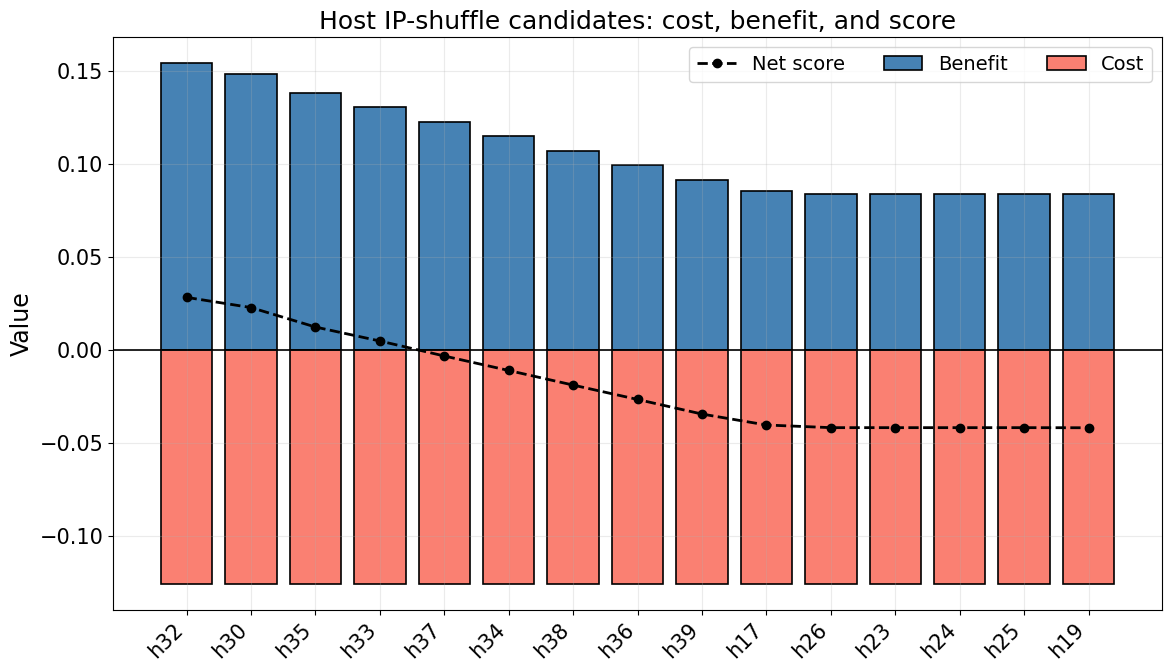

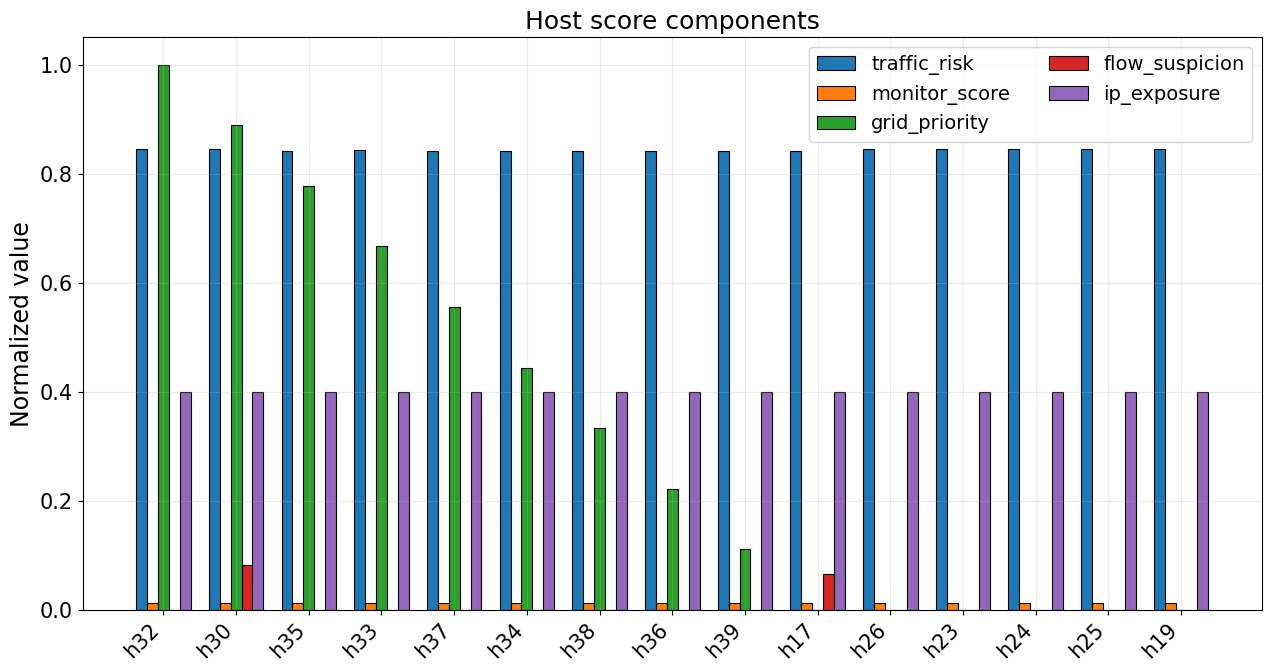

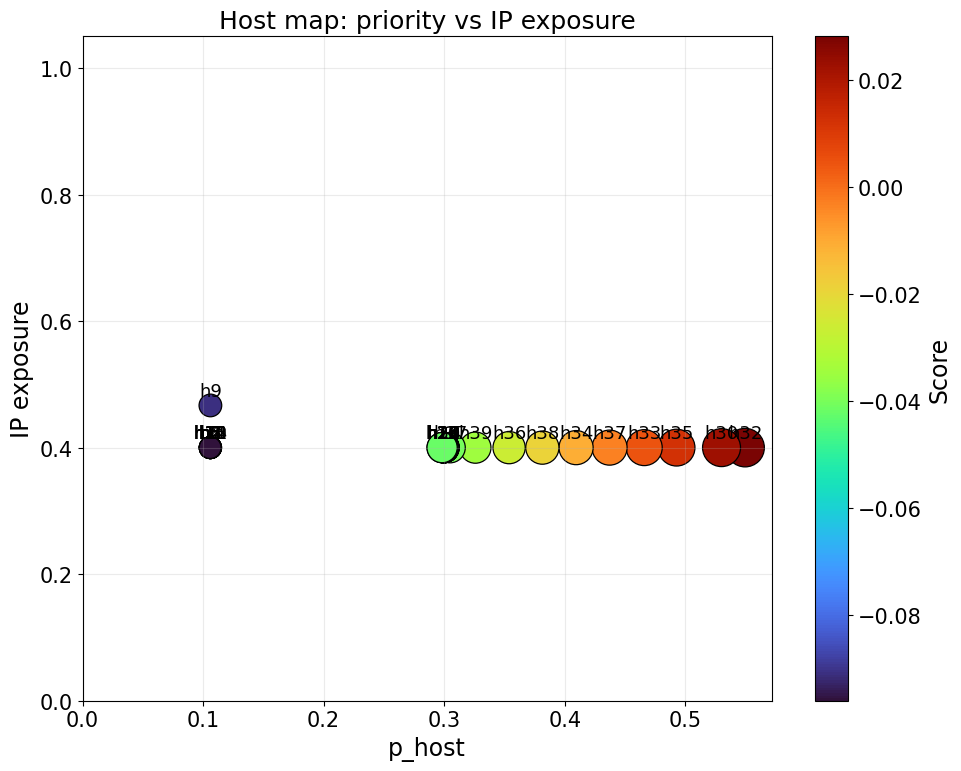

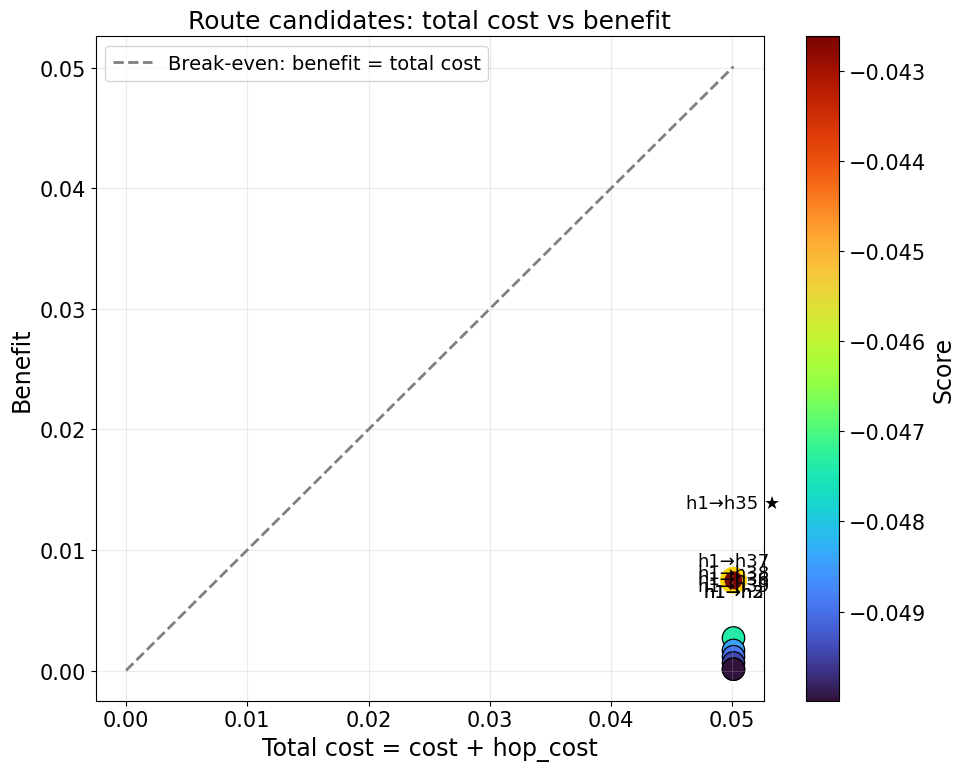

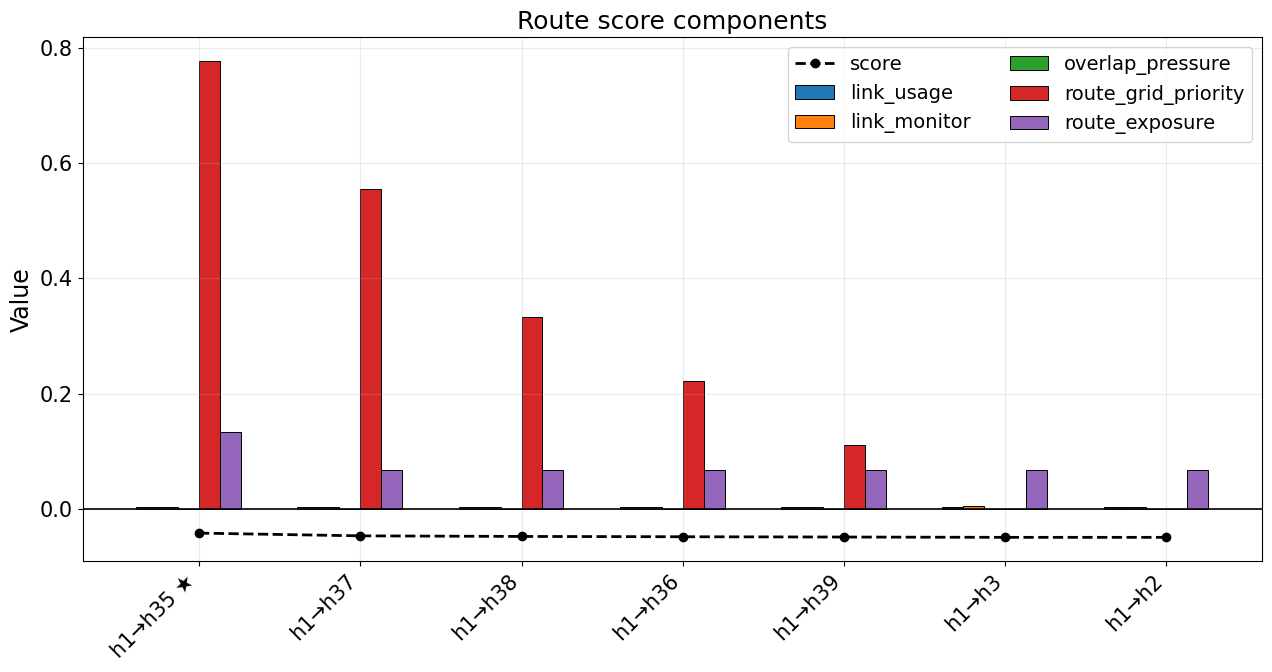

In [2]:
import importlib
import proactive_new_scoring
importlib.reload(proactive_new_scoring)

action, hosts, routes, details = proactive_new_scoring.decide_ilp()
# action, hosts, routes, details = decide_ilp()

build_matplotlib_dashboard(
    action=action,
    selected_hosts=hosts,
    selected_routes=routes,
    details=details,
    top_n=15
)

[DECISION MILP SOLVER TIME] 0.005555s | status=Optimal
Selected action: route_mutation
Selected IP hosts: []
Selected route mutations: ['h1->h3']
Solver time: not logged


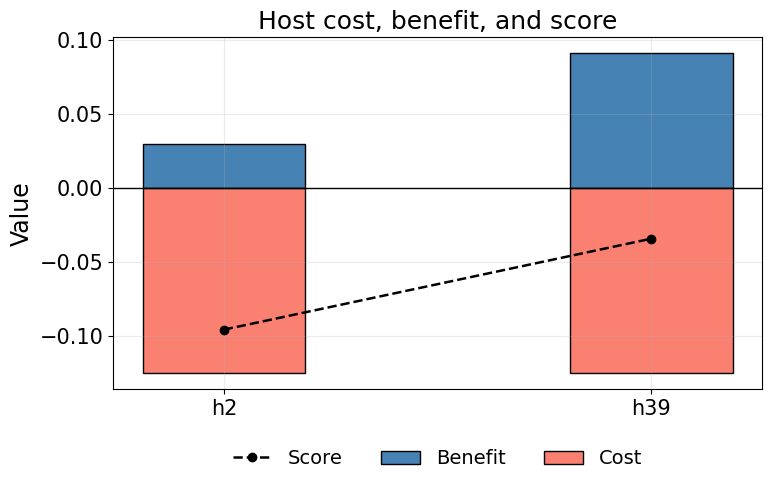

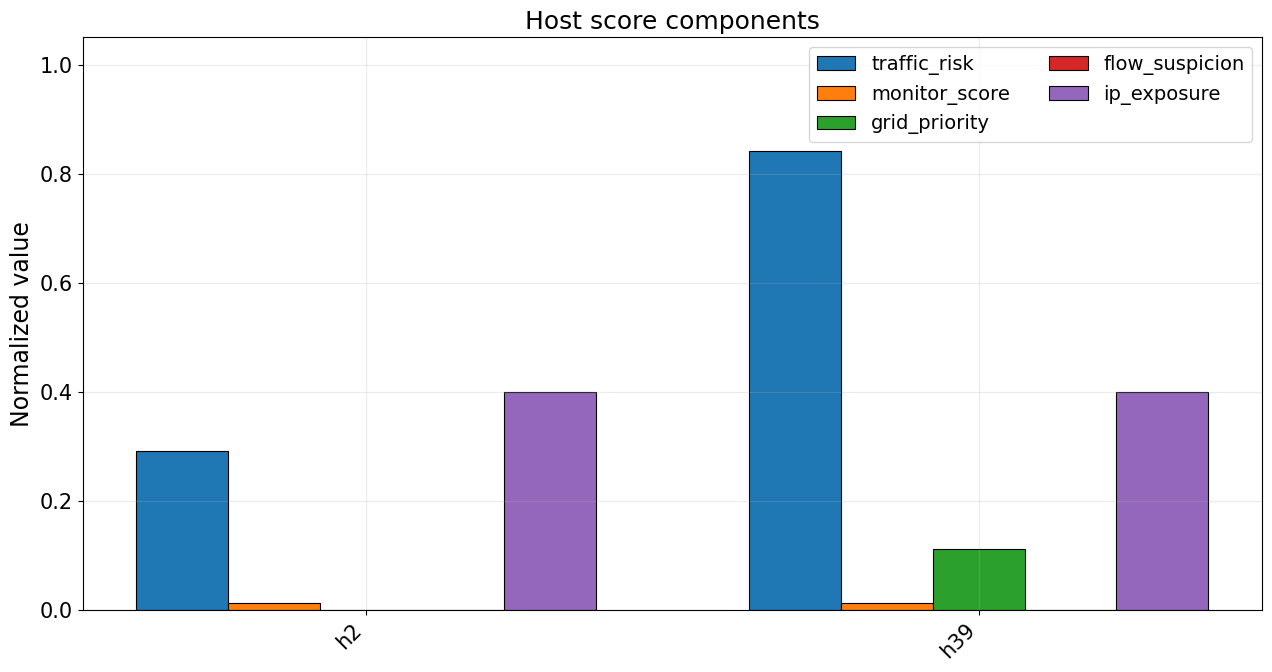

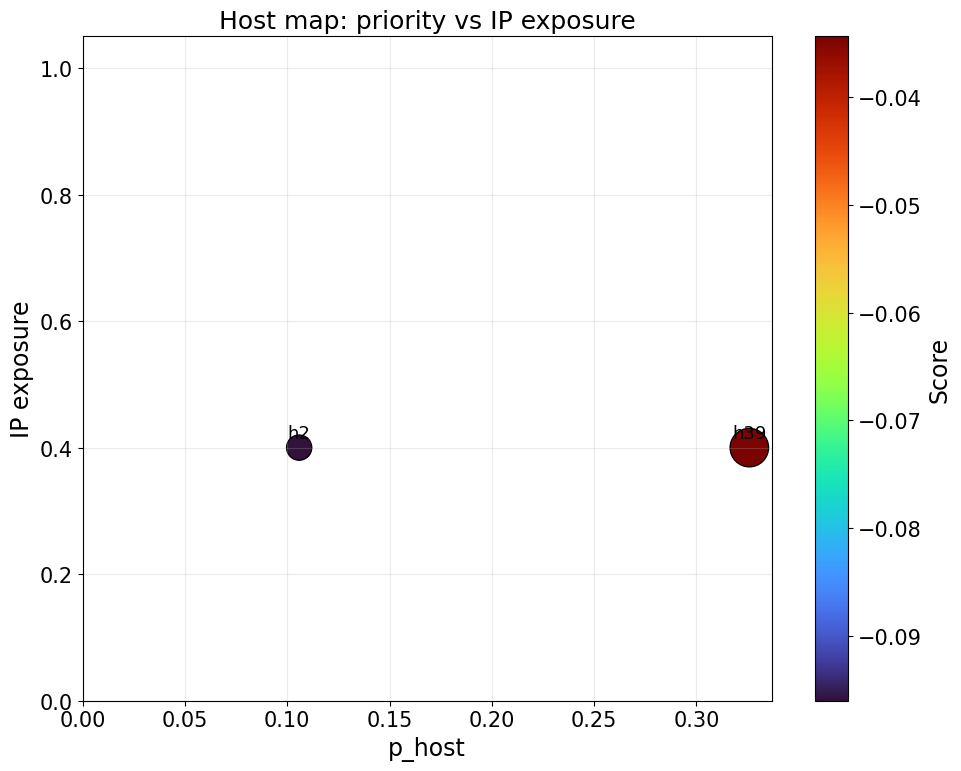

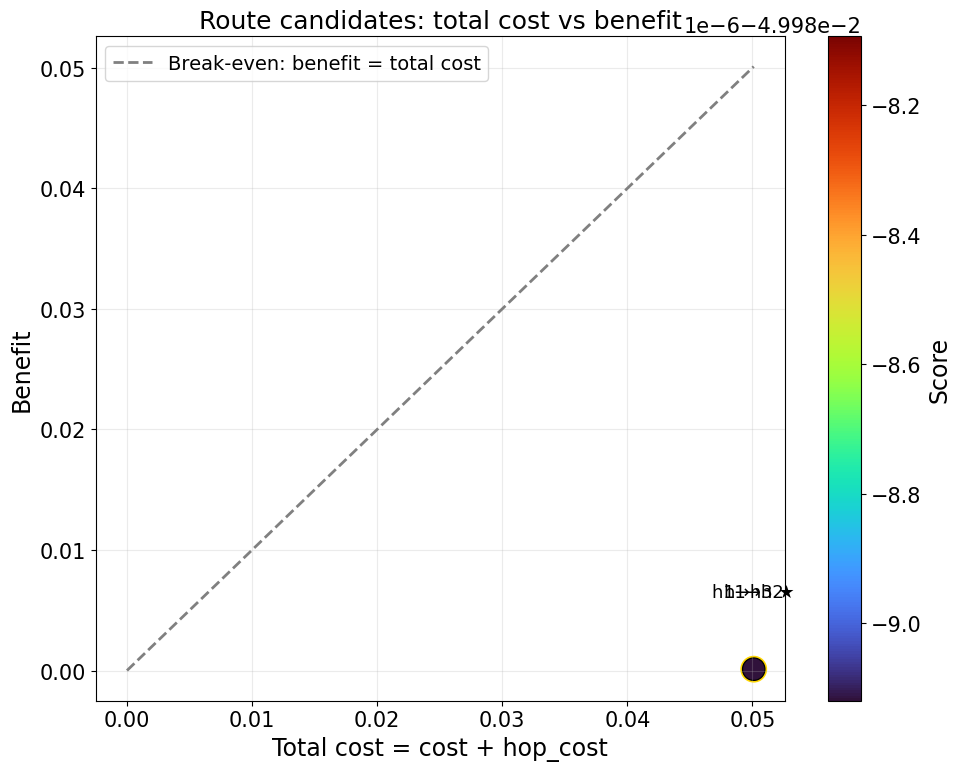

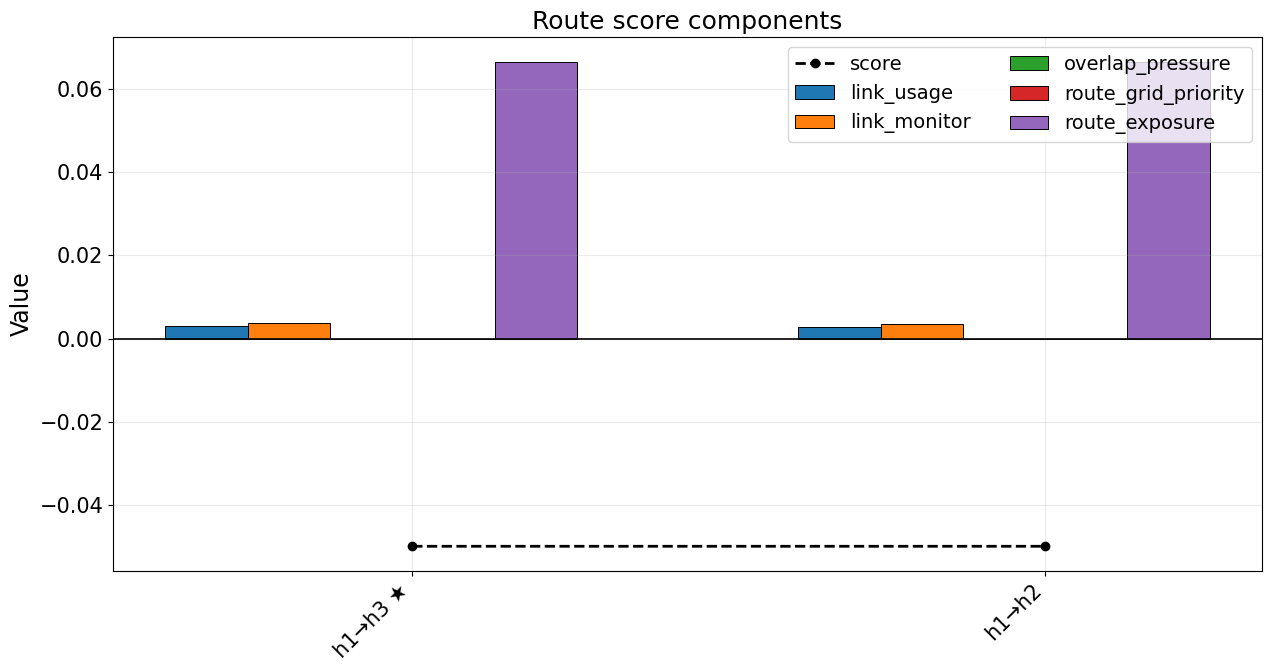

In [3]:

# import importlib
# import proactive_new_scoring
# importlib.reload(proactive_new_scoring)

# action, hosts, routes, details = proactive_new_scoring.decide_ilp()

# =========================
# OVERRIDE: SHOW FIXED HOSTS ONLY
# =========================

# TARGET_HOSTS = ["h33", "h2", "h15", "h39"]
# TARGET_HOSTS = ["h2", "h15", "h33", "h39"]
TARGET_HOSTS = ["h2", "h39"]


def plot_host_costbenefit(ip_candidates, selected_hosts, top_n=None):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    # uses your overridden ip_df(), so only TARGET_HOSTS are shown
    df = ip_df({"ip_candidates": ip_candidates})

    selected_hosts = set(selected_hosts or [])
    x = np.arange(len(df))

    # slimmer figure
    fig, ax = plt.subplots(figsize=(8, 5.2))

    bar_w = 0.38

    benefit_colors = [
        "gold" if h in selected_hosts else "steelblue"
        for h in df["host"]
    ]

    ax.bar(
        x,
        df["benefit"],
        width=bar_w,
        label="Benefit",
        color=benefit_colors,
        edgecolor="black",
        linewidth=1.0,
    )

    ax.bar(
        x,
        -df["cost"],
        width=bar_w,
        label="Cost",
        color="salmon",
        edgecolor="black",
        linewidth=1.0,
    )

    ax.plot(
        x,
        df["score"],
        marker="o",
        linestyle="--",
        color="black",
        linewidth=1.8,
        label="Score",
    )

    for i, row in df.iterrows():
        if row["host"] in selected_hosts:
            ax.text(
                i,
                row["benefit"] + 0.008,
                "★",
                ha="center",
                va="bottom",
                fontsize=18,
                color="black",
            )

    ax.axhline(0, color="black", linewidth=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels(df["host"], rotation=0)
    ax.set_ylabel("Value")
    ax.set_title("Host cost, benefit, and score")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
    )

    return fig

def ip_df(details, target_hosts=TARGET_HOSTS):
    df = pd.DataFrame(details.get("ip_candidates", []))

    needed = [
        "host", "score", "benefit", "cost", "p_host",
        "traffic_risk", "monitor_score", "grid_priority",
        "flow_suspicion", "ip_exposure",
        "rx_pps", "tx_pps", "rx_mbps", "tx_mbps",
    ]

    # If no IP candidates exist, still create blank rows for target hosts
    if df.empty:
        df = pd.DataFrame(columns=needed)

    # Ensure all needed columns exist
    for c in needed:
        if c not in df.columns:
            df[c] = 0.0

    df["host"] = df["host"].astype(str)

    # Keep only target hosts
    df = df[df["host"].isin(target_hosts)].copy()

    # Add missing hosts, for example h1 if excluded from IP shuffle
    missing_hosts = [h for h in target_hosts if h not in set(df["host"])]

    if missing_hosts:
        missing_df = pd.DataFrame({"host": missing_hosts})
        df = pd.concat([df, missing_df], ignore_index=True)

    # Convert numeric columns
    for c in needed:
        if c != "host":
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    # Preserve your requested order
    order_map = {h: i for i, h in enumerate(target_hosts)}
    df["host_order"] = df["host"].map(order_map)
    df = df.sort_values("host_order").drop(columns=["host_order"])

    return df.reset_index(drop=True)

from proactive_new_scoring import decide_ilp

action, hosts, routes, details = decide_ilp()

build_matplotlib_dashboard(
    action=action,
    selected_hosts=hosts,
    selected_routes=routes,
    details=details,
    top_n=15
)

Action: route_mutation
Selected hosts: []

Shown route candidates:
h2->h39 | score=0.5294 | current_option=0 | overlap=1.0
h15->h33 | score=0.2697 | current_option=1 | overlap=1.0

Shown host candidates:
h2 score= -0.0352 p_host= 0.6459 traffic= 0.9369 monitor= 1.0 flow_susp= 0.1797 flows= 11.0 short= 6.0 senders= 2.0
h39 score= -0.1154 p_host= 0.073 traffic= 0.0443 monitor= 0.0236 flow_susp= 0.2265 flows= 14.0 short= 7.0 senders= 2.0
Selected action: route_mutation
Selected IP hosts: []
Selected route mutations: ['h2->h39', 'h15->h33']
Solver time: not logged


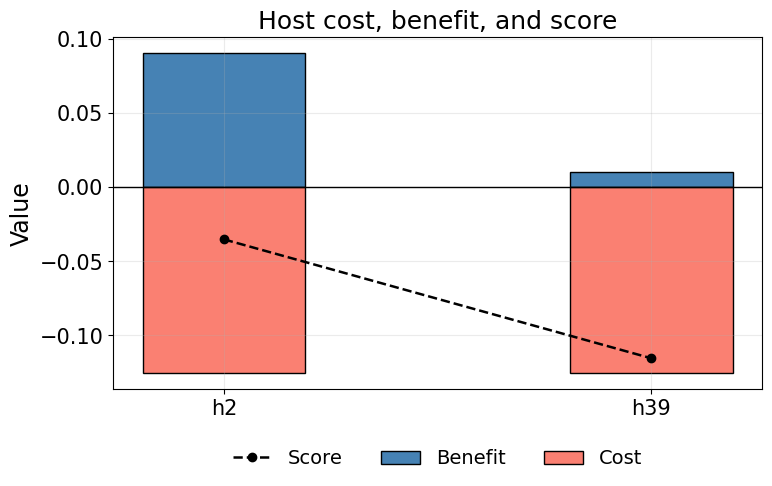

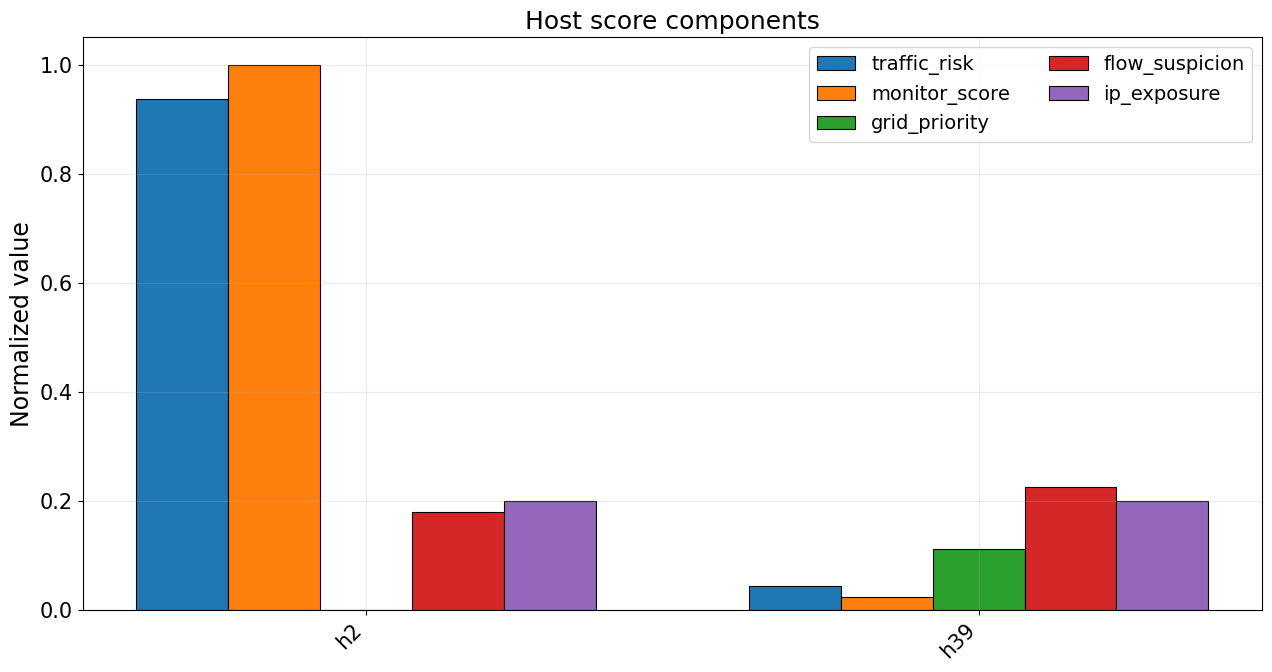

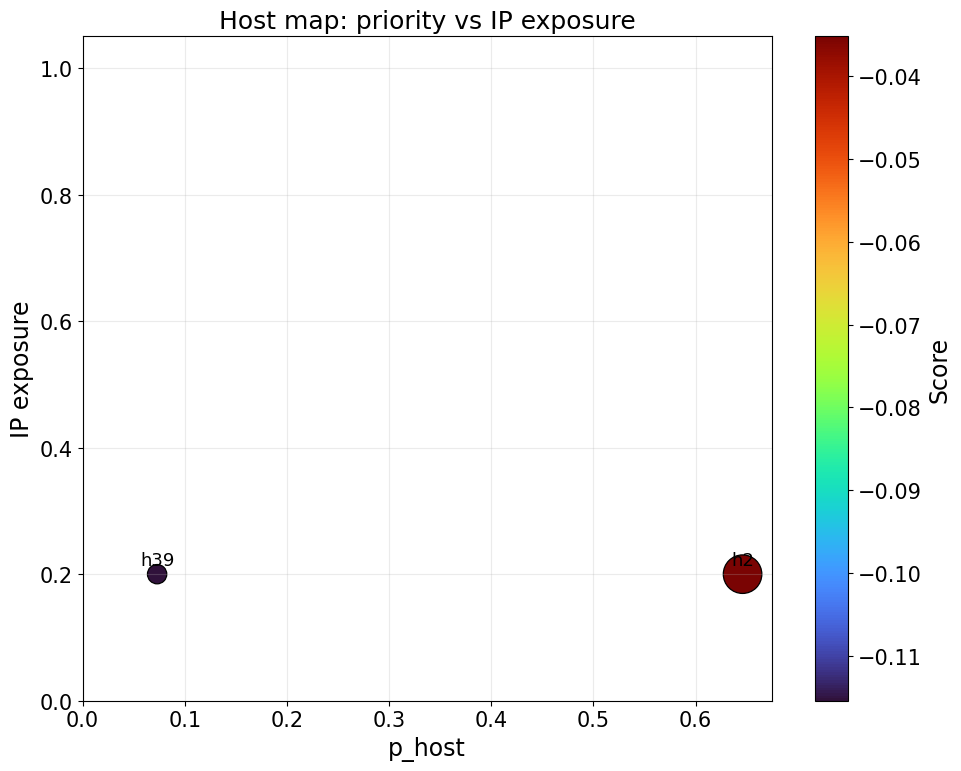

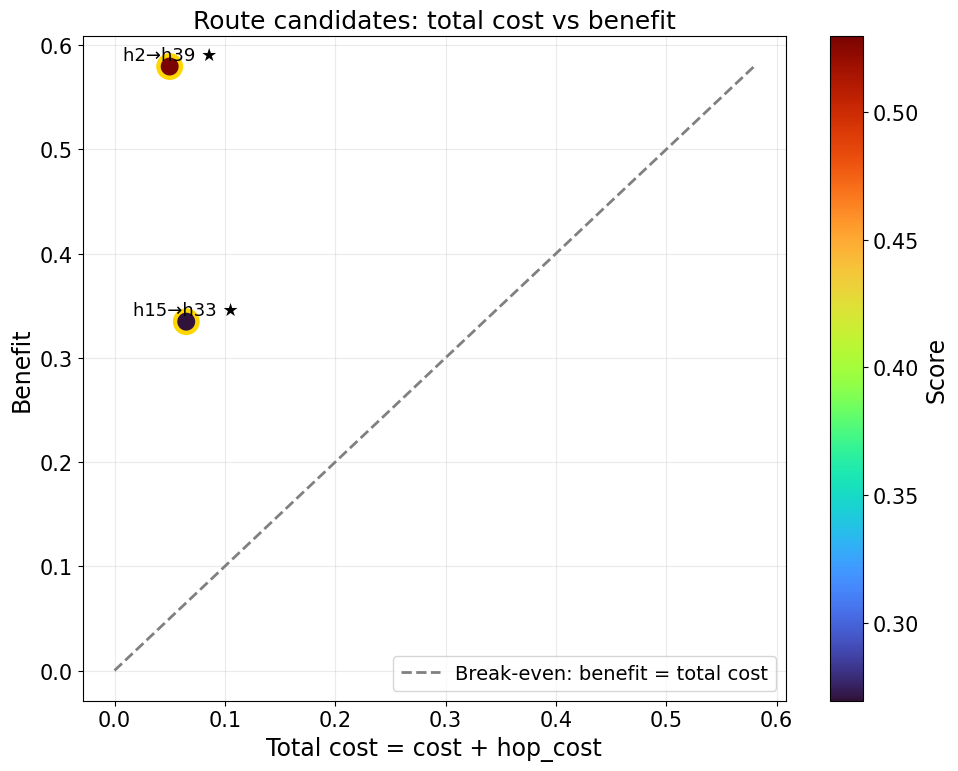

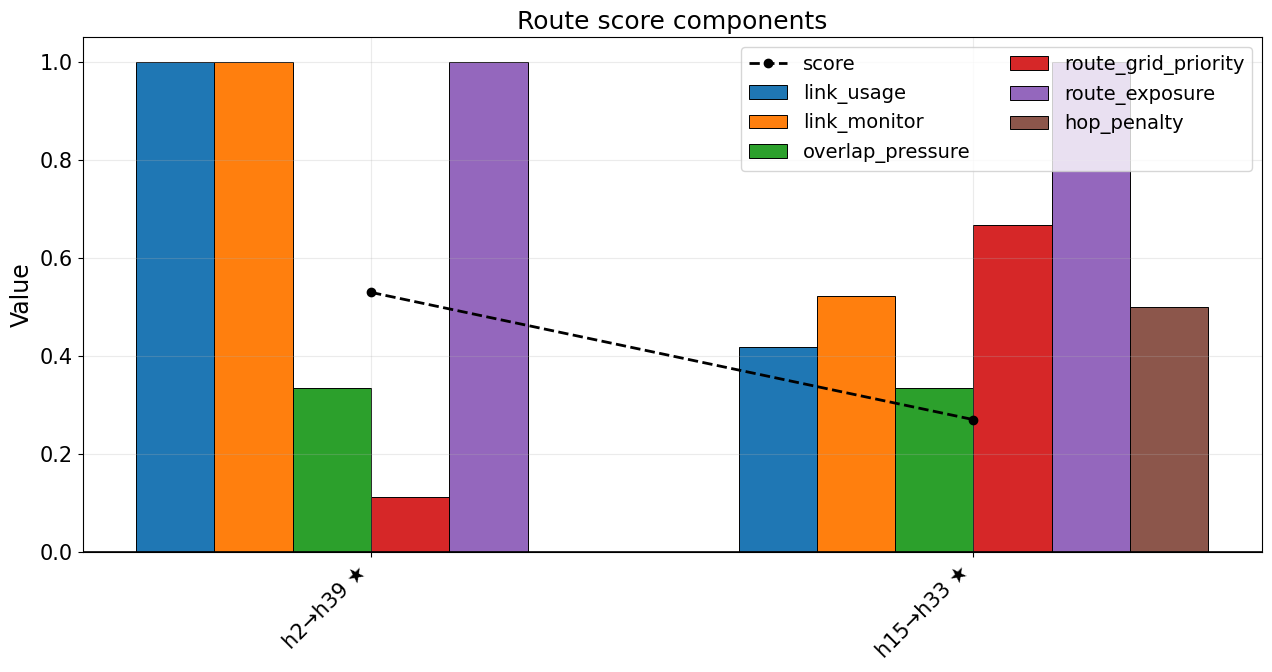

In [28]:
import re
import importlib
import pandas as pd
import numpy as np

import proactive_new_scoring
importlib.reload(proactive_new_scoring)

# =========================
# OVERRIDE: SHOW FIXED HOSTS ONLY
# =========================

TARGET_HOSTS = ["h2", "h39"]

# =========================
# OVERRIDE: SHOW FIXED ROUTES ONLY
# =========================

TARGET_ROUTE_PAIRS = [
    ("h2", "h39"),
    ("h15", "h33"),
]


def host_num_local(h):
    m = re.search(r"\d+", str(h))
    return int(m.group()) if m else 99999


def norm_pair(a, b):
    return tuple(sorted((str(a), str(b)), key=host_num_local))


TARGET_ROUTE_PAIRS_NORM = {
    norm_pair(a, b) for a, b in TARGET_ROUTE_PAIRS
}


def filter_routes(route_list):
    """
    Keep only route candidates / selected routes matching:
        h2-h39
        h15-h33
    """
    out = []

    for r in route_list or []:

        if "src" in r and "dst" in r:
            p = norm_pair(r["src"], r["dst"])

        elif "pair" in r and len(r["pair"]) == 2:
            p = norm_pair(r["pair"][0], r["pair"][1])

        else:
            continue

        if p in TARGET_ROUTE_PAIRS_NORM:
            out.append(r)

    return out


def plot_host_costbenefit(ip_candidates, selected_hosts, top_n=None):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    # uses overridden ip_df(), so only TARGET_HOSTS are shown
    df = ip_df({"ip_candidates": ip_candidates})

    selected_hosts = set(selected_hosts or [])
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(8, 5.2))

    bar_w = 0.38

    benefit_colors = [
        "gold" if h in selected_hosts else "steelblue"
        for h in df["host"]
    ]

    ax.bar(
        x,
        df["benefit"],
        width=bar_w,
        label="Benefit",
        color=benefit_colors,
        edgecolor="black",
        linewidth=1.0,
    )

    ax.bar(
        x,
        -df["cost"],
        width=bar_w,
        label="Cost",
        color="salmon",
        edgecolor="black",
        linewidth=1.0,
    )

    ax.plot(
        x,
        df["score"],
        marker="o",
        linestyle="--",
        color="black",
        linewidth=1.8,
        label="Score",
    )

    for i, row in df.iterrows():
        if row["host"] in selected_hosts:
            ax.text(
                i,
                row["benefit"] + 0.008,
                "★",
                ha="center",
                va="bottom",
                fontsize=18,
                color="black",
            )

    ax.axhline(0, color="black", linewidth=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels(df["host"], rotation=0)
    ax.set_ylabel("Value")
    ax.set_title("Host cost, benefit, and score")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
    )

    return fig


def ip_df(details, target_hosts=TARGET_HOSTS):
    df = pd.DataFrame(details.get("ip_candidates", []))

    needed = [
        "host", "score", "benefit", "cost", "p_host",
        "traffic_risk", "monitor_score", "grid_priority",
        "flow_suspicion", "ip_exposure",
        "rx_pps", "tx_pps", "rx_mbps", "tx_mbps",
    ]

    if df.empty:
        df = pd.DataFrame(columns=needed)

    for c in needed:
        if c not in df.columns:
            df[c] = 0.0

    df["host"] = df["host"].astype(str)

    # Keep only target hosts
    df = df[df["host"].isin(target_hosts)].copy()

    # Add missing target hosts as blank rows
    missing_hosts = [h for h in target_hosts if h not in set(df["host"])]

    if missing_hosts:
        missing_df = pd.DataFrame({"host": missing_hosts})
        df = pd.concat([df, missing_df], ignore_index=True)

    for c in needed:
        if c != "host":
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    order_map = {h: i for i, h in enumerate(target_hosts)}
    df["host_order"] = df["host"].map(order_map)
    df = df.sort_values("host_order").drop(columns=["host_order"])

    return df.reset_index(drop=True)


# =========================
# RUN DECISION
# =========================

action, hosts, routes, details = proactive_new_scoring.decide_ilp()

# =========================
# FILTER ROUTES FOR DASHBOARD
# =========================

details["route_candidates"] = filter_routes(details.get("route_candidates", []))
details["selected_routes"] = filter_routes(details.get("selected_routes", []))
routes = filter_routes(routes)

print("Action:", action)
print("Selected hosts:", hosts)

print("\nShown route candidates:")
for r in details["route_candidates"]:
    print(
        f"{r.get('src')}->{r.get('dst')} | "
        f"score={r.get('score', 0):.4f} | "
        f"current_option={r.get('current_option', '?')} | "
        f"overlap={r.get('max_flow_overlap', 0)}"
    )

# Optional quick raw check for h2/h39 flow suspicion
print("\nShown host candidates:")
for c in details["ip_candidates"]:
    if c["host"] in TARGET_HOSTS:
        print(
            c["host"],
            "score=", round(c.get("score", 0), 4),
            "p_host=", round(c.get("p_host", 0), 4),
            "traffic=", round(c.get("traffic_risk", 0), 4),
            "monitor=", round(c.get("monitor_score", 0), 4),
            "flow_susp=", round(c.get("flow_suspicion", 0), 4),
            "flows=", c.get("unique_flow_count", 0),
            "short=", c.get("short_lived_flow_count", 0),
            "senders=", c.get("unique_sender_mac_count", 0),
        )

# =========================
# BUILD DASHBOARD
# =========================

build_matplotlib_dashboard(
    action=action,
    selected_hosts=hosts,
    selected_routes=routes,
    details=details,
    top_n=15
)

[DECISION MILP SOLVER TIME] 0.005178s | status=Optimal
Action: route_mutation
Selected hosts: []

Shown route candidates:
h2->h39 | score=0.4381 | current_option=0 | overlap=1.0
h15->h33 | score=-0.0120 | current_option=0 | overlap=0.0

Shown host candidates:
h39 score= 0.067 p_host= 0.6878 traffic= 0.9815 monitor= 1.0 flow_susp= 0.1647 flows= 7.0 short= 7.0 senders= 2.0
h2 score= -0.1134 p_host= 0.0436 traffic= 0.0144 monitor= 0.0462 flow_susp= 0.2471 flows= 9.0 short= 9.0 senders= 2.0
Selected action: route_mutation
Selected IP hosts: []
Selected route mutations: ['h2->h39']
Solver time: not logged


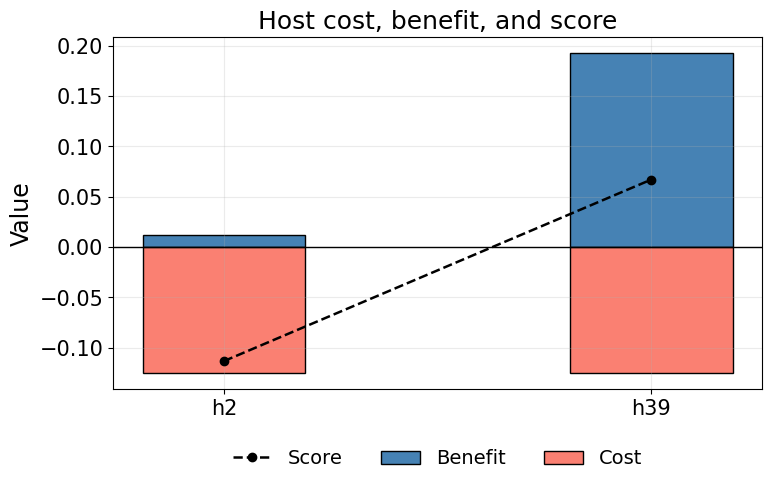

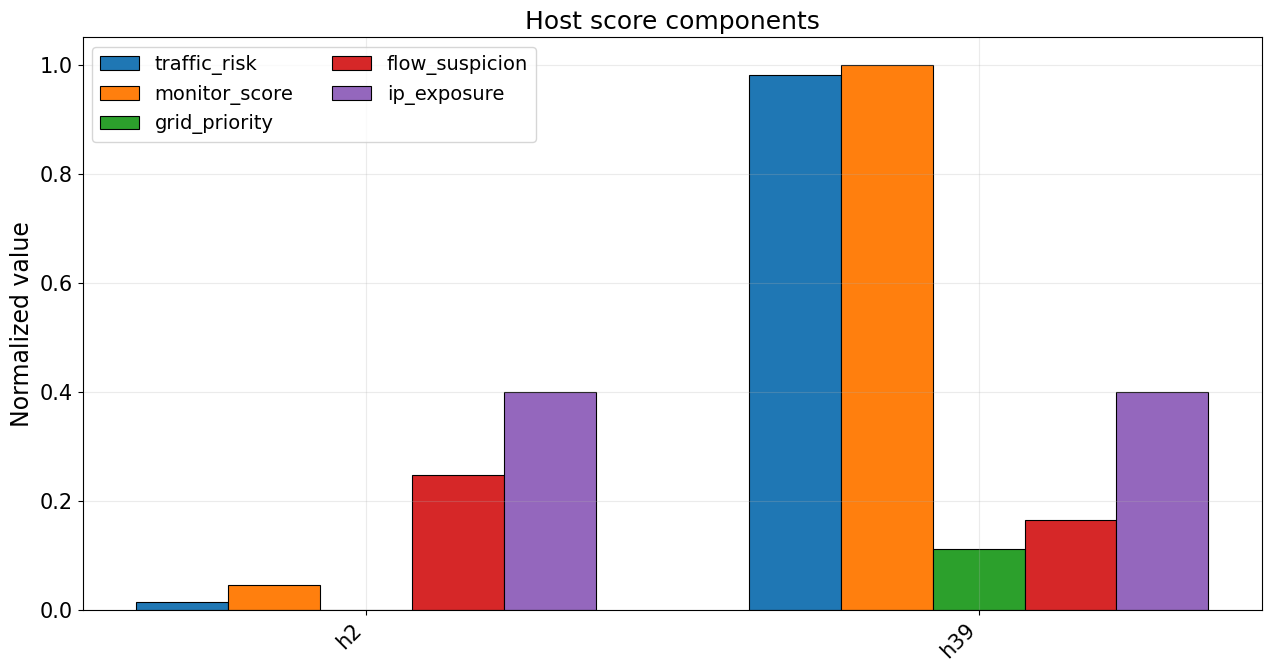

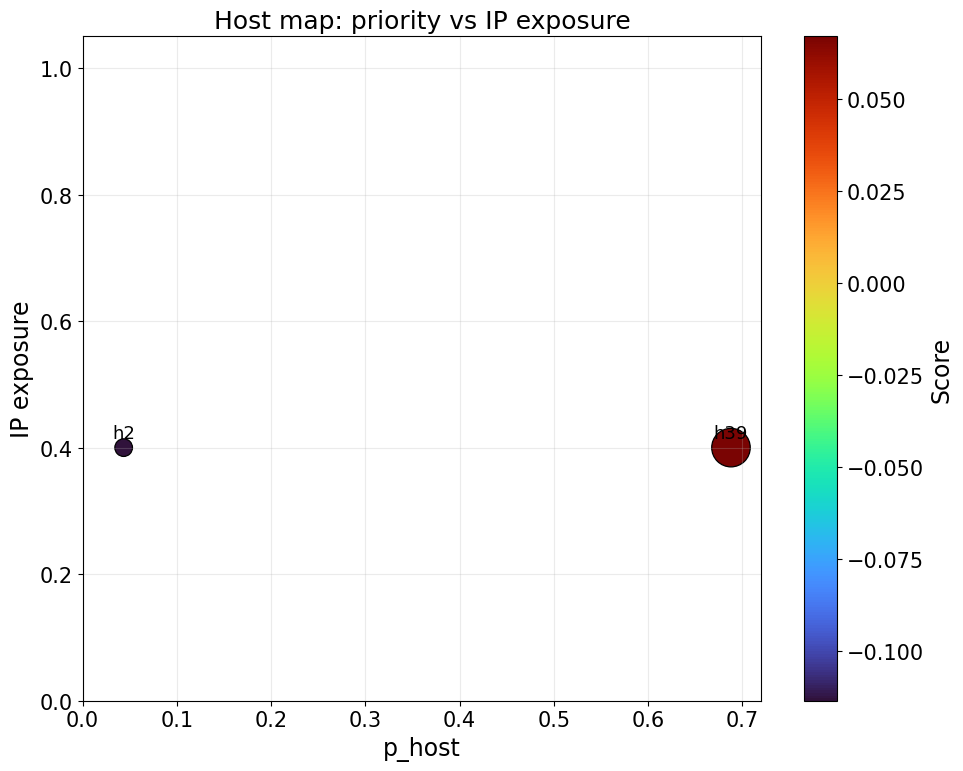

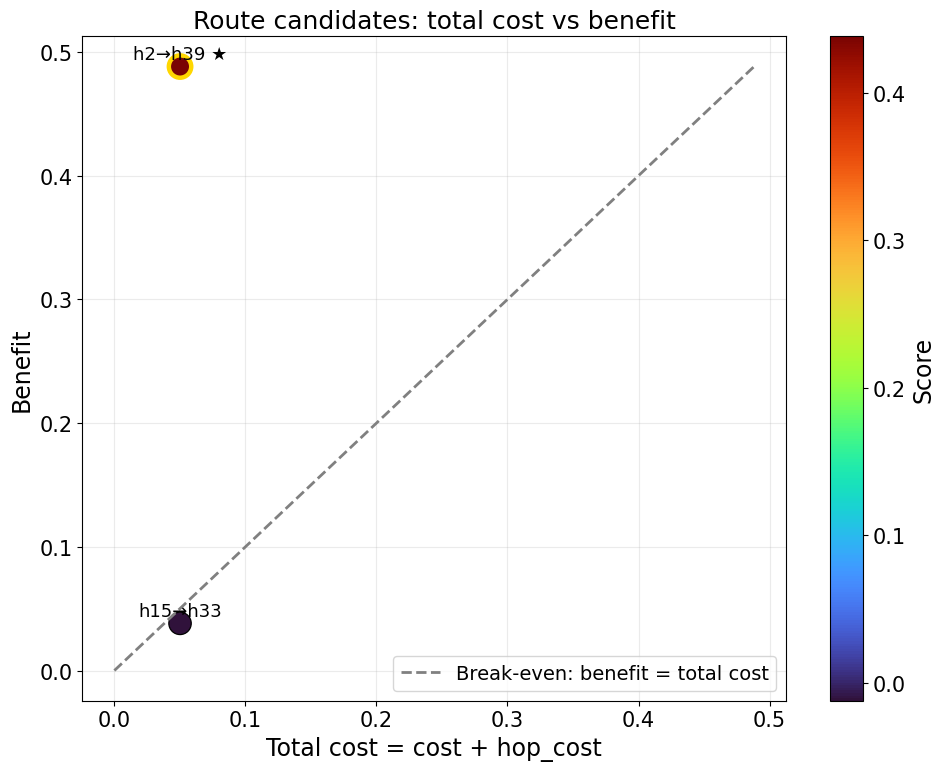

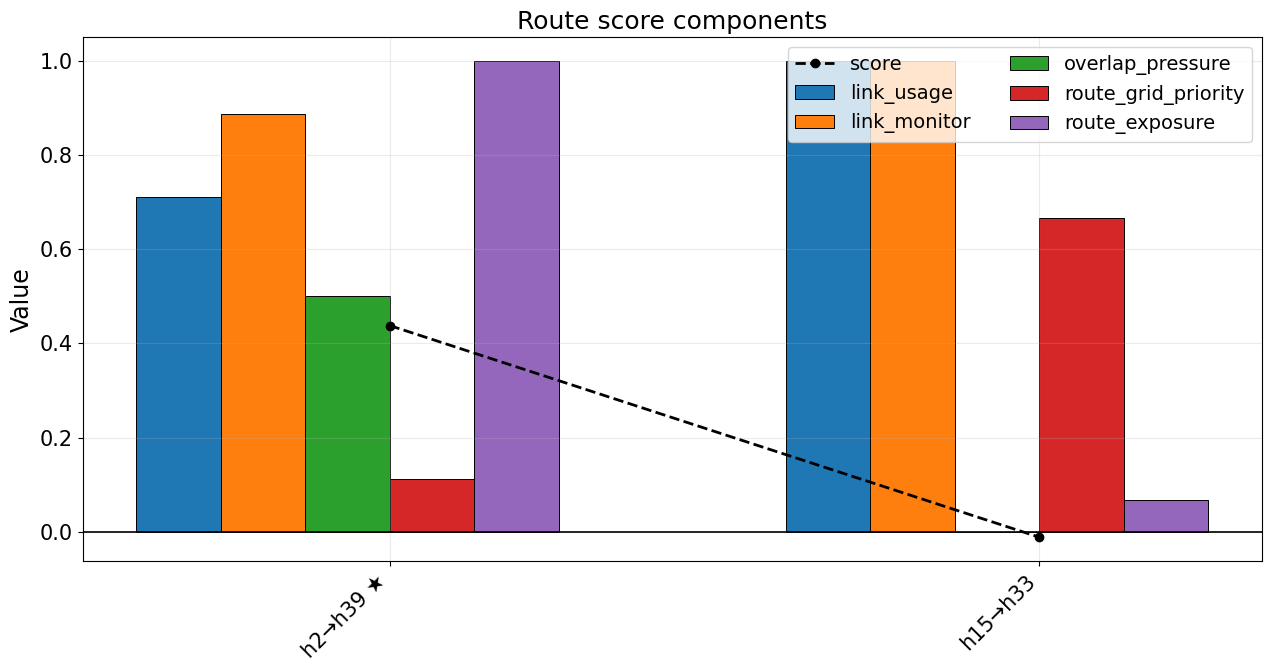

In [8]:
import re
import importlib
import pandas as pd
import numpy as np

import proactive_new_scoring
importlib.reload(proactive_new_scoring)

# =========================
# OVERRIDE: SHOW FIXED HOSTS ONLY
# =========================

TARGET_HOSTS = ["h2", "h39"]

# =========================
# OVERRIDE: SHOW FIXED ROUTES ONLY
# =========================

TARGET_ROUTE_PAIRS = [
    ("h2", "h39"),
    ("h15", "h33"),
]


def host_num_local(h):
    m = re.search(r"\d+", str(h))
    return int(m.group()) if m else 99999


def norm_pair(a, b):
    return tuple(sorted((str(a), str(b)), key=host_num_local))


TARGET_ROUTE_PAIRS_NORM = {
    norm_pair(a, b) for a, b in TARGET_ROUTE_PAIRS
}


def filter_routes(route_list):
    """
    Keep only route candidates / selected routes matching:
        h2-h39
        h15-h33
    """
    out = []

    for r in route_list or []:

        if "src" in r and "dst" in r:
            p = norm_pair(r["src"], r["dst"])

        elif "pair" in r and len(r["pair"]) == 2:
            p = norm_pair(r["pair"][0], r["pair"][1])

        else:
            continue

        if p in TARGET_ROUTE_PAIRS_NORM:
            out.append(r)

    return out


def plot_host_costbenefit(ip_candidates, selected_hosts, top_n=None):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    # uses overridden ip_df(), so only TARGET_HOSTS are shown
    df = ip_df({"ip_candidates": ip_candidates})

    selected_hosts = set(selected_hosts or [])
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(8, 5.2))

    bar_w = 0.38

    benefit_colors = [
        "gold" if h in selected_hosts else "steelblue"
        for h in df["host"]
    ]

    ax.bar(
        x,
        df["benefit"],
        width=bar_w,
        label="Benefit",
        color=benefit_colors,
        edgecolor="black",
        linewidth=1.0,
    )

    ax.bar(
        x,
        -df["cost"],
        width=bar_w,
        label="Cost",
        color="salmon",
        edgecolor="black",
        linewidth=1.0,
    )

    ax.plot(
        x,
        df["score"],
        marker="o",
        linestyle="--",
        color="black",
        linewidth=1.8,
        label="Score",
    )

    for i, row in df.iterrows():
        if row["host"] in selected_hosts:
            ax.text(
                i,
                row["benefit"] + 0.008,
                "★",
                ha="center",
                va="bottom",
                fontsize=18,
                color="black",
            )

    ax.axhline(0, color="black", linewidth=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels(df["host"], rotation=0)
    ax.set_ylabel("Value")
    ax.set_title("Host cost, benefit, and score")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=3,
        frameon=False,
    )

    return fig


def ip_df(details, target_hosts=TARGET_HOSTS):
    df = pd.DataFrame(details.get("ip_candidates", []))

    needed = [
        "host", "score", "benefit", "cost", "p_host",
        "traffic_risk", "monitor_score", "grid_priority",
        "flow_suspicion", "ip_exposure",
        "rx_pps", "tx_pps", "rx_mbps", "tx_mbps",
    ]

    if df.empty:
        df = pd.DataFrame(columns=needed)

    for c in needed:
        if c not in df.columns:
            df[c] = 0.0

    df["host"] = df["host"].astype(str)

    # Keep only target hosts
    df = df[df["host"].isin(target_hosts)].copy()

    # Add missing target hosts as blank rows
    missing_hosts = [h for h in target_hosts if h not in set(df["host"])]

    if missing_hosts:
        missing_df = pd.DataFrame({"host": missing_hosts})
        df = pd.concat([df, missing_df], ignore_index=True)

    for c in needed:
        if c != "host":
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    order_map = {h: i for i, h in enumerate(target_hosts)}
    df["host_order"] = df["host"].map(order_map)
    df = df.sort_values("host_order").drop(columns=["host_order"])

    return df.reset_index(drop=True)


# =========================
# RUN DECISION
# =========================

action, hosts, routes, details = proactive_new_scoring.decide_ilp()

# =========================
# FILTER ROUTES FOR DASHBOARD
# =========================

details["route_candidates"] = filter_routes(details.get("route_candidates", []))
details["selected_routes"] = filter_routes(details.get("selected_routes", []))
routes = filter_routes(routes)

print("Action:", action)
print("Selected hosts:", hosts)

print("\nShown route candidates:")
for r in details["route_candidates"]:
    print(
        f"{r.get('src')}->{r.get('dst')} | "
        f"score={r.get('score', 0):.4f} | "
        f"current_option={r.get('current_option', '?')} | "
        f"overlap={r.get('max_flow_overlap', 0)}"
    )

# Optional quick raw check for h2/h39 flow suspicion
print("\nShown host candidates:")
for c in details["ip_candidates"]:
    if c["host"] in TARGET_HOSTS:
        print(
            c["host"],
            "score=", round(c.get("score", 0), 4),
            "p_host=", round(c.get("p_host", 0), 4),
            "traffic=", round(c.get("traffic_risk", 0), 4),
            "monitor=", round(c.get("monitor_score", 0), 4),
            "flow_susp=", round(c.get("flow_suspicion", 0), 4),
            "flows=", c.get("unique_flow_count", 0),
            "short=", c.get("short_lived_flow_count", 0),
            "senders=", c.get("unique_sender_mac_count", 0),
        )

# =========================
# BUILD DASHBOARD
# =========================

build_matplotlib_dashboard(
    action=action,
    selected_hosts=hosts,
    selected_routes=routes,
    details=details,
    top_n=15
)

### final plot

[DECISION MILP SOLVER TIME] 0.005735s | status=Optimal
Action: route_mutation
Selected hosts: []

Shown route candidates:
h2->h39 | score=0.5527 | current_option=0 | overlap=2.0
h15->h33 | score=-0.0073 | current_option=0 | overlap=2.0

Shown host candidates:
h39 score= 0.0655 p_host= 0.6824 traffic= 0.9932 monitor= 1.0 flow_susp= 0.0706 flows= 7.0 short= 3.0 senders= 2.0
h15 score= 0.0505 p_host= 0.629 traffic= 0.9199 monitor= 1.0 flow_susp= 0.0706 flows= 7.0 short= 3.0 senders= 2.0
h33 score= -0.0698 p_host= 0.1993 traffic= 0.0065 monitor= 0.0462 flow_susp= 0.1647 flows= 7.0 short= 7.0 senders= 2.0
h2 score= -0.1142 p_host= 0.0408 traffic= 0.0063 monitor= 0.0462 flow_susp= 0.2471 flows= 9.0 short= 9.0 senders= 2.0
Selected action: route_mutation
Selected IP hosts: []
Selected route mutations: ['h2->h39']
Solver time: not logged


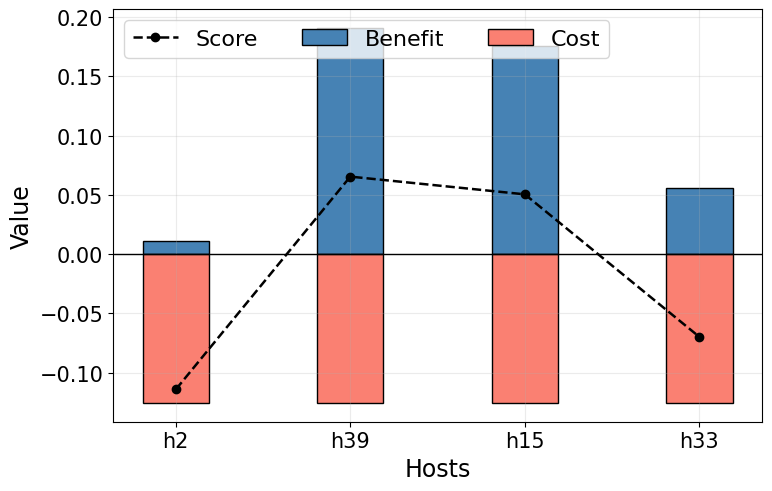

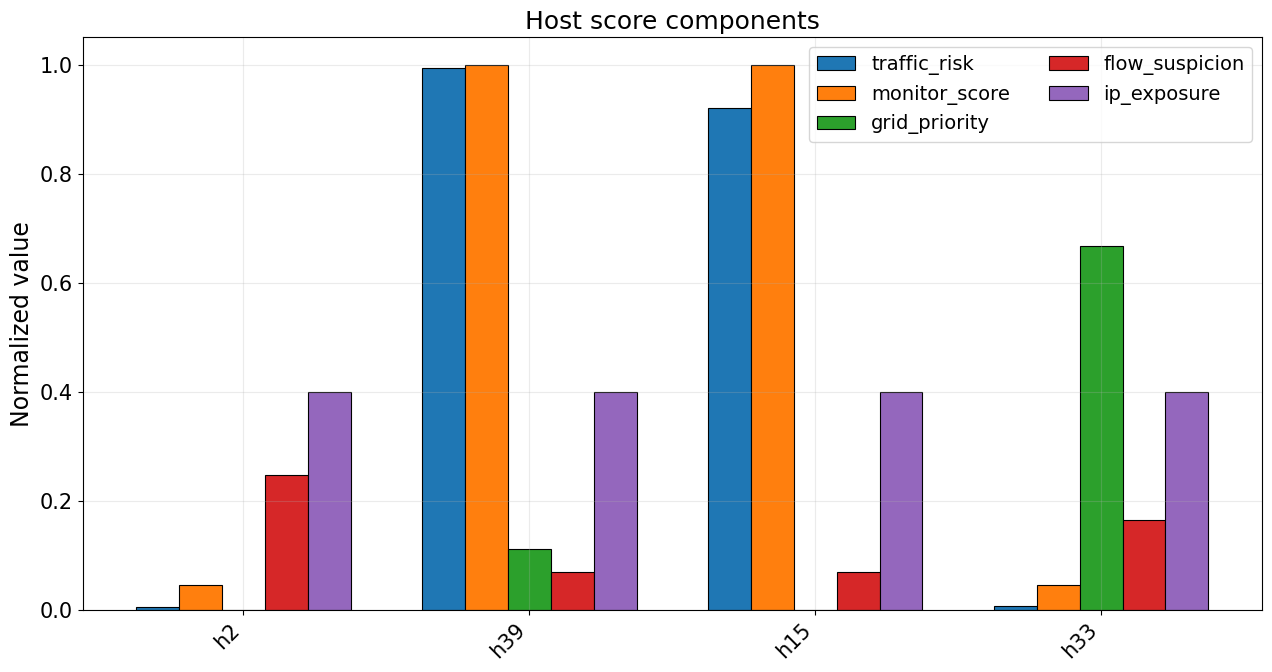

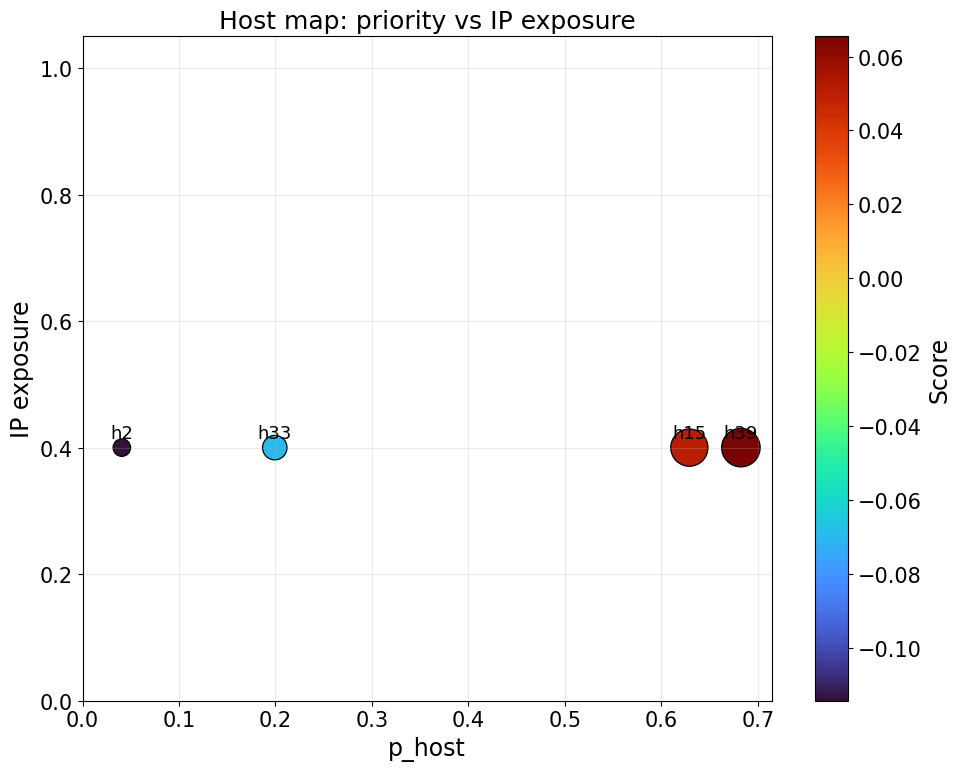

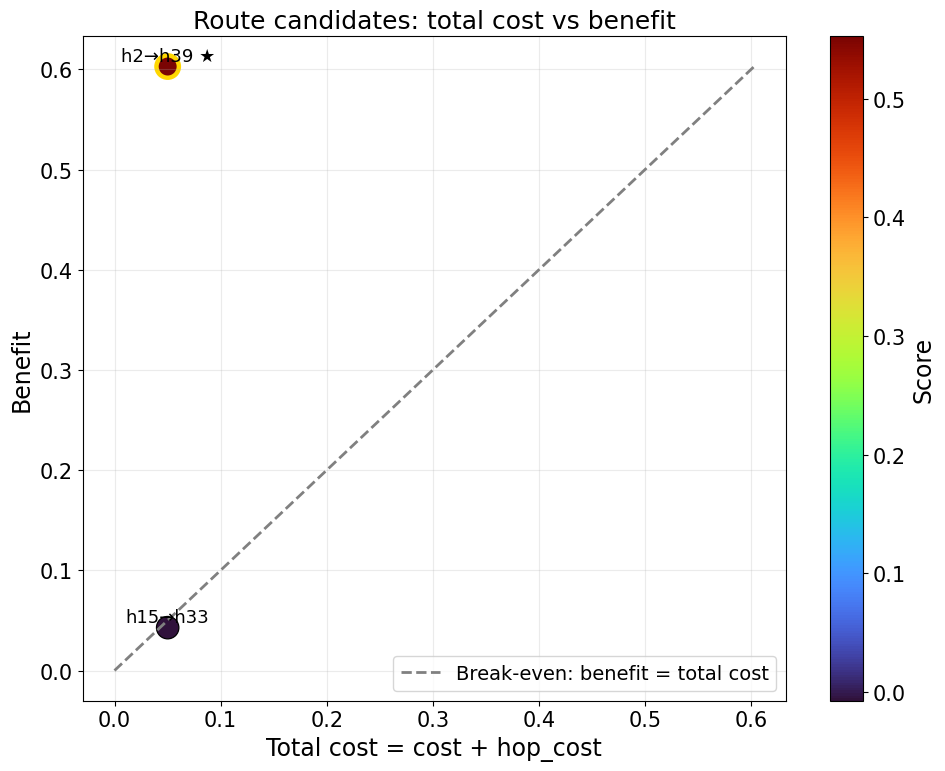

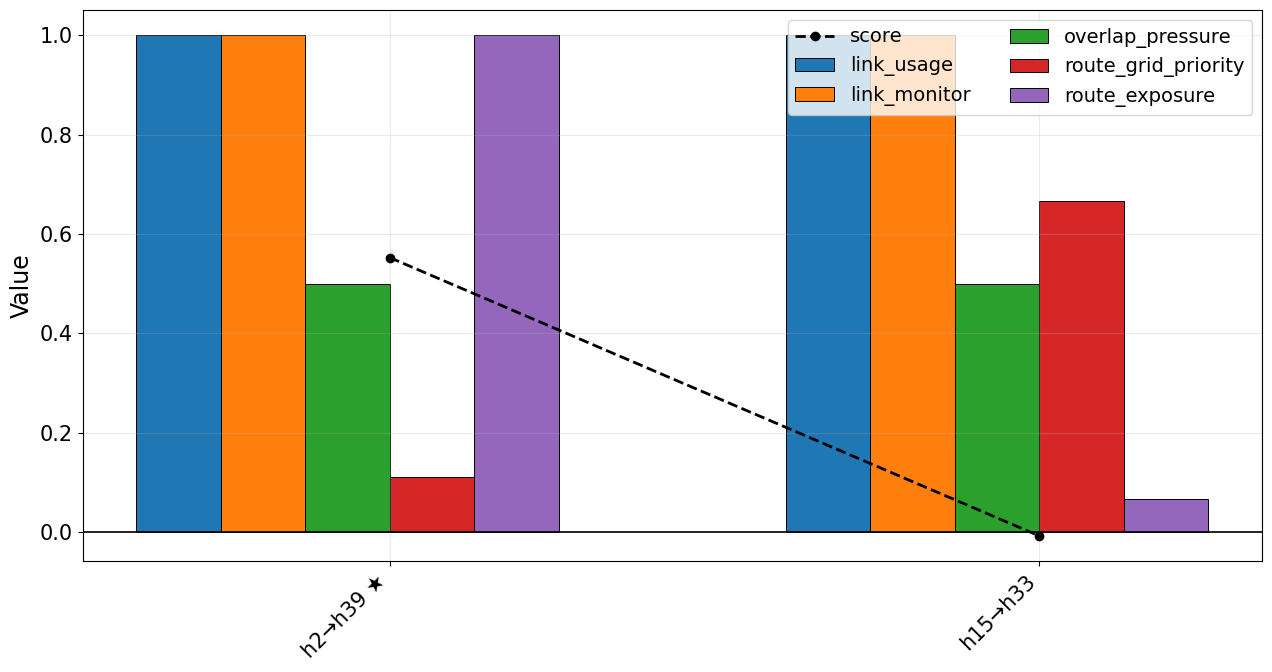

In [12]:
import re
import importlib
import pandas as pd
import numpy as np

import proactive_new_scoring
importlib.reload(proactive_new_scoring)

# =========================
# OVERRIDE: SHOW FIXED HOSTS ONLY
# =========================

TARGET_HOSTS = ["h2", "h39", "h15", "h33"]

# =========================
# OVERRIDE: SHOW FIXED ROUTES ONLY
# =========================

TARGET_ROUTE_PAIRS = [
    ("h2", "h39"),
    ("h15", "h33"),
]


def host_num_local(h):
    m = re.search(r"\d+", str(h))
    return int(m.group()) if m else 99999


def norm_pair(a, b):
    return tuple(sorted((str(a), str(b)), key=host_num_local))


TARGET_ROUTE_PAIRS_NORM = {
    norm_pair(a, b) for a, b in TARGET_ROUTE_PAIRS
}


def filter_routes(route_list):
    """
    Keep only route candidates / selected routes matching:
        h2-h39
        h15-h33
    """
    out = []

    for r in route_list or []:

        if "src" in r and "dst" in r:
            p = norm_pair(r["src"], r["dst"])

        elif "pair" in r and len(r["pair"]) == 2:
            p = norm_pair(r["pair"][0], r["pair"][1])

        else:
            continue

        if p in TARGET_ROUTE_PAIRS_NORM:
            out.append(r)

    return out


def plot_host_costbenefit(ip_candidates, selected_hosts, top_n=None):
    df = pd.DataFrame(ip_candidates or [])

    if df.empty:
        print("No IP candidates.")
        return None

    # uses overridden ip_df(), so only TARGET_HOSTS are shown
    df = ip_df({"ip_candidates": ip_candidates})

    selected_hosts = set(selected_hosts or [])
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(8, 5.2))

    bar_w = 0.38

    benefit_colors = ["steelblue" for h in df["host"]]

    ax.bar(
        x,
        df["benefit"],
        width=bar_w,
        label="Benefit",
        color=benefit_colors,
        edgecolor="black",
        linewidth=1.0,
    )

    ax.bar(
        x,
        -df["cost"],
        width=bar_w,
        label="Cost",
        color="salmon",
        edgecolor="black",
        linewidth=1.0,
    )

    ax.plot(
        x,
        df["score"],
        marker="o",
        linestyle="--",
        color="black",
        linewidth=1.8,
        label="Score",
    )

    for i, row in df.iterrows():
        if row["host"] in selected_hosts:
            ax.text(
                i,
                row["benefit"] + 0.008,
                "★",
                ha="center",
                va="bottom",
                fontsize=18,
                color="black",
            )

    ax.axhline(0, color="black", linewidth=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels(df["host"], rotation=0)

    ax.set_xlabel("Hosts")
    ax.set_ylabel("Value")

    # Force legend order: Score, Benefit, Cost
    handles, labels = ax.get_legend_handles_labels()

    legend_order = ["Score", "Benefit", "Cost"]

    ordered_handles = [
        handles[labels.index(name)]
        for name in legend_order
        if name in labels
    ]

    ordered_labels = [
        name
        for name in legend_order
        if name in labels
    ]

    ax.legend(
        ordered_handles,
        ordered_labels,
        loc="upper left",
        ncol=3,
        frameon=True,
        fontsize=16,
    )
    return fig


def ip_df(details, target_hosts=TARGET_HOSTS):
    df = pd.DataFrame(details.get("ip_candidates", []))

    needed = [
        "host", "score", "benefit", "cost", "p_host",
        "traffic_risk", "monitor_score", "grid_priority",
        "flow_suspicion", "ip_exposure",
        "rx_pps", "tx_pps", "rx_mbps", "tx_mbps",
    ]

    if df.empty:
        df = pd.DataFrame(columns=needed)

    for c in needed:
        if c not in df.columns:
            df[c] = 0.0

    df["host"] = df["host"].astype(str)

    # Keep only target hosts
    df = df[df["host"].isin(target_hosts)].copy()

    # Add missing target hosts as blank rows
    missing_hosts = [h for h in target_hosts if h not in set(df["host"])]

    if missing_hosts:
        missing_df = pd.DataFrame({"host": missing_hosts})
        df = pd.concat([df, missing_df], ignore_index=True)

    for c in needed:
        if c != "host":
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    order_map = {h: i for i, h in enumerate(target_hosts)}
    df["host_order"] = df["host"].map(order_map)
    df = df.sort_values("host_order").drop(columns=["host_order"])

    return df.reset_index(drop=True)


# =========================
# RUN DECISION
# =========================

action, hosts, routes, details = proactive_new_scoring.decide_ilp()

# =========================
# FILTER ROUTES FOR DASHBOARD
# =========================

details["route_candidates"] = filter_routes(details.get("route_candidates", []))
details["selected_routes"] = filter_routes(details.get("selected_routes", []))
routes = filter_routes(routes)

print("Action:", action)
print("Selected hosts:", hosts)

print("\nShown route candidates:")
for r in details["route_candidates"]:
    print(
        f"{r.get('src')}->{r.get('dst')} | "
        f"score={r.get('score', 0):.4f} | "
        f"current_option={r.get('current_option', '?')} | "
        f"overlap={r.get('max_flow_overlap', 0)}"
    )

# Optional quick raw check for h2/h39 flow suspicion
print("\nShown host candidates:")
for c in details["ip_candidates"]:
    if c["host"] in TARGET_HOSTS:
        print(
            c["host"],
            "score=", round(c.get("score", 0), 4),
            "p_host=", round(c.get("p_host", 0), 4),
            "traffic=", round(c.get("traffic_risk", 0), 4),
            "monitor=", round(c.get("monitor_score", 0), 4),
            "flow_susp=", round(c.get("flow_suspicion", 0), 4),
            "flows=", c.get("unique_flow_count", 0),
            "short=", c.get("short_lived_flow_count", 0),
            "senders=", c.get("unique_sender_mac_count", 0),
        )

# =========================
# BUILD DASHBOARD
# =========================

build_matplotlib_dashboard(
    action=action,
    selected_hosts=hosts,
    selected_routes=routes,
    details=details,
    top_n=15
)

### plotting pps,mbps

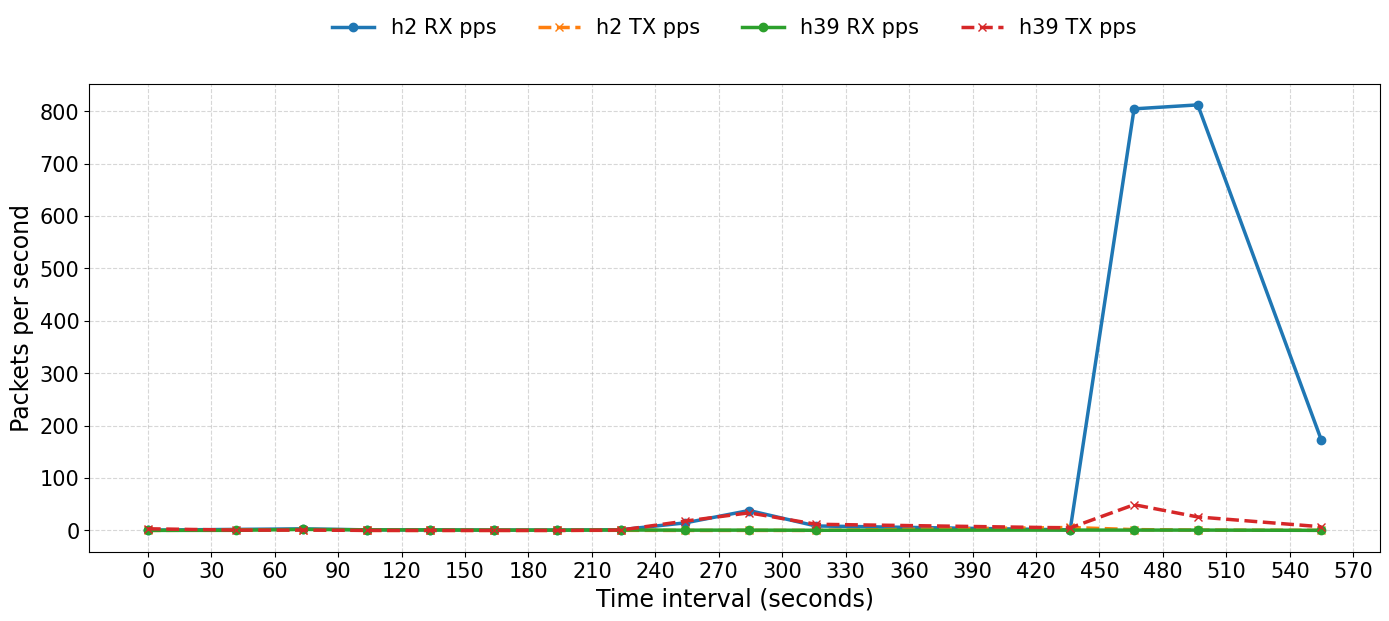

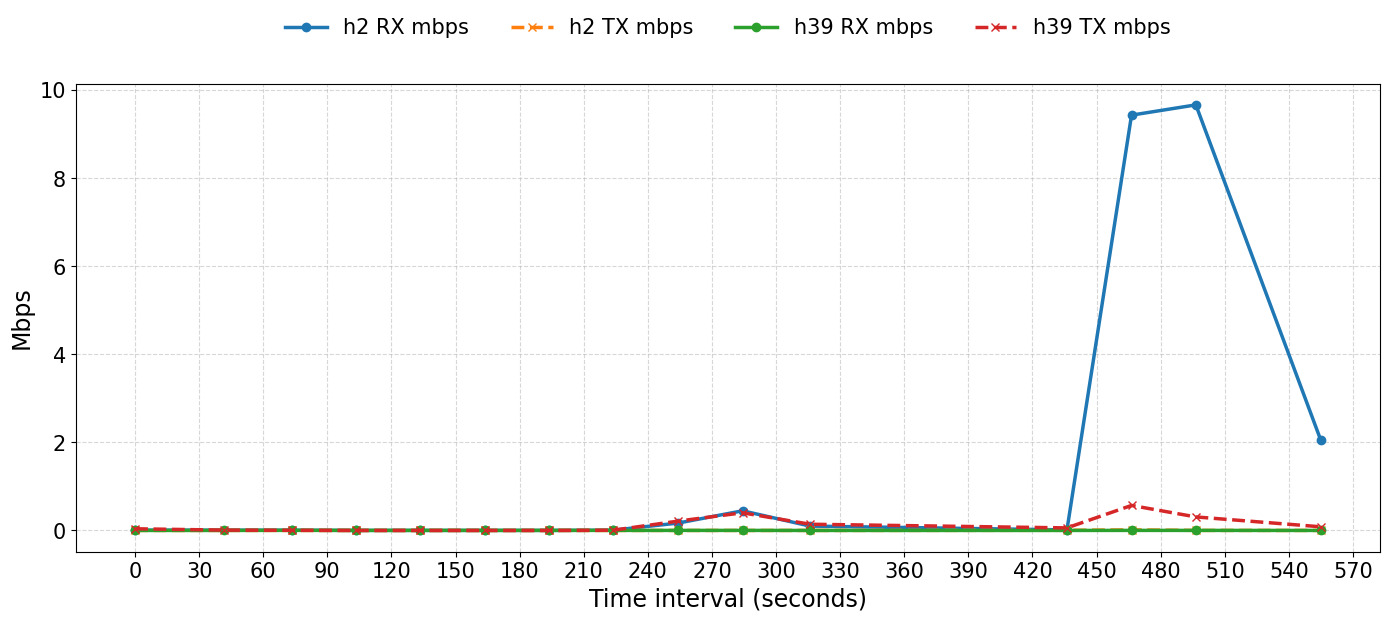

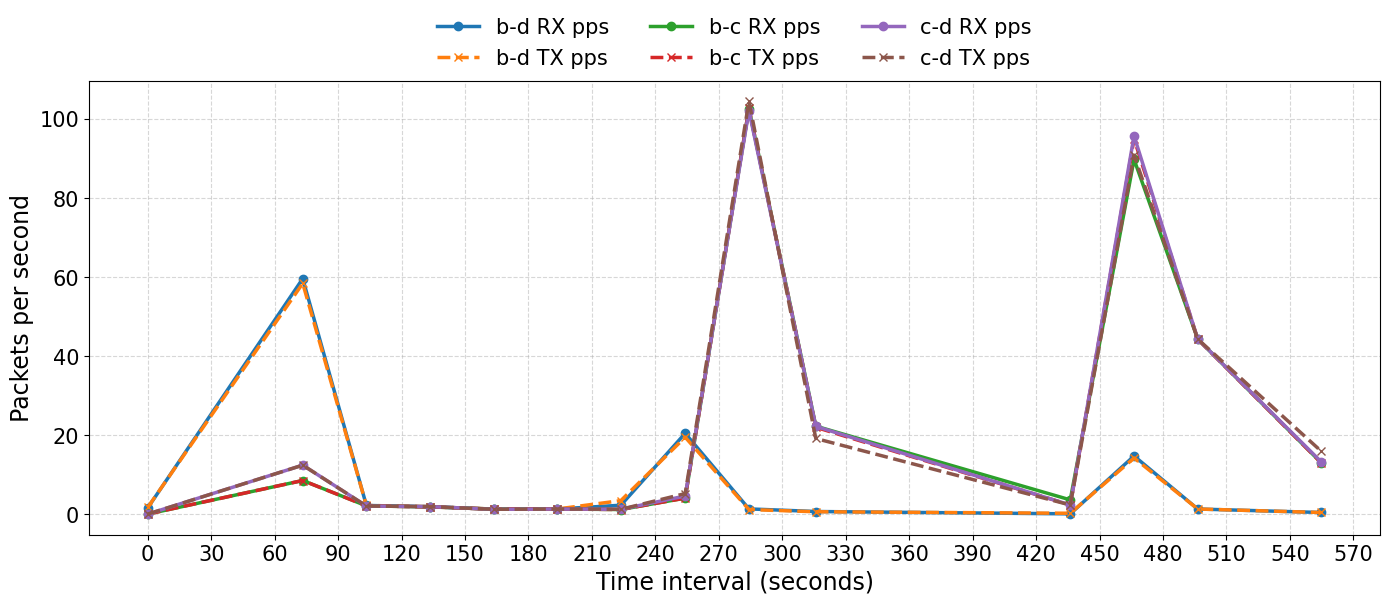

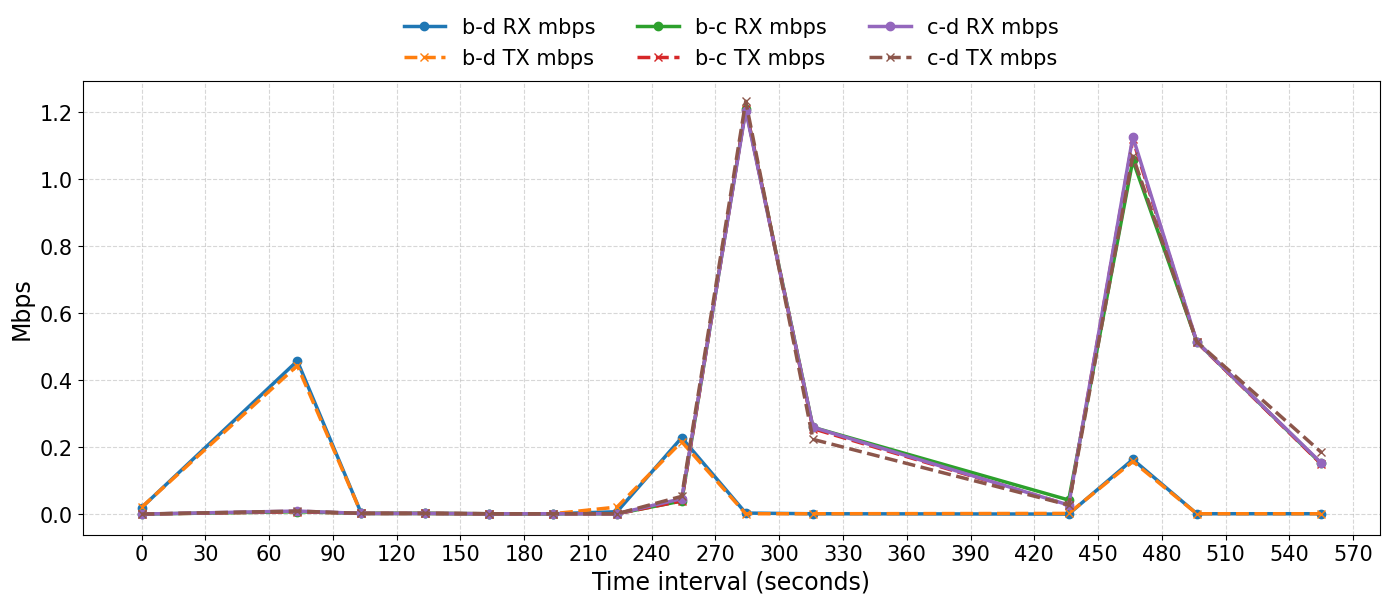

In [12]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

HOST_CSV = "host_stats_onos.csv"
LINK_CSV = "link_stats_onos.csv"

TARGET_HOSTS = ["h2", "h39"]

# b=s11, c=s12, d=s13
TARGET_LINK_PAIRS = {
    "b-d": ("s11", "s13"),
    "b-c": ("s11", "s12"),
    "c-d": ("s12", "s13"),
}

FONT_LABEL = 17
FONT_TICK = 15
FONT_LEGEND = 15


def host_from_mac(mac):
    try:
        return f"h{int(str(mac).split(':')[-1], 16)}"
    except Exception:
        return None


def switch_num(s):
    m = re.search(r"\d+", str(s))
    return int(m.group()) if m else 99999


def dpid_to_switch(x):
    x = str(x).strip()
    if not x.startswith("of:"):
        return x
    body = x.replace("of:", "").split("/")[0].split(":")[0]
    return f"s{int(body, 16)}"


def normalize_link_pair(link_id):
    if "->" not in str(link_id):
        return None
    a, b = [x.strip() for x in str(link_id).split("->", 1)]
    return tuple(sorted((dpid_to_switch(a), dpid_to_switch(b)), key=switch_num))


def add_elapsed(df):
    df = df.copy()
    df["elapsed_sec"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()
    return df


def setup_axis(ax, ylabel, interval=30):
    ax.set_facecolor("white")
    ax.set_xlabel("Time interval (seconds)", fontsize=FONT_LABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_LABEL)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(interval))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))


def legend_top(ax, ncol=4):
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=ncol,
        fontsize=FONT_LEGEND,
        frameon=False,
    )


def load_host_stats(path=HOST_CSV):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    if "host" not in df.columns:
        df["host"] = df["host_mac"].apply(host_from_mac)

    for c in ["rx_pps", "tx_pps", "rx_mbps", "tx_mbps"]:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    return df.dropna(subset=["host"]).sort_values("timestamp")


def load_link_stats(path=LINK_CSV):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    for c in ["rx_pps", "tx_pps", "rx_mbps", "tx_mbps"]:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    pair_to_label = {
        tuple(sorted(v, key=switch_num)): k
        for k, v in TARGET_LINK_PAIRS.items()
    }

    df["link_label"] = df["link_id"].apply(normalize_link_pair).map(pair_to_label)
    df = df.dropna(subset=["link_label"])

    return (
        df.groupby(["timestamp", "link_label"], as_index=False)
        .agg({
            "rx_pps": "max",
            "tx_pps": "max",
            "rx_mbps": "max",
            "tx_mbps": "max",
        })
        .sort_values("timestamp")
    )


def plot_host(metric="pps", hosts=TARGET_HOSTS, path=HOST_CSV, interval=30):
    df = load_host_stats(path)
    df = add_elapsed(df[df["host"].isin(hosts)])

    y_rx, y_tx = f"rx_{metric}", f"tx_{metric}"
    ylabel = "Packets per second" if metric == "pps" else "Mbps"

    fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")
    setup_axis(ax, ylabel, interval)

    for h in hosts:
        sub = df[df["host"] == h].sort_values("elapsed_sec")
        ax.plot(sub["elapsed_sec"], sub[y_rx], linewidth=2.5, marker="o", label=f"{h} RX {metric}")
        ax.plot(sub["elapsed_sec"], sub[y_tx], linewidth=2.5, marker="x", linestyle="--", label=f"{h} TX {metric}")

    legend_top(ax, ncol=4)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    return fig


def plot_link(metric="pps", path=LINK_CSV, interval=30):
    df = add_elapsed(load_link_stats(path))

    y_rx, y_tx = f"rx_{metric}", f"tx_{metric}"
    ylabel = "Packets per second" if metric == "pps" else "Mbps"

    fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")
    setup_axis(ax, ylabel, interval)

    for label in TARGET_LINK_PAIRS:
        sub = df[df["link_label"] == label].sort_values("elapsed_sec")
        ax.plot(sub["elapsed_sec"], sub[y_rx], linewidth=2.5, marker="o", label=f"{label} RX {metric}")
        ax.plot(sub["elapsed_sec"], sub[y_tx], linewidth=2.5, marker="x", linestyle="--", label=f"{label} TX {metric}")

    legend_top(ax, ncol=3)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    return fig


figs = [
    plot_host("pps"),
    plot_host("mbps"),
    plot_link("pps"),
    plot_link("mbps"),
]

plt.show()

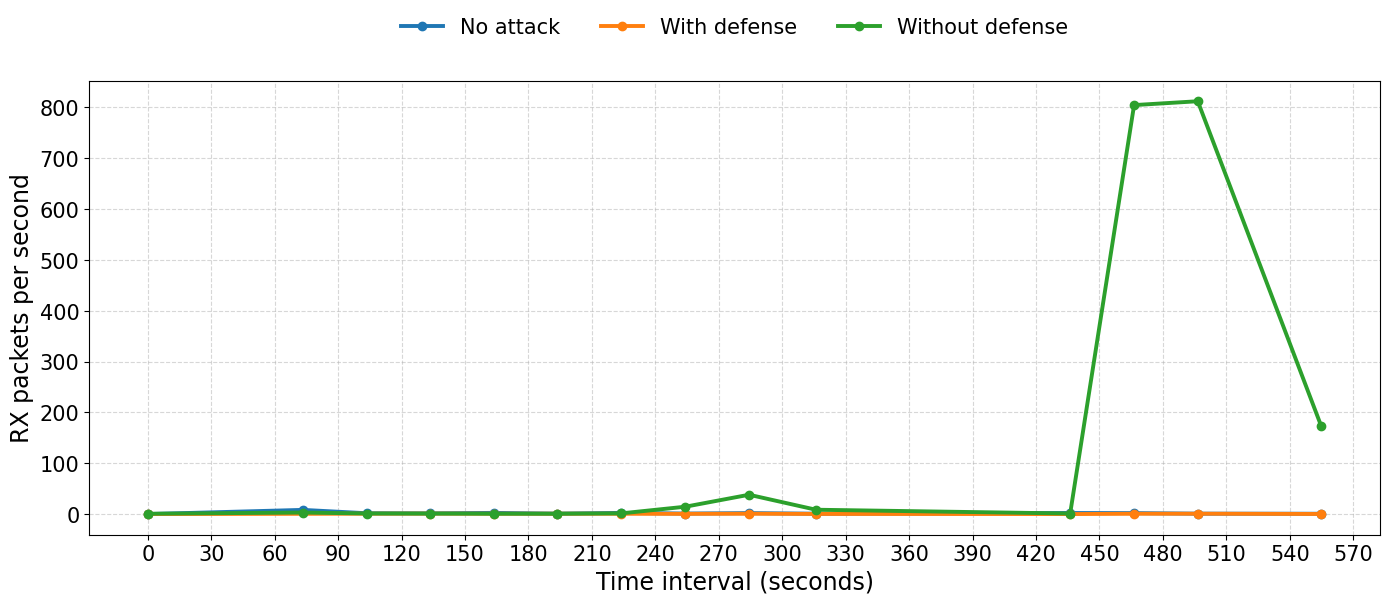

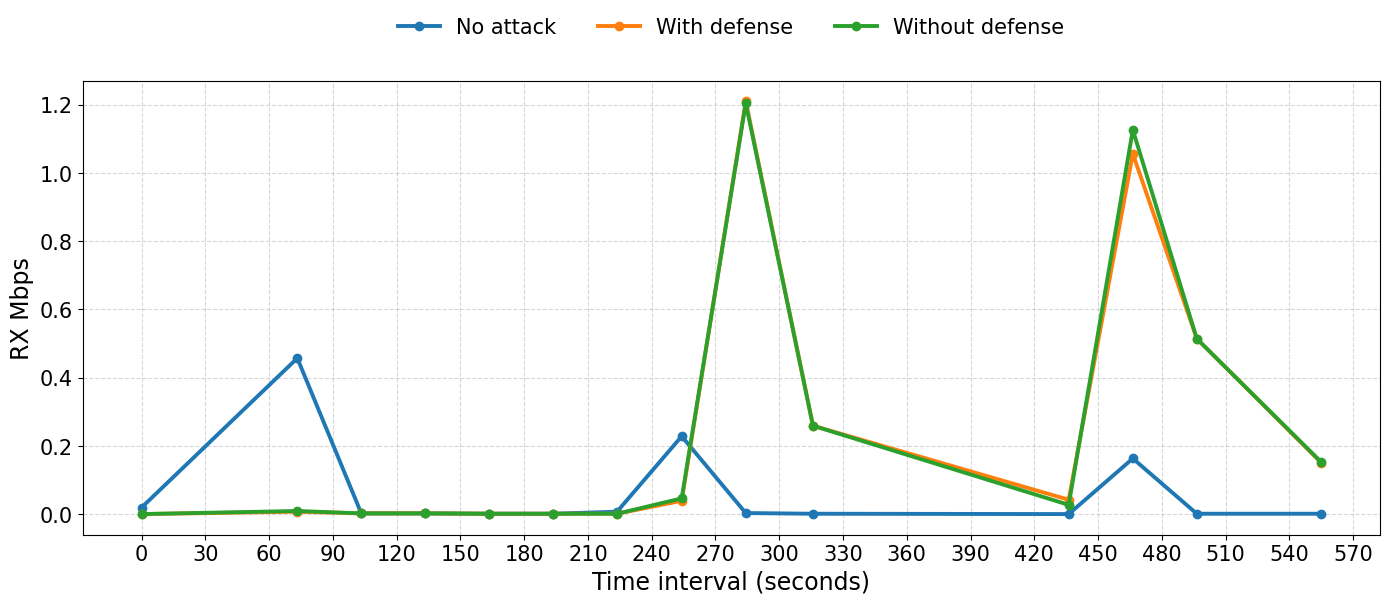

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

HOST_CSV = "host_stats_onos.csv"
LINK_CSV = "link_stats_onos.csv"

# =========================
# TUNABLE PLOT CHOICE
# =========================

HOST_KEEP = ["rx_pps"]      # ["rx_pps"], ["tx_pps"], ["rx_mbps"], ["tx_mbps"]
LINK_KEEP = ["rx_mbps"]     # ["rx_mbps"], ["tx_mbps"], ["rx_pps"], ["tx_pps"], ["mbps"], ["pps"]

HOST_SCOPE = {
    "h1": "No attack",
    "h3": "With defense",
    "h2": "Without defense",
}

# b=s11, c=s12, d=s13
LINK_PAIR_MAP = {
    "b-d": ("s11", "s13"),
    "b-c": ("s11", "s12"),
    "c-d": ("s12", "s13"),
}

LINK_SCOPE = {
    "b-d": "No attack",
    "b-c": "With defense",
    "c-d": "Without defense",
}

FONT_LABEL = 17
FONT_TICK = 15
FONT_LEGEND = 15


def nice_ylabel(col):
    names = {
        "rx_pps": "RX packets per second",
        "tx_pps": "TX packets per second",
        "pps": "Packets per second",
        "rx_mbps": "RX Mbps",
        "tx_mbps": "TX Mbps",
        "mbps": "Mbps",
    }
    return names.get(col, col)


def host_from_mac(mac):
    try:
        return f"h{int(str(mac).split(':')[-1], 16)}"
    except Exception:
        return None


def switch_num(s):
    m = re.search(r"\d+", str(s))
    return int(m.group()) if m else 99999


def dpid_to_switch(x):
    x = str(x).strip()
    if not x.startswith("of:"):
        return x
    body = x.replace("of:", "").split("/")[0].split(":")[0]
    return f"s{int(body, 16)}"


def normalize_link_pair(link_id):
    if "->" not in str(link_id):
        return None
    a, b = [x.strip() for x in str(link_id).split("->", 1)]
    return tuple(sorted((dpid_to_switch(a), dpid_to_switch(b)), key=switch_num))


def add_elapsed(df):
    df = df.copy()
    df["elapsed_sec"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()
    return df


def setup_axis(ax, ylabel, interval=30):
    ax.set_facecolor("white")
    ax.set_xlabel("Time interval (seconds)", fontsize=FONT_LABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_LABEL)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(interval))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))


def legend_top(ax, ncol=3):
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=ncol,
        fontsize=FONT_LEGEND,
        frameon=False,
    )


def load_host(path=HOST_CSV):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    if "host" not in df.columns:
        df["host"] = df["host_mac"].apply(host_from_mac)

    for c in ["rx_pps", "tx_pps", "rx_mbps", "tx_mbps"]:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    return df.dropna(subset=["host"]).sort_values("timestamp")


def load_link(path=LINK_CSV):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    for c in ["rx_pps", "tx_pps", "rx_mbps", "tx_mbps"]:
        if c not in df.columns:
            df[c] = 0.0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    pair_to_label = {
        tuple(sorted(v, key=switch_num)): k
        for k, v in LINK_PAIR_MAP.items()
    }

    df["link_label"] = df["link_id"].apply(normalize_link_pair).map(pair_to_label)
    df = df.dropna(subset=["link_label"])

    # optional combined metrics
    df["pps"] = df[["rx_pps", "tx_pps"]].max(axis=1)
    df["mbps"] = df[["rx_mbps", "tx_mbps"]].max(axis=1)

    return (
        df.groupby(["timestamp", "link_label"], as_index=False)
        .agg({
            "rx_pps": "max",
            "tx_pps": "max",
            "pps": "max",
            "rx_mbps": "max",
            "tx_mbps": "max",
            "mbps": "max",
        })
        .sort_values("timestamp")
    )


def plot_host_scope(ycol="rx_pps", interval=30):
    df = add_elapsed(load_host(HOST_CSV))

    fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")
    setup_axis(ax, nice_ylabel(ycol), interval)

    for host, scope_label in HOST_SCOPE.items():
        sub = df[df["host"] == host].sort_values("elapsed_sec")
        if sub.empty:
            print(f"[WARN] No data for {host} ({scope_label})")
            continue

        ax.plot(
            sub["elapsed_sec"],
            sub[ycol],
            linewidth=2.8,
            marker="o",
            label=scope_label,
        )

    legend_top(ax, ncol=3)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    return fig


def plot_link_scope(ycol="rx_mbps", interval=30):
    df = add_elapsed(load_link(LINK_CSV))

    fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")
    setup_axis(ax, nice_ylabel(ycol), interval)

    for link, scope_label in LINK_SCOPE.items():
        sub = df[df["link_label"] == link].sort_values("elapsed_sec")
        if sub.empty:
            print(f"[WARN] No data for {link} ({scope_label})")
            continue

        ax.plot(
            sub["elapsed_sec"],
            sub[ycol],
            linewidth=2.8,
            marker="o",
            label=scope_label,
        )

    legend_top(ax, ncol=3)
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    return fig


figs = []

for col in HOST_KEEP:
    figs.append(plot_host_scope(col))

for col in LINK_KEEP:
    figs.append(plot_link_scope(col))

plt.show()